In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
""" def wrapped_norm_pdf(x, mean, std, wrap_size):
    # 対数空間での計算を避けるため、標準偏差が小さすぎる場合は調整
    std = np.maximum(std, 1e-10)
    wrapped_pdf = np.zeros_like(x, dtype=np.float64)
    #pdf = np.zeros_like(x, dtype=np.float32)
    #print(wrap_size/2)
    center=round(wrap_size/2)
    pdf = norm.pdf(x,center,std)
    if mean<center:
        #if mean > 0:
        wrapped_pdf[0:mean]=pdf[-(mean-center):center]
        #print(wrapped_pdf)
        wrapped_pdf[mean:mean+center]=pdf[center:wrap_size]
        #print(wrapped_pdf)
        wrapped_pdf[mean+center:]=pdf[0:center-mean]
    else:
        wrapped_pdf[0:mean-center]=pdf[wrap_size-mean+center:]
        #print(wrapped_pdf)
        #wrapped_pdf[mean-center:mean]=pdf[0:center]
        #print(wrapped_pdf)
        wrapped_pdf[mean-center:]=pdf[0:wrap_size-mean+center]
        #wrapped_pdf[mean:]=pdf[center:wrap_size-mean]
    #for k in [-1, 0, 1]:
        #pdf += (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean + k * wrap_size) / std) ** 2)
    return wrapped_pdf """
#l = np.arange(0,100,1)
#print(wrapped_norm_pdf(l, 49, 2.8, 100))

' def wrapped_norm_pdf(x, mean, std, wrap_size):\n    # 対数空間での計算を避けるため、標準偏差が小さすぎる場合は調整\n    std = np.maximum(std, 1e-10)\n    wrapped_pdf = np.zeros_like(x, dtype=np.float64)\n    #pdf = np.zeros_like(x, dtype=np.float32)\n    #print(wrap_size/2)\n    center=round(wrap_size/2)\n    pdf = norm.pdf(x,center,std)\n    if mean<center:\n        #if mean > 0:\n        wrapped_pdf[0:mean]=pdf[-(mean-center):center]\n        #print(wrapped_pdf)\n        wrapped_pdf[mean:mean+center]=pdf[center:wrap_size]\n        #print(wrapped_pdf)\n        wrapped_pdf[mean+center:]=pdf[0:center-mean]\n    else:\n        wrapped_pdf[0:mean-center]=pdf[wrap_size-mean+center:]\n        #print(wrapped_pdf)\n        #wrapped_pdf[mean-center:mean]=pdf[0:center]\n        #print(wrapped_pdf)\n        wrapped_pdf[mean-center:]=pdf[0:wrap_size-mean+center]\n        #wrapped_pdf[mean:]=pdf[center:wrap_size-mean]\n    #for k in [-1, 0, 1]:\n        #pdf += (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean + k 

In [2]:
import numpy as np
from scipy.stats import norm

def wrapped_norm_pdf(x, mean, std, wrap_size):
    """
    円環(長さ wrap_size)上のガウスを、離散点 x に対して評価する。
    x は整数/配列いずれでも可（小数の場合はインデックスとして切り捨てられるので注意）。
    """
    # 安定化
    std = max(float(std), 1e-10)
    wrap_size = int(wrap_size)

    # インデックス系を用意
    idx = np.arange(wrap_size, dtype=int)

    # “中心”に置いたガウス（中心は floor(wrap_size/2) でOK）
    center = wrap_size // 2
    base = norm.pdf(idx, loc=center, scale=std)  # shape = (wrap_size,)

    # 目的の mean になるよう円環上でシフト
    shift = (int(mean) - center) % wrap_size
    rolled = np.roll(base, shift)  # shape = (wrap_size,)

    # 任意の x に対応（整数インデックスとして扱う）
    x = np.asarray(x)
    x_idx = np.mod(x.astype(int), wrap_size)
    wrapped_pdf = rolled[x_idx]

    return wrapped_pdf.astype(np.float64)

[[[0 0 0]]

 [[1 1 1]]]


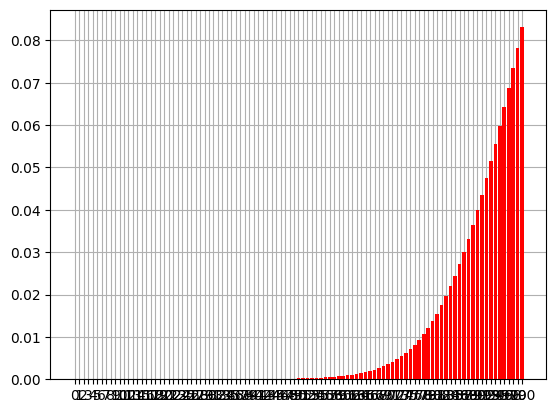

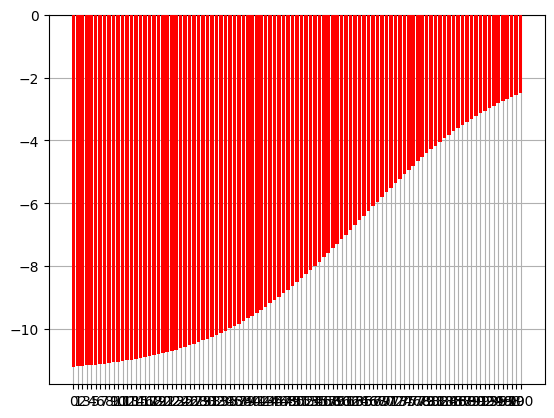

In [3]:
from pymdp import utils
import numpy as np
from scipy.stats import norm
import math
from pymdp.maths import softmax

import jax.numpy as jnp
import jax.tree_util as jtu
from jax import random as jr, config, jit
from pymdp.jax.agent import Agent as AIFAgent
from functools import partial
from equinox import tree_at

from pymdp.jax.maths import log_stable
import jax

reward_func_mode=0#0:pbs+pbs_pA, 1:pbs_pA+Hqo, 2:pbs_pA+Hqo+pbs,3:pbs
# シードを毎回変える場合
#import time
#seed = int(time.time())
wd=1
ws=1

seedjax=38#45#乱数シード固定38,,39
seed_value=3
num_slot=2
num_iter=32
tau=0.1
use_param_info_gain=False
learn_A=False
learn_B=False
e=0.001#観測モデルの下駄（定常発火）0.0001
Timerange=4
#観測モデルの標準偏差（支払い値をサンプリングするガウス分布の標準偏差）
w_novelty=10
initial_mean1=25##25fig保存
initial_mean2=60
initial_mean3=50
initial_mean4=50
initial_mean=[initial_mean1,initial_mean2,initial_mean3,initial_mean4]
sa1=0.001#12
sa2=0.001#12#0.001#12#0.001#0.001#12#12#0.001#12#0.001#0.001#12#8#16#0.001#16
sa3=8
sa4=12
""" sa1=0.4
sa2=0.8
sa3=1.2
sa4=1.6 """

""" sa1=0.16
sa2=0.32
sa3=0.48
sa4=0.64 """

""" sa1=1.6#観測モデルの標準偏差（支払い値をサンプリングするガウス分布の標準偏差）
sa2=2.0
sa3=2.4
sa4=2.8 """
sa=[sa1, sa2,sa3,sa4]
pAscale=1E-2#0#2
sc=0.0001
pBscale=1*sc#1E-1#2#1E-2#0#2

sb1=0.001#0.001#4#0.001#4#0.001#0.001#4#0.001#4#0.001#4##0.001#4#4#2.8#2.8#4#2.8#0.8#1#0.8#1#0.5#1#0.7#1#0.9#1#0.91#状態遷移の標準偏差
sb2=sb1
sb3=sb1#4.28
sb4=sb3#sb1
sb=[sb1, sb2,sb3,sb4]
sA1=sa1#0.16
sA2=sA1
sA3=sA1
sA4=sA1
sA=[sA1, sA2,sA3,sA4]
lr_pA=1
fr_pA=1
lr_pB=5*sc
fr_pB=0.5#0.95
#objective_function=pbs+pbs_pA
deltaS1=0
deltaS2=0
deltaS3=0
deltaS4=0
deltaS=[deltaS1,deltaS2,deltaS3,deltaS4]
num_dim=100
ramda=0.98363#減衰ランダムウォークの減衰パラメータ
#o_control=5#観測（支払い値）のデータ
#u_control=1#選択された行動（スロット）
cgrad=10#15#1#15#7.06#0.5#7.06#選好関数の傾き##10fig保存用
# b=0.1
# x0=80#80
b=0.06
x_mid=65
#cshape=2#選好関数の形状（対数の底）
alpha=1#32#512#102400#1.0#0.837#行動選択の精度


learn_start=[0 for _ in range(num_slot)]
#forced_action=np.array([[[0,0,0,0,0]],[[0,0,0,0,0]],[[0,0,0,0,0]],[[0,0,0,0,0]],[[1,1,1,1,1]],[[1,1,1,1,1]],[[1,1,1,1,1]],[[2,2,2,2,2]],[[2,2,2,2,2]],[[3,3,3,3,3]]])
#FS_time=12
#forced_action=np.array([[[0,0,0,0]],[[0,0,0,0]],[[0,0,0,0]],[[0,0,0,0]],[[1,1,1,1]],[[1,1,1,1]],[[1,1,1,1]],[[1,1,1,1]],[[2,2,2,2]],[[2,2,2,2]],[[2,2,2,2]],[[2,2,2,2]]])
FS_time=0
#forced_action=np.array([[[0,0,0,0]],[[0,0,0,0]],[[0,0,0,0]],[[0,0,0,0]],[[0,0,0,0]],[[0,0,0,0]],[[0,0,0,0]],[[0,0,0,0]],[[1,1,1,1]],[[1,1,1,1]],[[1,1,1,1]],[[1,1,1,1]],[[1,1,1,1]],[[1,1,1,1]],[[1,1,1,1]],[[1,1,1,1]],[[2,2,2,2]],[[2,2,2,2]],[[2,2,2,2]],[[2,2,2,2]],[[2,2,2,2]],[[2,2,2,2]],[[2,2,2,2]],[[2,2,2,2]]])
num_obs=[]
num_states=[]
num_controls=[]
for i in range(num_slot):
    num_obs.append(num_dim+1)
    num_states.append(num_dim)
    num_controls.append(num_slot)
num_obs.append(num_slot)
num_states.append(num_slot)
num_controls.append(num_slot)
""" print(num_obs)
print(num_states)
print(num_controls) """
""" num_obs = [num_dim+1, num_dim+1, num_dim+1, num_dim+1,num_slot] # observation modality dimensions，観測の次元数．観測は各スロットに対して，支払値なし，支払値1,支払値2，...支払値10の11通り．例）obs=[0,0,6,0]のとき，スロット3から支払値6が排出．
num_states = [num_dim, num_dim, num_dim, num_dim, num_slot] 
num_controls = [4, 4, 4, 4, num_slot] # control state factor dimensions，制御状態の次元数＝各隠れ状態に対するBの数．スロット1~4の平均支払値は行動に寄らず状態遷移確率が変わらないので制御状態の次元数1．行動によってどのスロットから支払値を獲得するかが変わる，スロットは4つなので制御状態は4つ
"""
num_states_A = [num_dim,  num_slot]
Ns1=num_states[0]
#policies=np.array([[[0,0,0,0,0]],[[1,1,1,1,1]],[[2,2,2,2,2]],[[3,3,3,3,3]]])

policies = np.array([[[i] * (num_slot + 1)] for i in range(num_slot)])
print(policies)
num_factors = len(num_states)
D = utils.obj_array(num_factors)#初期事前分布の設定
for i in range(num_slot):
    D[i] = np.ones(num_dim)/num_dim



""" D[0] = np.ones(num_dim)/num_dim#スロット1の平均支払値が1~10の値を等確率で取りうるという事前信念
D[1] = np.ones(num_dim)/num_dim
D[2]= np.ones(num_dim)/num_dim
D[3] = np.ones(num_dim)/num_dim """
#D[4] = np.zeros(8)
# E-100, E-99, E-98, ..., E-1のベクトルを作成（10^-100, 10^-99, 10^-98, ..., 10^-1）
E_values = np.array([10**(-i) for i in range(num_dim, 0, -1)])
# 正規化（合計が1になるように）
normalized_E = E_values / np.sum(E_values)
# D[0]~D[4]まで格納
#D = {}
""" for i in range(4):
    D[i] = normalized_E.copy() """
D[num_slot] = np.array([1/num_slot for _ in range(num_slot)])
D_env=utils.obj_array(num_factors)
for k in range(0,num_slot,1):
    D_env[k]=np.zeros(num_dim, dtype=float)
    D_env[k][initial_mean[k]-1] = 1.0
# D_env[1]=np.zeros(num_dim, dtype=float)
# D_env[1][initial_mean2-1] = 1.0
# D_env[2]=np.zeros(num_dim, dtype=float)
# D_env[2][initial_mean3-1] = 1.0
#D[4]=np.array([1/4, 1/4, 1/4 ,1/4])#自分が選んだスロット（行動）に対する信念．初期時刻はランダム．
#D[4][u_control+3]=1

l = np.arange(0,num_dim,1)                 
#A_array = utils.random_A_matrix(num_obs, num_states) # create sensory likelihood (A matrix)
A_shapes = [[o_dim] + num_states_A for o_dim in num_obs[0:num_slot]]# [4] + num_states_A2 
A_shapes.append([num_slot,num_slot])
# initialize the A array to all 0's
A_array = utils.obj_array_zeros(A_shapes)

for j in range(num_slot):
    for m in range(0,num_states[j],1):
        for n in range(num_slot):
            if n==j:
                A_array[j][0,m,n]=0 #スロット1を選択したとき（制御状態0），スロット1の「支払値なし」の観測が生成される確率は0
                #A_array[j][1:(num_dim+1),m,n]=wrapped_norm_pdf(l, m, sa[j], num_dim)+e
                A_array[j][1:(num_dim+1),m,n]=norm.pdf(l, m, sa[j])#+e

            else:
                #A_array[0][1:101,m,0]=  norm.pdf(l,m,sa1)+e #平均m（因子1の隠れ状態）標準偏差sa1の正規分布にもとづく確率密度，10次元のベクトル．
                A_array[j][0,m,n]=1#スロット1を選択したとき（制御状態0），スロット2の「支払値なし」の観測が生成される確率は1.
        
    #A_array[3][1:101,p,3]=norm.pdf(l,p,sa4)+e
for q in range(0,num_states[num_slot],1):
    
    A_array[num_slot][q,q]=1

A_array = utils.norm_dist_obj_arr(A_array)#列ごとに正規化            

B_shapes = [[s_dim, s_dim, num_controls[f]] for f, s_dim in enumerate(num_states)]


# initialize the B array to uniform distributions as columns
#uniform_B = utils.obj_array_uniform(B_shapes)
#B_array = utils.random_B_matrix(num_states, num_controls) # create transition likelihood (B matrix)
#rng = np.random.default_rng()#+rng.normal(0, sb1))
# initialize the B array to all 0's
B_array = utils.obj_array_zeros(B_shapes)
theta=4 #減衰中心

#初期仮説
for k in range(0,num_slot,1):
    for u in range(0,num_controls[k],1):
        for st in range(0,num_states[k],1): 
            #B_array[k][:,st,u]=wrapped_norm_pdf(l, st, sb[k], num_dim)
            B_array[k][:,st,u]=norm.pdf(l, st, sb[k])


for controls in range(0,num_states[num_slot],1):
    B_array[num_slot][controls,:,controls]=[1] * num_slot#選択された制御状態に確率1で遷移する．
B_array = utils.norm_dist_obj_arr(B_array)#列ごとに正規化  


C_shapes = [[o_dim] for o_dim in num_obs]
C_vector = utils.obj_array_zeros(C_shapes)

# ##Cフラット，学習」
# for k in range(0,num_slot,1):
#     C_vector[k][0]=0
#     for m in range(1,num_obs[k],1):
#         C_vector[k][m] = cgrad* math.log(m+c_shift)#スロット1の支払値に対する選好．対数関数で定義．
# # 1) 対数型: f(x) = a * log(1 + b x)
# # 条件: b > 0
# for k in range(0, num_slot, 1):
#     C_vector[k][0] = 0
#     for m in range(1, num_obs[k], 1):
#         C_vector[k][m] = cgrad * math.log1p(b * (m ))
# # 2) 指数飽和型: f(x) = a * (1 - exp(-b x))
# # 条件: b > 0
# for k in range(0, num_slot, 1):
#     C_vector[k][0] = 0
#     for m in range(1, num_obs[k], 1):
#         # -expm1(-z) は 1 - exp(-z) と同値で数値的に安定
#         C_vector[k][m] = cgrad * (-math.expm1(-b * m ))
# 3) べき乗型: f(x) = a * ((1 + b x)^r - 1)  （0 < r < 1）
# 条件: b > 0, 0 < r < 1
# for k in range(0, num_slot, 1):
#     C_vector[k][0] = 0
#     for m in range(1, num_obs[k], 1):
#         C_vector[k][m] = cgrad * ((1.0 + b * (m ))**r - 1.0)
#指数飽和型関数
# eps = 1e-12
# for k in range(0, num_slot, 1):
#     # Cの生値をまず作る（倍率は付けない）
#     for m in range(0, num_obs[k], 1):
#         x = m  # 既存の c_shift は使わず、x0 に統合する
#         #val = 0.0
        
#         val = cgrad*(- math.exp(-b * (x - x0)) ) # 常に下に凸
#         C_vector[k][m] = val  # ゼロ回避


eps = 1e-12
for k in range(0, num_slot, 1):
    for m in range(0, num_obs[k], 1):
        x = m
        t = b * (x - x_mid)
        # 数値安定（オーバーフロー防止）
        #t = max(min(t, 60.0), -60.0)
        sig = 1.0 / (1.0 + math.exp(-t))  # 0..1
        C_vector[k][m] = cgrad * sig #+ eps

# eps = 1e-12
# for k in range(0, num_slot, 1):
#     for m in range(0, num_obs[k], 1):
#         x = m
#         t = b * (x - x_mid)
#         # 数値安定
#         t = max(min(t, 60.0), -60.0)
#         gompertz = math.exp(-math.exp(-t))  # 0..1
#         C_vector[k][m] = cgrad * gompertz + eps
# for k in range(0, num_slot, 1):
#     for m in range(0, num_obs[k], 1):
#         x = m  # c_shiftは使わず、中心はx_midで指定
#         val = 1.0 / (1.0 + math.exp(-b * (x - x_mid)))  # S字（変曲点 x_mid）
#         C_vector[k][m] = max(val, 0.0) + eps


from pymdp.utils import plot_beliefs, plot_likelihood,plot_likelihood_figsize
#print(A_array[0][:,:,0,0,0,0])
plot_beliefs(softmax(C_vector[0]))

for i in range(num_slot):
    C_vector[i]=np.log(softmax(C_vector[i]))

plot_beliefs(C_vector[0])#
#print(C_vector)
#C_vector = utils.obj_array_uniform(num_obs) # uniform preferences

In [4]:
print(D[0])
print(D[1])
#print(D[4])

[0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01]
[0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01
 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01

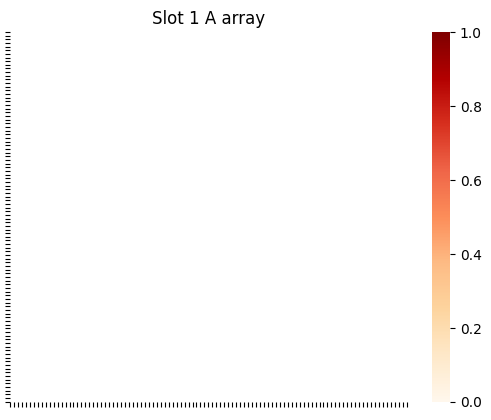

[[0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]


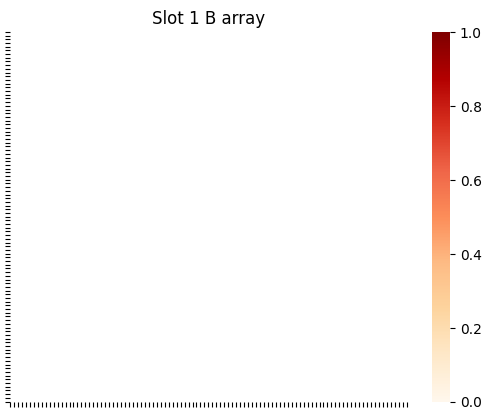

In [5]:
from pymdp.utils import plot_beliefs, plot_likelihood,plot_likelihood_figsize
#print(A_array[0][:,:,0,0,0,0])
#plot_beliefs(C_vector[0])
#plot_beliefs(softmax(C_vector[0]))
plot_likelihood(A_array[0][:,:,0],'Slot 1 A array')
print(A_array[0][:,:,0])
plot_likelihood(B_array[0][:,:,0],'Slot 1 B array')

In [6]:
class FourArmedBandit(object):#生成プロセスの定義

  def __init__(self, D_env):#初期化関数．各スロットの初期値をランダムに決定．
    rand_seq=[]
    rng = np.random.default_rng(seed=seed_value)
    self.s_slot=np.zeros((num_slot), dtype=int)
    for i in range (num_slot):
      np.random.seed(seed_value+i)  # ここで一度だけ設定
      self.s_slot[i]=utils.sample(D_env[i])
      print(f"slot{i}:",self.s_slot[i])
      rand_seq.append(rng.normal(loc=0.0, scale=sb[i], size=2*Timerange))#スロット1と2の遷移の乱数は別
    self.idx = np.zeros((num_slot), dtype=int)
    np.random.seed(seed_value)  # ここで一度だけ設定

    #self.rand_seq = rng.random(size=2*num_slot*30)#確率で制御
    #rand_seq = rng.normal(loc=0.0, scale=sb1, size=2*num_slot*30)#標準偏差で制御
    self.rand_seq = rand_seq

    """ self.s_slot1 = utils.sample(D_env[0]) # randomly sample which bandit arm is better (Left or Right)
    self.s_slot2 = utils.sample(D_env[1])
    self.s_slot3 = utils.sample(D_env[2])
    self.s_slot4 = utils.sample(D_env[3])
    self.s_action = utils.sample(D_env[4]) """

  def step(self, action_idx):#観測の生成関数．#(self, action_idx, o_control):
    obs_slot=np.zeros((num_slot))
    """ obs_slot1=0 #0:no cue
    obs_slot2=0
    obs_slot3=0
    obs_slot4=0"""
    obs_action=0 
    #controlledobs_slot1=0
    #controlledobs_slot2=0
    #controlledobs_slot3=0
    #controlledobs_slot4=0
    
    
    ##減衰ランダムウォーク
    """ self.s_slot1=round(ramda*self.s_slot1+(1-ramda)*theta+rng.normal(0, sb1))#真の平均支払い値の遷移
    if self.s_slot1>99:#平均支払い値を1~10に収める
        self.s_slot1=99
    if self.s_slot1<0:
        self.s_slot1=0
    self.s_slot2=round(ramda*self.s_slot2+(1-ramda)*theta+rng.normal(0, sb2))#真の平均支払い値の遷移
    if self.s_slot2>99:#平均支払い値を1~10に収める
        self.s_slot2=99
    if self.s_slot2<0:
        self.s_slot2=0
    self.s_slot3=round(ramda*self.s_slot3+(1-ramda)*theta+rng.normal(0, sb3))#真の平均支払い値の遷移
    if self.s_slot3>99:#平均支払い値を1~10に収める
        self.s_slot3=99
    if self.s_slot3<0:
        self.s_slot3=0
    self.s_slot4=round(ramda*self.s_slot4+(1-ramda)*theta+rng.normal(0, sb4))#真の平均支払い値の遷移
    if self.s_slot4>99:#平均支払い値を1~10に収める
        self.s_slot4=99
    if self.s_slot4<0:
        self.s_slot4=0 """
    #import random
    for i in range(num_slot):
      #u1 = self.rand_seq[self.idx]; self.idx += 1
      u1 = self.rand_seq[i][self.idx[i]]; self.idx[i] += 1
      #self.s_slot[i]=round(self.s_slot[i]+deltaS[i]+rng.normal(0, sb[i]))#真の平均支払い値の遷移
      """ if u1<sb1:
        self.s_slot[i]=round(self.s_slot[i]+deltaS[i])
      else:
        print("noise")
        if u1<1/(num_dim-1):
          self.s_slot[i]=round(self.s_slot[i]-deltaS[i])
        else:
          self.s_slot[i]=round(self.s_slot[i])
      if self.s_slot[i]>num_dim-1:#平均支払い値を1~10に収める
          self.s_slot[i]-=num_dim
      if self.s_slot[i]<0:
          self.s_slot[i]+=num_dim """

      nexts=round(self.s_slot[i]+deltaS[i]+u1)
      self.s_slot[i]=nexts
      
      if self.s_slot[i]>num_dim-1:#平均支払い値を1~10に収める
          self.s_slot[i]-=num_dim
      if self.s_slot[i]<0:
          self.s_slot[i]+=num_dim
    
    """ self.s_slot1=round(self.s_slot1+deltaS1+rng.normal(0, sb1))#真の平均支払い値の遷移
    if self.s_slot1>num_dim-1:#平均支払い値を1~10に収める
        self.s_slot1-=num_dim
    if self.s_slot1<0:
        self.s_slot1+=num_dim
    self.s_slot2=round(self.s_slot2+deltaS2+rng.normal(0, sb2))#真の平均支払い値の遷移
    if self.s_slot2>num_dim-1:#平均支払い値を1~10に収める
        self.s_slot2-=num_dim
    if self.s_slot2<0:
        self.s_slot2+=num_dim
    self.s_slot3=round(self.s_slot3+deltaS3+rng.normal(0, sb3))#真の平均支払い値の遷移
    if self.s_slot3>num_dim-1:#平均支払い値を1~10に収める
        self.s_slot3-=num_dim
    if self.s_slot3<0:
        self.s_slot3+=num_dim
    self.s_slot4=round(self.s_slot4+deltaS4+rng.normal(0, sb4))#真の平均支払い値の遷移
    if self.s_slot4>num_dim-1:#平均支払い値を1~10に収める
        self.s_slot4-=num_dim
    if self.s_slot4<0:
        self.s_slot4+=num_dim """
    
    action_idx= action_idx[0][num_slot] #制御状態が0のとき（スロット1を選択したとき）:
      
    A_env=np.zeros((num_dim+1))
    A_env[0]=0
    #A_env[1:101]=norm.pdf(l,self.s_slot1,sA1)
    #A_env[1:num_dim+1]=wrapped_norm_pdf(l,self.s_slot[action_idx],sA[action_idx],num_dim)
    A_env[1:num_dim+1]=norm.pdf(l,self.s_slot[action_idx],sA[action_idx])
    A_env = A_env/np.sum(A_env)
    obs_slot[action_idx] = utils.sample(A_env)
    obs_action=action_idx
    
    """ elif action_idx[0][4] == 1:#1:
      
      A_env=np.zeros((num_dim+1))
      A_env[0]=0
      #A_env[1:101]=norm.pdf(l,self.s_slot2,sA2)
      A_env[1:num_dim+1]=wrapped_norm_pdf(l,self.s_slot2,sA2,num_dim)
      A_env = A_env/np.sum(A_env)
      obs_slot2 = utils.sample(A_env)
      obs_action=1
    
    elif action_idx[0][4] == 2:#2:
      
      A_env=np.zeros((num_dim+1))
      A_env[0]=0
      #A_env[1:101]=norm.pdf(l,self.s_slot3,sA3)
      A_env[1:num_dim+1]=wrapped_norm_pdf(l,self.s_slot3,sA3,num_dim)
      A_env = A_env/np.sum(A_env)
      obs_slot3 = utils.sample(A_env)
      obs_action=2
    
    elif action_idx[0][4] == 3:#3:
      
      A_env=np.zeros((num_dim+1))
      A_env[0]=0
      #A_env[1:101]=norm.pdf(l,self.s_slot4,sA4)
      A_env[1:num_dim+1]=wrapped_norm_pdf(l,self.s_slot4,sA4,num_dim)
      A_env = A_env/np.sum(A_env)
      obs_slot4 = utils.sample(A_env)
      obs_action=3 """

    #elif action_idx == 4:
      
      #obs_slot1 = o_control
    
    #elif action_idx == 5:
      
      #obs_slot2 = o_control
    
    #elif action_idx == 6:
      
      #obs_slot3 = o_control
    #elif action_idx == 7:
      
      #obs_slot4 = o_control
    obs_slot=list(obs_slot)
    obs_slot.append(obs_action)
    #obs=jnp.array(obs_slot)
    #obs = [obs_slot1, obs_slot2, obs_slot3, obs_slot4, obs_action]
    obs_jax = jtu.tree_map(lambda x: jnp.expand_dims(x, -1).astype(jnp.int32), obs_slot)#jax用にbatch次元？を追加
    true_s =list(self.s_slot)
    #true_s=[self.s_slot1, self.s_slot2, self.s_slot3, self.s_slot4]
    #return [[obs],[self] ]
    return obs_jax,true_s
  
  def reset(self):#時刻1の観測のサンプリング#(self ,o_control):
    obs_slot=np.zeros((num_slot))
    """ obs_slot1=0 #0:no cue
    obs_slot2=0
    obs_slot3=0
    obs_slot4=0 """
    obs_action=0

    action_idx= self.s_action
      
    A_env=np.zeros((num_dim+1))
    A_env[0]=0
    #A_env[1:101]=norm.pdf(l,self.s_slot1,sA1)
    #A_env[1:num_dim+1]=wrapped_norm_pdf(l,self.s_slot[action_idx],sA[action_idx],num_dim)
    A_env[1:num_dim+1]=norm.pdf(l,self.s_slot[action_idx],sA[action_idx])
    A_env = A_env/np.sum(A_env)
    obs_slot[action_idx] = utils.sample(A_env)
    obs_action=action_idx
    """ if self.s_action == 0:
      
      A_env=np.zeros((num_dim+1))
      A_env[0]=0
      #A_env[1:101]=norm.pdf(l,self.s_slot1,sA1)
      A_env[1:num_dim+1]=wrapped_norm_pdf(l,self.s_slot1,sA1,num_dim)
      A_env = A_env/np.sum(A_env)
      obs_slot1 = utils.sample(A_env)
      obs_action=0
    
    elif self.s_action == 1:
      
      A_env=np.zeros((num_dim+1))
      A_env[0]=0
      #A_env[1:101]=norm.pdf(l,self.s_slot2,sA2)
      A_env[1:num_dim+1]=wrapped_norm_pdf(l,self.s_slot2,sA2,num_dim)
      A_env = A_env/np.sum(A_env)
      obs_slot2 = utils.sample(A_env)
      obs_action=1
    
    elif self.s_action == 2:
      
      A_env=np.zeros((num_dim+1))
      A_env[0]=0
      #A_env[1:101]=norm.pdf(l,self.s_slot3,sA3)
      A_env[1:num_dim+1]=wrapped_norm_pdf(l,self.s_slot3,sA3,num_dim)
      A_env = A_env/np.sum(A_env)
      obs_slot3 = utils.sample(A_env)
      obs_action=2
    
    elif self.s_action == 3:
      
      A_env=np.zeros((num_dim+1))
      A_env[0]=0
      #A_env[1:101]=norm.pdf(l,self.s_slot4,sA4)
      A_env[1:num_dim+1]=wrapped_norm_pdf(l,self.s_slot4,sA4,num_dim)
      A_env = A_env/np.sum(A_env)
      obs_slot4 = utils.sample(A_env)
      obs_action=3 """

    #elif self.s_action == 4:
      
      #obs_slot1 = o_control
    
    #elif self.s_action == 5:
      
      #obs_slot2 = o_control
    
    #elif self.s_action == 6:
      
      #obs_slot3 = o_control
    #elif self.s_action == 7:
    
      #obs_slot4 = o_control
    obs_slot=list(obs_slot)
    obs_slot.append(obs_action)
    #obs=jnp.array(obs_slot)
    #obs = [obs_slot1, obs_slot2, obs_slot3, obs_slot4,obs_action]
    #print(obs)
    obs_jax = jtu.tree_map(lambda x: jnp.expand_dims(x, -1).astype(jnp.int32), obs_slot)#jax用にbatch次元？を追加
    actions_t=[]
    for i in range(num_slot):
      actions_t.append(action_idx)
    actions_t=np.array([actions_t])
    #return [[obs],[self] ]
    #print(obs_jax)
    return obs_jax, actions_t

In [7]:
from jax import nn
def calc_action_selection_prob(agent,neg_efe):
    neg_efe_tmp=neg_efe.flatten()
    q_pi=nn.softmax(agent.gamma * neg_efe_tmp)
    #q_pi= jnp.broadcast_to(q_pi, (batch_size,))
    #q_pi= jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(q_pi))
    q_pi=jnp.expand_dims(q_pi, -2)
    return q_pi
#print(neg_efe)
#print(calc_action_selection_prob(agents4,neg_efe))

In [8]:
#def run_active_inference_loop(my_agent, my_env, T = 10):
batch_size = 1 # number of agents

#num_states = [num_dim, num_dim, num_dim, num_dim, num_slot] # hidden state factor dimensions，隠れ状態の次元数．1~4因子目：各スロットの平均支払値．5因子目：自分が選択したスロット．
#num_controls = [num_slot, num_slot, num_slot, num_slot, num_slot] # control state factor dimensions，制御状態の次元数＝各隠れ状態に対するBの数．スロット1~4の平均支払値は行動に寄らず状態遷移確率が変わらないので制御状態の次元数1．行動によってどのスロットから支払値を獲得するかが変わる，スロットは4つなので制御状態は4つ
##B未知
#B_array = utils.initialize_empty_B(num_states, num_controls)
#print(B_array)
#B = utils.random_B_matrix(num_states, num_controls)
""" B_shapes = [[s_dim, s_dim, num_controls[f]] for f, s_dim in enumerate(num_states)]
B_array = utils.obj_array_zeros(B_shapes)
B_array[0:num_slot] = B_array[0:num_slot] + 1
for controls in range(0,num_states[num_slot],1):
    B_array[num_slot][controls,:,controls]=np.ones((num_slot))#選択された制御状態に確率1で遷移する．[1,1,1,1]
# Sum of columns must be one
B_array = utils.norm_dist_obj_arr(B_array) """
#print(B_array)

#Aフラットで始める場合, 選ばないときは，o=0を定義すべき
""" A_shapes = [[o_dim] + num_states_A for o_dim in num_obs[0:4]]# [4] + num_states_A2 
A_shapes.append([4,4])
print(A_shapes)
# initialize the A array to all 0's
A_array = utils.obj_array_zeros(A_shapes)
A_array=A_array +1
for q in range(0,num_states[4],1):
    
    A_array[4][q,q]=1
A_array = utils.norm_dist_obj_arr(A_array)#列ごとに正規化 """
#jax

A_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(A_array))#jax用にbatch次元を追加．
B_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(B_array))
C_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(C_vector))
D_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(D))

batch_keys = jr.split(jr.PRNGKey(0), batch_size)
#batch_keys = jr.split(batch_keys[0], batch_size)
#batch_keys = jr.split(batch_keys[0], batch_size)  

###学習過程のためON
pA = utils.dirichlet_like(A_array, scale = pAscale)
pB = utils.dirichlet_like(B_array, scale = pBscale)
for i in range(num_slot):
    for j in range(num_slot):
        if i!=j:
            pA[i][:,:,j]=pA[i][:,:,j]*10000
""" pA[0][:,:,1]=pA[0][:,:,1]*10000
pA[0][:,:,2]=pA[0][:,:,2]*10000
pA[0][:,:,3]=pA[0][:,:,3]*10000
pA[1][:,:,0]=pA[1][:,:,0]*10000
pA[1][:,:,2]=pA[1][:,:,2]*10000
pA[1][:,:,3]=pA[1][:,:,3]*10000
pA[2][:,:,0]=pA[2][:,:,0]*10000
pA[2][:,:,1]=pA[2][:,:,1]*10000
pA[2][:,:,3]=pA[2][:,:,3]*10000
pA[3][:,:,0]=pA[3][:,:,0]*10000
pA[3][:,:,1]=pA[3][:,:,1]*10000
pA[3][:,:,2]=pA[3][:,:,2]*10000 """
pA[num_slot]=pA[num_slot]*10000
pA_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(pA))

for i in range(num_slot):
    for j in range(num_slot):
        if i!=j:
            pB[i][:,:,j]=pB[i][:,:,j]*10000
""" pB[0][:,:,1]=pB[0][:,:,1]*10000
pB[0][:,:,2]=pB[0][:,:,2]*10000
pB[0][:,:,3]=pB[0][:,:,3]*10000
pB[1][:,:,0]=pB[1][:,:,0]*10000
pB[1][:,:,2]=pB[1][:,:,2]*10000
pB[1][:,:,3]=pB[1][:,:,3]*10000
pB[2][:,:,1]=pB[2][:,:,1]*10000
pB[2][:,:,0]=pB[2][:,:,0]*10000
pB[2][:,:,3]=pB[2][:,:,3]*10000
pB[3][:,:,1]=pB[3][:,:,1]*10000
pB[3][:,:,2]=pB[3][:,:,2]*10000
pB[3][:,:,0]=pB[3][:,:,0]*10000 """
pB[num_slot]=pB[num_slot]*10000
pB_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(pB))
A_dependencies = [[i, num_slot] for i in range(num_slot)] + [[num_slot]]
print(A_dependencies)
#A_dependencies=[[0, num_slot], [1, num_slot], [2,  num_slot], [3, num_slot],[num_slot]]
B_dependencies=None
#AIFエージェントの宣言
agents = AIFAgent(A=A_jax, B=B_jax, C=C_jax, D=D_jax, E=None, pA=None, pB=pB_jax,  inference_algo="mmp", learn_A=learn_A, learn_B=learn_B, learn_C=False, learn_D=False, learn_E=False, A_dependencies=A_dependencies, B_dependencies=B_dependencies, policies=policies,gamma=1., alpha=alpha, action_selection="stochastic", policy_len=1, use_utility=True, use_states_info_gain=True, use_param_info_gain=use_param_info_gain, use_inductive=False, onehot_obs=False, sampling_mode="full",num_iter=num_iter)
#AIFの処理を行う関数．「@partial～」をコメントアウトするとupdate_agent内でもprint文で出力を確認可能．


[[0, 2], [1, 2], [2]]


In [9]:
print(agents.D)

[Array([[0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
        0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
        0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
        0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
        0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
        0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
        0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
        0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
        0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
        0.01]], dtype=float32), Array([[0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
        0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
        0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
        0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
     

In [10]:
@partial(jit, static_argnames=['batch_size','num_history'])
def update_agent_inference(agents, outcomes, actions, infer_args, batch_keys,expected_states, batch_size=1, num_history=1000):

    #認識・vfeの計算
    #beliefs,err, vfe,kld2, bs, un = agents.infer_states_vfe(outcomes, infer_args[0], past_actions=actions, qs_hist=infer_args[1])
    #vfe_1step=[0]
    #print(infer_args[0])
    #print(infer_args[1][0])#一時刻目None
    """ if infer_args[1] is None:
        #infer_args[1]=infer_args[0]
        infer_args[1]=agents.D """
    #print(infer_args[1])
    """ if infer_args[1] is None:
        #1時刻目はNoneではなくagents.Dが必要
        beliefs,err, vfe,kld2, bs, un = agents.infer_states_vfe_set_prior(outcomes, infer_args[0], past_actions=actions, qs_hist=infer_args[1])
    else:
        beliefs,err, vfe,kld2, bs, un = agents.infer_states_vfe_set_prior(outcomes, infer_args[0], past_actions=actions, qs_hist=infer_args[1],expected_states=expected_states) """
    beliefs,err, vfe,kld2, bs, un, qs_1step, err_1step, vfe_1step, kld2_1step, bs_1step, un_1step = agents.infer_states_vfe_set_prior(outcomes, infer_args[0], past_actions=actions, qs_hist=infer_args[1],expected_states=expected_states, tau=tau)
    kld = agents.calc_KLD_past_currentqs(expected_states, infer_args[1], beliefs)
    #print(policy_idx)
    #past_beliefs=next_past_beliefs
    outcomes = jtu.tree_map( lambda x: x[:, -num_history:], outcomes)
    #print(f'    outcomes at time {T}: {outcomes}')
    beliefs_temp = jtu.tree_map( lambda x: x[:, -num_history:], beliefs)
    #print(f'    beliefs at time {T}: {beliefs}')
    actionstmp = jtu.tree_map( lambda x: x[:,-num_history:], actions)
    #print(f'    actions at time {T}: {actions}')
    ###
##学習用の観測・認識セットの準備
    beliefs_last = jtu.tree_map( lambda x: x[:, -1:], beliefs_temp) # take the last belief
    #print(f'    beliefs_last at time {T}: {beliefs_last}')
    outcomes_last = jtu.tree_map( lambda x: x[:, -1:], outcomes) # take the last outcome
    #print(f'    outcomes_last at time {T}: {outcomes_last}')
    applied_actions_last = jtu.tree_map( lambda x: x[:,-1:], actionstmp) # take the last applied action#applied_actions_last = jtu.tree_map( lambda x: x[:,-2:-1], actions) 
    #print(f'    applied_actions_last at time {T}: {applied_actions_last}')
    beliefs_last_pair = jtu.tree_map( lambda x: x[:, -2:], beliefs_temp) # take the last two beliefs

    if applied_actions_last is None:
        q_pi, neg_efe, pbs, pkld, pfe, oRisk, pbs_pA, pbs_pB,I_B_o,I_B_o_se = agents.infer_policies_efe(beliefs)##
   
        batch_keys = jr.split(batch_keys[0], batch_size)#乱数のシャッフル
        actions_t = agents.sample_action(q_pi, rng_key=batch_keys)
        #print("None")
        if actions is not None:
            actionstmp = jnp.concatenate([actionstmp, jnp.expand_dims(actions_t, -2)], -2)##次の推論でsampleactionしたものが使われる？
        else:
            actionstmp = jnp.expand_dims(actions_t, -2)
        applied_actions_last = jtu.tree_map( lambda x: x[:,-2:-1], actionstmp)
    # Dの学習
    agents = tree_at(lambda x: x.D, agents, jtu.tree_map(lambda x: x[:, 0], beliefs_temp)) 

    agents = agents.infer_parameters(beliefs_last, outcomes_last, applied_actions_last, beliefs_B=beliefs_last_pair,lr_pA=lr_pA, fr_pA=fr_pA,lr_pB=lr_pB, fr_pB=fr_pB)

    vfe =jnp.array(vfe)
    vfe_1step =jnp.array(vfe_1step)
    #vfe=vfe[:,:,-1]#現在時点の隠れ状態に対するVFEを出力
    bs =jnp.array(bs)
    bs_1step =jnp.array(bs_1step)
    #bs=bs[:,:,-1]#現在時点の隠れ状態に対するVFEを出力
    un =jnp.array(un)
    un_1step =jnp.array(un_1step)
    #un=un[:,:,-1]#現在時点の隠れ状態に対するVFEを出力
    #kld=[0]#kld1のとき
    ##kld=kld2[0][0]
    #kld=[kld[-1]]
    return agents, outcomes, actions, infer_args, batch_keys,  vfe,  bs, un, kld, beliefs, vfe_1step


In [11]:
#EFE計算，行動サンプリング，行動・観測履歴・信念（認識）の配列の更新を行う関数
@partial(jit, static_argnames=['batch_size','num_history'])
def update_agent_action_sampling(agents, outcomes, actions, infer_args, batch_keys, beliefs, reward_fuction=None,batch_size=1, num_history=1000):
    #行動選択確率（q_pi）の計算，efeの計算
    q_pi, neg_efe, pbs,pbs_st, pkld, pfe, oRisk, pbs_pA, pbs_pB,_,I_B_o,Hqs = agents.infer_policies_efe_curiosity(beliefs)##
    #print(pbs)
    Hqo=pfe-pkld#q(o|π)のEntropy
    negefe_tmp=neg_efe[0]-pbs_pA[0]-pbs_pB[0]#novelty項を除いたEFE
    Pv=-oRisk-Hqo
    ambi=pfe-pbs-pkld
    Hqs=jnp.array([Hqs[0,0,0],Hqs[0,0,1]])
    pbs=wd*Hqs-ws*(Hqs-Hqo+ambi)#拡散的好奇心傾向*Hqs-特定的好奇心傾向*Hqso
    #行動のサンプリング
    #batch_keys = jr.split(jr.PRNGKey(0), batch_size)
    #actions_t, policy_idx = agents.sample_action_policy_idx(q_pi, rng_key=batch_keys)#q_pi_0
    batch_keys = jr.split(batch_keys[0], batch_size)#乱数のシャッフル
    flat_value=jnp.array( [1 for _ in range(num_slot)])
    flat_value=jnp.expand_dims(flat_value,0)

    ##入力された情報量が大きいポリシーを選ぶように，行動選択確率を計算
    if reward_fuction is None:
        #q_pi=calc_action_selection_prob(agents,pbs+Pv)
        q_pi=calc_action_selection_prob(agents,pbs+Pv)#+,pbs+I_B_opbs_pB#+pbs_st
    else:
        #q_pi=calc_action_selection_prob(agents,reward_fuction+pbs+Pv)#reward_fuction+pbs
        q_pi=calc_action_selection_prob(agents,reward_fuction)#+pbs+Pv+pbs_pB+pbs+pbs_pB
    #print(q_pi)
    
    actions_t = agents.sample_action(q_pi, rng_key=batch_keys)
    #print(policy_idx)
    #past_beliefs=next_past_beliefs

    #行動・観測履歴・信念（認識）の配列の更新
    if actions is not None:
        actions = jnp.concatenate([actions, jnp.expand_dims(actions_t, -2)], -2)##次の推論でsampleactionしたものが使われる？
    else:
        actions = jnp.expand_dims(actions_t, -2)
    outcomes = jtu.tree_map( lambda x: x[:, -num_history:], outcomes)
    #print(f'    outcomes at time {T}: {outcomes}')
    beliefs = jtu.tree_map( lambda x: x[:, -num_history:], beliefs)
    #print(f'    beliefs at time {T}: {beliefs}')
    actions = jtu.tree_map( lambda x: x[:,-num_history:], actions)
    #print(f'    actions at time {T}: {actions}')
    ###
    #次のタイムステップのための事前分布（=MMPでは上の処理で作成したbeliefs）の作成
    infer_args = agents.update_empirical_prior(actions_t, beliefs)
    #empirical_prior = beliefs
    #print(f'    infer_args at time {T}: {infer_args}')    #kld=[kld[-1]]
    return agents, outcomes, actions, infer_args, batch_keys, neg_efe, pbs, pbs_pA, pbs_pB,  Hqo, pkld, pfe, oRisk,q_pi,I_B_o,Hqs,pbs_st

In [12]:
T=Timerange


key = jr.PRNGKey(seedjax)
batch_keys = jr.split(key, T)

#slot_counts = [0, 0, 0, 0]
slot_counts = [0 for _ in range(num_slot)]
array_selected_slot=[]
EFE=[]
prior_VFE=[]
posterior_VFE=[]
VFE=[]
PBS=[]
PKLD=[]
PFE=[]
Risk=[]
Ambiguity=[]
Pragmaticvalue=[]
KLD=[]
BS=[]
pBS_pA=[]
pBS_pB=[]
H_qo=[]
Q_pi=[]
PBS_st=[]
H_qs=[]
""" learn_strat1=False#スロット1を2回以上選んでいるときのみ学習
learn_strat2=False
learn_strat3=False """

prediction_performance=[]


my_env=FourArmedBandit(D_env)

flat_value=jnp.array( [1 for _ in range(num_slot)])
flat_value=jnp.expand_dims(flat_value,0)

prior_beliefs=jtu.tree_map(lambda x: jnp.expand_dims(x, -2), agents.D)
#q_pi, neg_efe, pbs, pkld, pfe, oRisk, pbs_pA, pbs_pB,I_B_o,I_B_o_se=agents.infer_policies_efe(prior_beliefs)
q_pi, neg_efe, pbs,pbs_st, pkld, pfe, oRisk, pbs_pA, pbs_pB,_,I_B_o,Hqs = agents.infer_policies_efe_curiosity(prior_beliefs)

""" def loss_fn(beliefs_tmp):
    # theta から A,B,C... を作る or 該当パラメータに反映
    qpi, negG, *_ = agents.infer_policies_efe_curiosity(beliefs_tmp)
    return -jnp.sum(qpi)  # 例：何かスカラーに落とす

g=jax.grad(loss_fn)(prior_beliefs)
print(g) """

Hqo=pfe-pkld
Pv=-oRisk-Hqo
Hqs=jnp.array([Hqs[0,0,0],Hqs[0,0,1]])
print(f"Hqs:",Hqs)
#print(f"I_B_o:",I_B_o)
#print(f"I_B_o_se:",I_B_o_se)
#print(pbs_pA)
#pbs_pB2=calc_org_novelty(agents, prior_beliefs)
#print("pbs_pB2",pbs_pB2)
q_pi=calc_action_selection_prob(agents,Pv+pbs)#+pbs_pA,Hqo+pbs,pbs+pbs+pbs_pB+,pbs_pB2*w_noveltyI_B_o#+pbs_st
batch_keys = jr.split(batch_keys[0], batch_size)#乱数のシャッフル
actions_t = agents.sample_action(q_pi, rng_key=batch_keys)
if FS_time>0:
  actions_t=forced_action[0]
first_action=actions_t
obs,true_s  = my_env.step(actions_t)#次の時刻の観測をサンプリング
#print(obs)
#print(first_action[0][0])
##obs, first_action = my_env.reset()#初期時刻の観測と行動のサンプリング
obs_record=[obs]
#chosen_policies=[first_action]
#print(f"first_action: {first_action}")
last_action=first_action[0][num_slot]
D[num_slot][first_action[0][num_slot]] = 1#自分が選んだスロット（行動）に対する信念．初期時刻はランダム．
D_jax = jtu.tree_map(lambda x: jnp.broadcast_to(x, (batch_size,) + x.shape), list(D))
agents = tree_at(lambda x: x.D, agents, D_jax) 

PBS.append(pbs)#=np.append(PBS,pbs)  
PKLD.append(pkld)
PFE.append(pfe)
Risk.append(oRisk)  
ambi=pfe-pbs-pkld
Ambiguity.append(ambi)
#Pv=-oRisk-Hqo
Pragmaticvalue.append(Pv)
H_qo.append(Hqo)
H_qs.append(Hqs)
#chosen_policies.append(chosen_policy_idx)
#VFE.append(vfe)
EFE.append(-1*neg_efe)
pBS_pA.append(pbs_pA)#=np.append(PBS,pbs) 
#pBS_pB.append(pbs_pB)
pBS_pB.append(I_B_o)#pbs_pB2

PBS_st.append(pbs_st)
Q_pi.append(q_pi)
selected_slot = int(actions_t[0][num_slot])  # スロットはインデックス4
slot_counts[selected_slot] += 1
array_selected_slot.append(first_action[0][num_slot]+1)

#agents = AIFAgent(A=A_jax, B=B_jax, C=C_jax, D=D_jax, E=None, pA=None, pB=None, learn_A=False, learn_B=False, learn_C=False, learn_D=False, learn_E=False, A_dependencies=None, B_dependencies=None, gamma=1., alpha=1., inference_algo="fpi", action_selection="stochastic", policy_len=1, use_utility=True, use_states_info_gain=True, use_param_info_gain=False, use_inductive=False, onehot_obs=False, sampling_mode="full")
beliefs=None
#print(agents.A_dependencies)
#print(agents.B_dependencies)
#print(agents.policies)
for t in range(T):
  if t == 0:
      
      actions_t = None ##first_action#None # no action available at the first time step
      #print(actions_t)
      actions = None # no action available at the first time step
      prob_pi = None
      #prob_pi = jnp.expand_dims(jnp.array([[0,0,0,0,self.s_action]]), -2) D_jax[4]
      infer_args = (agents.D, None,)#(qs_pi, qs_hist)
      outcome_t  = None
      outcomes = None
      
      expected_state =agents.D ##KLD計算用の事前分布．
  else:
      print("selected action",actions_t)
      expected_state = agents.compute_expected_state(actions_t, infer_args[1])#KLD計算用の事前分布．事前分布をB*qsとする場合
      #empirical_prior = agents.compute_expected_state(actions_t, empirical_prior)#KLD計算用の事前分布．事前分布をB*qsとする場合

  q_trues=jtu.tree_map(lambda x,i: x[0][i], expected_state[:num_slot],true_s)
  #print(f"q_trues:",q_trues)
  ln_q_trues=jtu.tree_map(lambda x: -1*log_stable(x), q_trues)
  prediction_performance.append(ln_q_trues)


  batch_keys = jr.split(batch_keys[0], batch_size)
  outcome_t  = jtu.tree_map(lambda x: jnp.expand_dims(x, -1), obs)
  #print(f'    outcome_t at time {T}: {outcome_t}')
  num_history=10 #推論する時間幅．5であれば現在から過去5タイムステップ分の隠れ状態を推論．
  if outcomes is None:
      outcomes = outcome_t
  else:
      
      #outcomes = jtu.tree_map( lambda x: x[:, -10:], outcomes)#num_history
      outcomes = jtu.tree_map(lambda prev_o, new_o: jnp.concatenate([prev_o, new_o], -1), outcomes, outcome_t) 
  pB_old=agents.pB
  B_old=agents.B
  
  """ agents, outcomes, actions, infer_args, batch_keys, neg_efe, vfe,  bs, un, pbs,  pbs_pA, pbs_pB,  Hqo, pkld, pfe, oRisk = update_agent(
      agents, 
      outcomes, 
      actions, 
      infer_args, 
      batch_keys,
      batch_size=batch_size,
      num_history=num_history
  ) """
  """ if t>1:
    print(f"outcomes",outcomes[0].shape)
    print(f"actions",actions[0].shape) """

  agents, outcomes, actions, infer_args, batch_keys,  posterior_vfe,  bs, un, kld, beliefs,prior_vfe = update_agent_inference(#Dが変わる
      agents, 
      outcomes, 
      actions, 
      infer_args, 
      batch_keys,
      expected_state,
      batch_size=batch_size,
      num_history=num_history
  )
  prior_vfe=prior_vfe[0:num_slot].sum(axis=0)
  prior_vfe=prior_vfe[:,-1]
  prior_VFE.append(prior_vfe)

  posterior_vfe=posterior_vfe[0:num_slot].sum(axis=0)
  posterior_vfe=posterior_vfe[:,-1]
  posterior_VFE.append(posterior_vfe)

  bs=bs[0:num_slot].sum(axis=0)#bs.sum(0)
  bs=bs[:,-1]
  kld=jnp.array(kld)
  kld=kld[0:num_slot].sum(axis=0)
  kld=kld[:,-1]
  #print(f"t: {t}, D[0]: {agents.D[0]}")
  #print(f"t: {t}, last_action: {last_action}")
  # Dの学習
  ##agents = tree_at(lambda x: x.D, agents, jtu.tree_map(lambda x: x[:, 0], beliefs_temp)) 

  ##学習，選択したスロットに関するAのみ
  pB_new=agents.pB
  B_new=agents.B
  #print(applied_actions_last)
  if actions is not None:
    last_action_tmp = jtu.tree_map( lambda x: x[:,-1:], actions)#applied_actions_last = jtu.tree_map( lambda x: x[:,-2:-1], actions)
    last_action=last_action_tmp[-1][-1][-1]

  #print(f"t: {t}, last_action: {last_action}")
  #print(f"applied_actions_last[-1][-1][-1]: {last_action}")
  #if jnp.any(applied_actions_last):
    #print("true2")
  #print(f"learn_start: {learn_start[last_action]}")

  for i in range(num_slot):
      
      if i == last_action and learn_start[i]==1:##状態因子i(選択されたスロット)についてのみ更新
        
      #観測したslotについて，選択していない制御状態における遷移B[i][:,:,j]を,選択した制御状態における遷移B[i][:,:,j]と一致させる．
        #print(f"i: {i}, last_action: {i}")
        
        #pA_new[i] = pA_new[i].at[:,:].set(pA_new[i][:,:]*400)
        #A_new[i] = A_new[i].at[:,:].set(A_new[i][:,:])
        for j in range(num_slot):#選択していない制御状態における遷移B[i][:,:,j]を,選択した制御状態における遷移B[i][:,:,i]と一致させる．
          if j != i:
            pB_new[i]=pB_new[i].at[:,:,:,j].set(B_new[i][:,:,:,i]*10000)
            B_new[i]=B_new[i].at[:,:,:,j].set(B_new[i][:,:,:,i])
      #観測したスロット以外のBをもとにもどす
      else:
        pB_new[i]=pB_old[i]
        B_new[i]=B_old[i]
          #continue   
  pB_new[num_slot]=pB_old[num_slot]
  B_new[num_slot]=B_old[num_slot]
  #plot_likelihood_figsize(A_new[0][0][:,:,0] )
  agents = tree_at(lambda x: x.pB, agents, pB_new)
  agents = tree_at(lambda x: x.B, agents, B_new)

  ##plot_beliefs(infer_args[1][0][-1][-1])
  #pbs_pB2=calc_org_novelty(agents, beliefs)
  #print("pbs_pB2",pbs_pB2)
  agents, outcomes, actions, infer_args, batch_keys, neg_efe, pbs,  pbs_pA, pbs_pB,  Hqo, pkld, pfe, oRisk, q_pi,I_B_o,Hqs,pbs_st = update_agent_action_sampling(
      agents, 
      outcomes, 
      actions, 
      infer_args, 
      batch_keys,
      beliefs,
      reward_fuction=None,#pbs_pB2*w_novelty,#None,#,
      batch_size=batch_size,
      num_history=num_history
  )
  print(f"oRisk",oRisk[-1])
  print(f"q_pi",q_pi)
  print(f"I_B_o:",I_B_o)
  #Hqs=jnp.array([Hqs[0,0,0],Hqs[0,0,1]])
  print(f"Hqs:",Hqs)
  """ if T < num_history:
    qs_1 = infer_args[1][0][0, 0] # snapshot of s1 for D-learning """
  actions_t = actions[:,-1]
  #print(actions_t)
  if t<FS_time-1:
    actions_t=forced_action[t+1]
    actions = jtu.tree_map( lambda x: x[:,:-1], actions)
    actions = jnp.concatenate([actions, jnp.expand_dims(actions_t, -2)], -2)##次の推論でsampleactionしたものが使われる？
  obs ,true_s = my_env.step(actions_t)#次の時刻の観測をサンプリング
  #prev_obs=[obs]#次の時刻の観測を指定．
  obs_record.append(obs)
  #chosen_policy_idx=int(actions_t[4])    

  #情報量記録
  """ efe = np.array(-neg_efe[0])
  min_index = np.argmin(efe)  # efeの最小値のインデックスを取得
  efe_min = efe[min_index] """
  #print(f'    efe_min at time {T}: {efe_min}')
  #efes.append(efe_min)
  BS.append(bs)
  KLD.append(kld)
  
  selected_slot = int(actions_t[0][num_slot])  # スロットはインデックス4
  
  if slot_counts[selected_slot]>=2:
    #print(f"selected_slot: {selected_slot}")
    learn_start[selected_slot]=1
  if t<T-1:
    array_selected_slot.append(actions_t[0][num_slot]+1)
    slot_counts[selected_slot] += 1
    PBS.append(pbs)#=np.append(PBS,pbs)  
    PKLD.append(pkld)
    PFE.append(pfe)
    Risk.append(oRisk)  
    ambi=pfe-pbs-pkld
    Ambiguity.append(ambi)
    Pv=-oRisk-Hqo
    Pragmaticvalue.append(Pv)
    pBS_pA.append(pbs_pA)
    #pBS_pB.append(pbs_pB)
    pBS_pB.append(I_B_o)#2pBS_pB.append()pbs_pB
    #chosen_policies.append(chosen_policy_idx)
    #VFE.append(vfe)
    EFE.append(-1*neg_efe)
    PBS_st.append(pbs_st)
    H_qo.append(Hqo)
    H_qs.append(Hqs)
    Q_pi.append(q_pi)

#可視化のためのデータ整形



PBS=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), PBS) 
PBS=np.array(PBS) 
PBS=PBS.T
PBS=PBS.tolist()
PKLD=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), PKLD) 
PKLD=np.array(PKLD) 
PKLD=PKLD.T
PKLD=PKLD.tolist()
PFE=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), PFE) 
PFE=np.array(PFE) 
PFE=PFE.T
PFE=PFE.tolist()
Ambiguity=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), Ambiguity) 
Ambiguity=np.array(Ambiguity) 
Ambiguity=Ambiguity.T
Ambiguity=Ambiguity.tolist()
Risk=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), Risk) 
Risk=np.array(Risk) 
Risk=Risk.T
Risk=Risk.tolist()
Pragmaticvalue=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), Pragmaticvalue) 
Pragmaticvalue=np.array(Pragmaticvalue) 
Pragmaticvalue=Pragmaticvalue.T
Pragmaticvalue=Pragmaticvalue.tolist()

EFE=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), EFE) 
EFE=np.array(EFE)
EFE=EFE.T
EFE=EFE.tolist()

pBS_pA=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), pBS_pA) 
pBS_pA=np.array(pBS_pA) 
pBS_pA=pBS_pA.T
pBS_pA=pBS_pA.tolist()

pBS_pB=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), pBS_pB) 
pBS_pB=np.array(pBS_pB) 
pBS_pB=pBS_pB.T
pBS_pB=pBS_pB.tolist()

H_qo=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), H_qo) 
H_qo=np.array(H_qo) 
H_qo=H_qo.T
H_qo=H_qo.tolist()

H_qs=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), H_qs) 
H_qs=np.array(H_qs) 
H_qs=H_qs.T
H_qs=H_qs.tolist()

PBS_st=jtu.tree_map(lambda x: jnp.reshape(x, (num_slot,)), PBS_st) 
PBS_st=np.array(PBS_st) 
PBS_st=PBS_st.T
PBS_st=PBS_st.tolist()


selected_slot_array=[x.tolist() for x in array_selected_slot]

slot0: 24
slot1: 59
Hqs: [4.60517   4.6051702]
oRisk [14.287924 18.341976]
q_pi [[0.98294413 0.01705596]]
I_B_o: [[0. 0.]]
Hqs: [4.6051698e+00 2.7579297e-12]
selected action [[0 0 0]]
oRisk [21.763218 18.33937 ]
q_pi [[0.03155844 0.96844155]]
I_B_o: [[0. 0.]]
Hqs: [1.5701149e-13 8.3095976e-13]
selected action [[1 1 1]]
oRisk [21.763218 18.33937 ]
q_pi [[0.03155844 0.96844155]]
I_B_o: [[0. 0.]]
Hqs: [7.9232611e-13 2.1559225e-14]
selected action [[1 1 1]]
oRisk [21.763218 18.33937 ]
q_pi [[0.03155844 0.96844155]]
I_B_o: [[0. 0.]]
Hqs: [7.923261e-13 2.155495e-14]


In [13]:
print(Q_pi)

[Array([[0.5, 0.5]], dtype=float32), Array([[0.98294413, 0.01705596]], dtype=float32), Array([[0.03155844, 0.96844155]], dtype=float32), Array([[0.03155844, 0.96844155]], dtype=float32)]


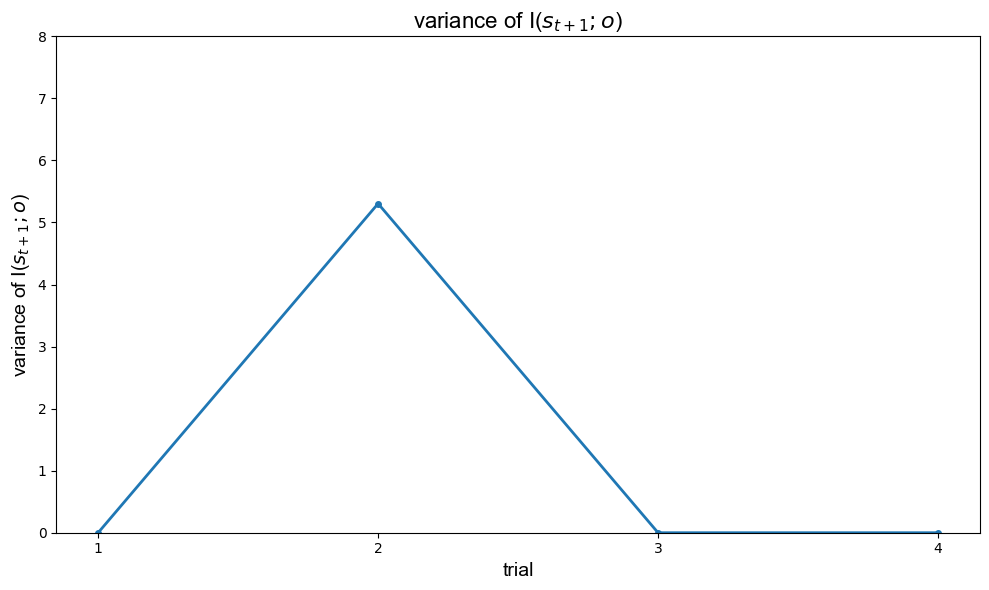

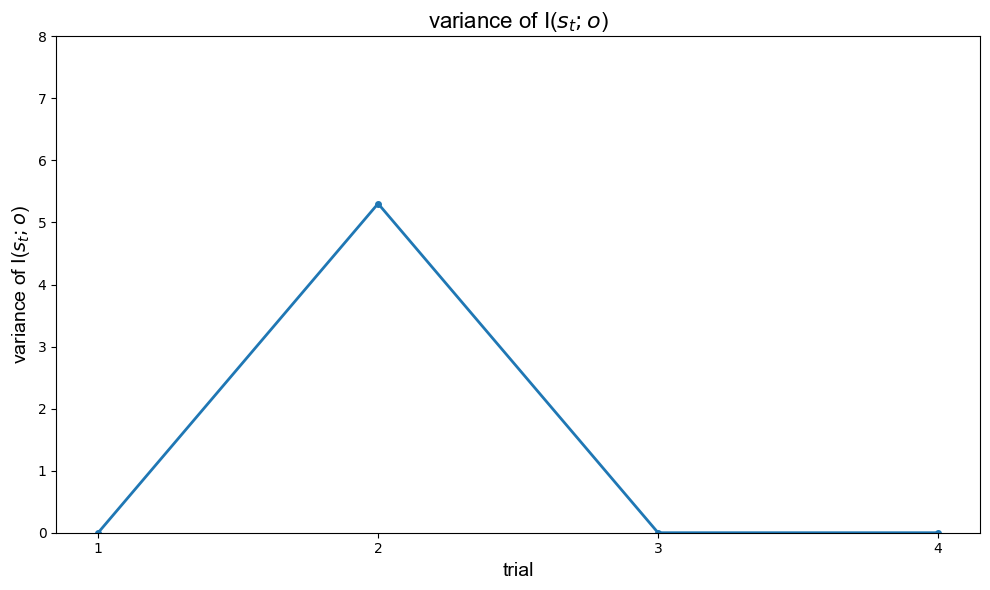

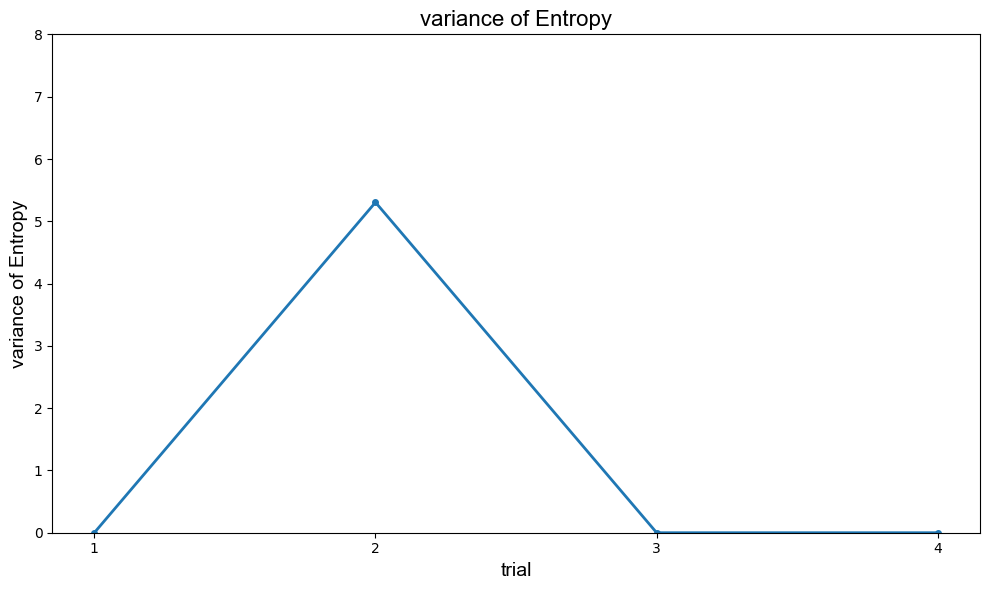

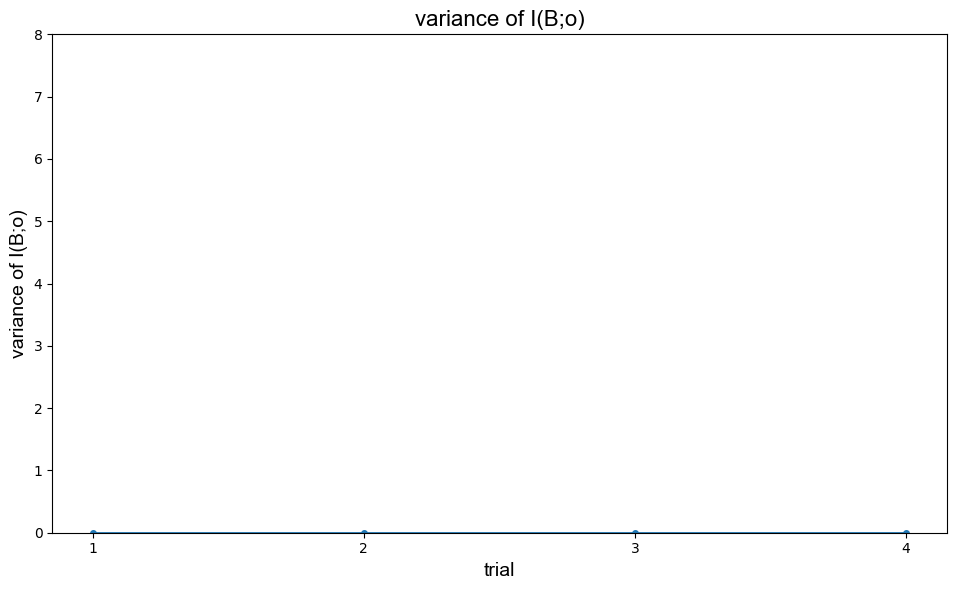

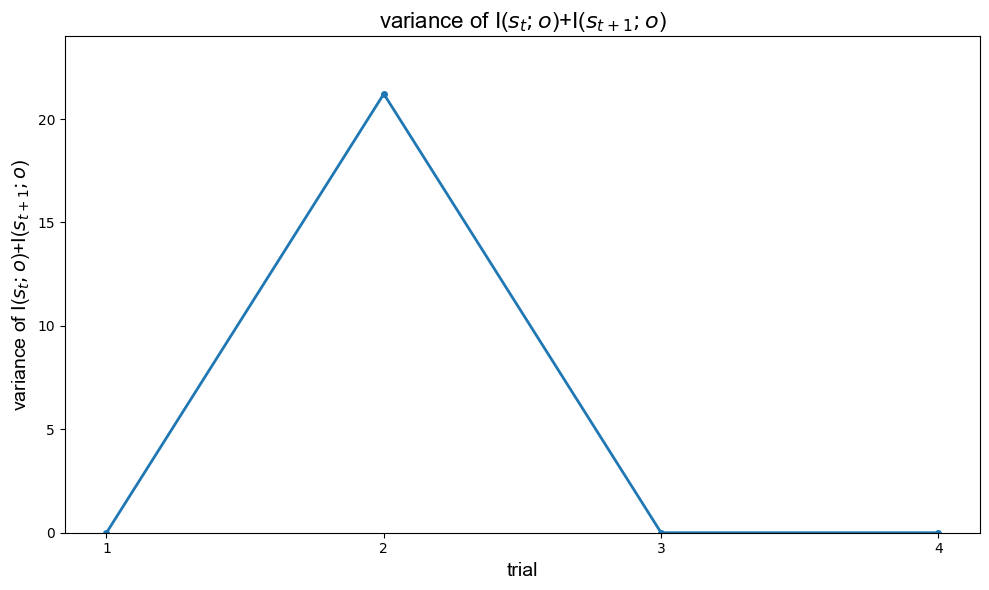

PBSの分散の平均: 1.3260
PBSの分散の標準偏差: 2.2968
PBSの分散の最大値: 5.3042
PBSの分散の最小値: 0.0000


In [14]:
import numpy as np

# PBSの分散を計算する関数
def calculate_pbs_variance(PBS):
    """
    各時刻におけるPBSの分散を計算する
    
    Parameters:
    PBS: リスト形式のPBS配列。各要素は各時刻のPBS値
    
    Returns:
    pbs_variances: 各時刻におけるPBSの分散のリスト
    """
    pbs_variances = []
    
    # 各時刻についてループ
    for t in range(len(PBS[0])):  # PBS[0]の長さ = 時刻数
        # 時刻tにおける各行動のPBS値を取得
        pbs_values_at_t = []
        for k in range(len(PBS)):  # k = 行動のインデックス
            pbs_values_at_t.append(PBS[k][t])
        
        # 時刻tにおけるPBSの分散を計算
        variance_t = np.var(pbs_values_at_t)
        pbs_variances.append(variance_t)
    
    return pbs_variances

# 使用例
pbs_st_variances = calculate_pbs_variance(PBS_st)
pbs_variances = calculate_pbs_variance(PBS)
I_B_o_variances=calculate_pbs_variance(pBS_pB)
H_qo_variances=calculate_pbs_variance(H_qo)
total_variances=calculate_pbs_variance(list(np.array(PBS_st)+np.array(PBS)))

# 結果の可視化
import matplotlib.pyplot as plt
ylim=8
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pbs_variances) + 1), pbs_variances, marker='o', linewidth=2, markersize=4)
plt.xlabel('trial', fontname="Arial", fontsize=14)
plt.xticks(range(1, len(pbs_variances) + 1)) 
plt.ylabel(r'variance of I($s_{t+1};o$)', fontname="Arial", fontsize=14)
plt.title(r'variance of I($s_{t+1};o$)', fontname="Arial", fontsize=16)
#plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(bottom=0,top=ylim) #17.5#30
plt.show()

ylim=8
plt.figure(figsize=(10, 6))
plt.plot(range(1,len(pbs_st_variances)+ 1), pbs_st_variances, marker='o', linewidth=2, markersize=4)
plt.xlabel('trial', fontname="Arial", fontsize=14)
plt.xticks(range(1, len(pbs_st_variances) + 1)) 
plt.ylabel(r'variance of I($s_{t};o$)', fontname="Arial", fontsize=14)
plt.title(r'variance of I($s_{t};o$)', fontname="Arial", fontsize=16)
#plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(bottom=0,top=ylim) #17.5#30
plt.show()

ylim=8
plt.figure(figsize=(10, 6))
plt.plot(range(1,len(H_qo_variances)+ 1), H_qo_variances, marker='o', linewidth=2, markersize=4)
plt.xlabel('trial', fontname="Arial", fontsize=14)
plt.xticks(range(1, len(H_qo_variances) + 1)) 
plt.ylabel(r'variance of Entropy', fontname="Arial", fontsize=14)
plt.title(r'variance of Entropy', fontname="Arial", fontsize=16)
#plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(bottom=0,top=ylim) #17.5#30
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1,len(I_B_o_variances)+ 1), I_B_o_variances, marker='o', linewidth=2, markersize=4)
plt.xlabel('trial', fontname="Arial", fontsize=14)
plt.xticks(range(1, len(I_B_o_variances) + 1)) 
plt.ylabel('variance of I(B;o)', fontname="Arial", fontsize=14)
plt.title('variance of I(B;o)', fontname="Arial", fontsize=16)
#plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(bottom=0,top=ylim)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(range(1,len(total_variances)+ 1), total_variances, marker='o', linewidth=2, markersize=4)
plt.xlabel('trial', fontname="Arial", fontsize=14)
plt.xticks(range(1, len(total_variances) + 1)) 
plt.ylabel(r'variance of I($s_{t};o$)+I($s_{t+1};o$)', fontname="Arial", fontsize=14)
plt.title(r'variance of I($s_{t};o$)+I($s_{t+1};o$)', fontname="Arial", fontsize=16)
#plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(bottom=0,top=ylim*3)
plt.show()

# 分散の統計情報を表示
print(f"PBSの分散の平均: {np.mean(pbs_variances):.4f}")
print(f"PBSの分散の標準偏差: {np.std(pbs_variances):.4f}")
print(f"PBSの分散の最大値: {np.max(pbs_variances):.4f}")
print(f"PBSの分散の最小値: {np.min(pbs_variances):.4f}")

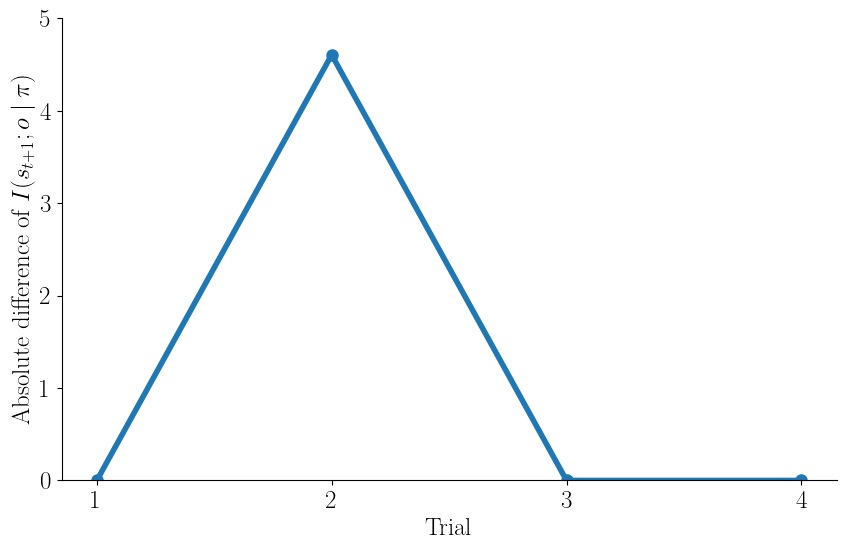

PBSの絶対差の平均: 1.1515
PBSの絶対差の標準偏差: 1.9945
PBSの絶対差の最大値: 4.6062
PBSの絶対差の最小値: 0.0000


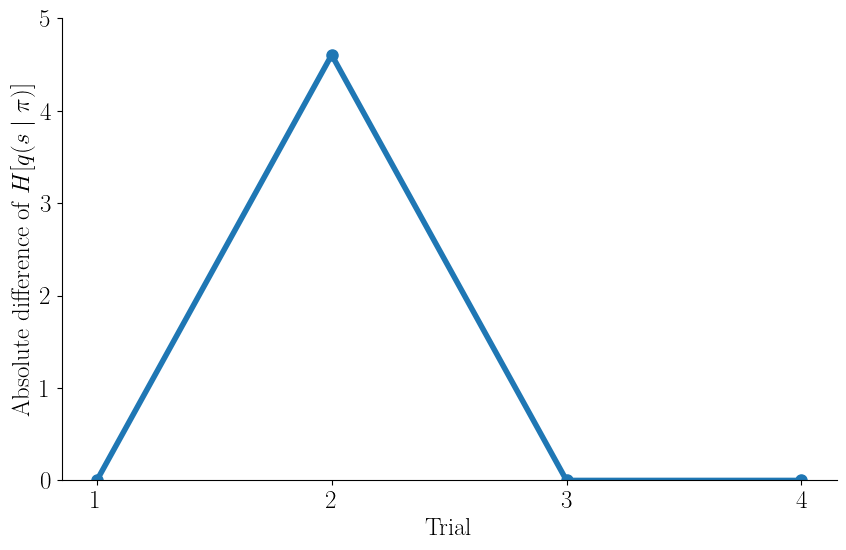

Entropyの絶対差の平均: 1.1515
Entropyの絶対差の標準偏差: 1.9945
Entropyの絶対差の最大値: 4.6062
Entropyの絶対差の最小値: 0.0000
pbs_absdiff と H_qs_absdiff を pbs_and_H_qs_absdiff_c3.pkl に保存しました


' ylim = 8\nplt.figure(figsize=(10, 6))\nplt.plot(range(1, len(H_qo_absdiff) + 1), H_qo_absdiff, marker=\'o\', linewidth=2, markersize=4)\nplt.xlabel(\'trial\', fontname="Arial", fontsize=20)\nplt.xticks(range(1, len(H_qo_absdiff) + 1)) \nplt.ylabel(r\'absolute difference of Entropy\', fontname="Arial", fontsize=20)\n#plt.title(r\'absolute difference of Entropy$)\', fontname="Arial", fontsize=16)\n#plt.tight_layout()\nplt.ylim(bottom=0, top=max(pbs_absdiff)*1.2)\nplt.rcParams.update({\n    "xtick.labelsize": 18,\n    "ytick.labelsize": 18\n}) \nax = plt.gca()\n\n# 上・右の枠線を消す\nax.spines[\'top\'].set_visible(False)\nax.spines[\'right\'].set_visible(False)'

In [15]:
import numpy as np

# PBSの差の絶対値を計算する関数
def calculate_pbs_absdiff(PBS):
    """
    各時刻におけるPBSの絶対差 |PBS[0][t] - PBS[1][t]| を計算する
    PBS: 行動 × 時刻 の2次元リスト/配列
    """
    abs_diffs = []

    for t in range(len(PBS[0])):  # 時刻数だけ回す
        diff_t = abs(PBS[0][t] - PBS[1][t])  # 1時刻=2値の絶対差
        abs_diffs.append(diff_t)

    return abs_diffs

font="Times new Roman"#"Arial"
axis_label_size=18
linewidth=4#2
markersize=8#4
# 使用例
pbs_st_absdiff = calculate_pbs_absdiff(PBS_st)
pbs_absdiff = calculate_pbs_absdiff(PBS)
I_B_o_absdiff = calculate_pbs_absdiff(pBS_pB)
H_qo_absdiff = calculate_pbs_absdiff(H_qo)
H_qs_absdiff = calculate_pbs_absdiff(H_qs)
total_absdiff = calculate_pbs_absdiff(list(np.array(PBS_st)+np.array(PBS)))

# ========================
# 可視化（例）
# ========================
import matplotlib.pyplot as plt

ylim = 8
plt.figure(figsize=(10, 6))
plt.rcParams.update({
    "text.usetex": True,          # ←これが重要
    "font.family": "serif",
})
plt.rcParams.update({
    "xtick.labelsize": 18,
    "ytick.labelsize": 18
})
plt.plot(range(1, len(pbs_absdiff) + 1), pbs_absdiff, marker='o', linewidth=linewidth, markersize=markersize)
plt.xlabel('Trial', fontname=font, fontsize=axis_label_size)
plt.xticks(range(1, len(pbs_absdiff) + 1)) 
plt.ylabel(r'Absolute difference of $I(s_{t+1};o \mid \pi)$', fontname=font, fontsize=axis_label_size)
#plt.title(r'absolute difference of I($s_{t+1};o$)', fontname="Arial", fontsize=16)
#plt.tight_layout()
plt.ylim(bottom=0, top=5)#max(pbs_absdiff)*1.2
# plt.rcParams.update({
#     "xtick.labelsize": 18,
#     "ytick.labelsize": 18
# })
ax = plt.gca()

# 上・右の枠線を消す
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

filename = f"Iso_diff_sa2{sa2}_sb{sb1}.tif"
plt.savefig(
    filename,
    format="tiff",
    dpi=600,                 # APA・多くのジャーナルで推奨
    bbox_inches="tight"
)
plt.show()

# 統計情報
print(f"PBSの絶対差の平均: {np.mean(pbs_absdiff):.4f}")
print(f"PBSの絶対差の標準偏差: {np.std(pbs_absdiff):.4f}")
print(f"PBSの絶対差の最大値: {np.max(pbs_absdiff):.4f}")
print(f"PBSの絶対差の最小値: {np.min(pbs_absdiff):.4f}")


ylim = 8
plt.figure(figsize=(10, 6))
plt.rcParams.update({
    "text.usetex": True,          # ←これが重要
    "font.family": "serif",
})
plt.plot(range(1, len(H_qs_absdiff) + 1), H_qs_absdiff, marker='o', linewidth=linewidth, markersize=markersize)
plt.xlabel('Trial', fontname=font, fontsize=axis_label_size)
plt.xticks(range(1, len(H_qs_absdiff) + 1)) 
plt.ylabel(r'Absolute difference of $H[q(s\mid \pi)]$', fontname=font, fontsize=axis_label_size)
#plt.title(r'absolute difference of Entropy$)', fontname="Arial", fontsize=16)
#plt.tight_layout()
plt.ylim(bottom=0, top=5)#max(H_qs_absdiff)*1.2
plt.rcParams.update({
    "xtick.labelsize": 18,
    "ytick.labelsize": 18
})
ax = plt.gca()

# 上・右の枠線を消す
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


filename = f"Hqs_diff_sa2{sa2}_sb{sb1}.tif"
plt.savefig(
    filename,
    format="tiff",
    dpi=600,                 # APA・多くのジャーナルで推奨
    bbox_inches="tight"
)
plt.show()


# 統計情報
print(f"Entropyの絶対差の平均: {np.mean(H_qo_absdiff):.4f}")
print(f"Entropyの絶対差の標準偏差: {np.std(H_qo_absdiff):.4f}")
print(f"Entropyの絶対差の最大値: {np.max(H_qo_absdiff):.4f}")
print(f"Entropyの絶対差の最小値: {np.min(H_qo_absdiff):.4f}")

# ========================
# pickleに保存
# ========================
import pickle

save_path = "pbs_and_H_qs_absdiff_c3.pkl"

with open(save_path, "wb") as f:
    pickle.dump(
        {
            "pbs_absdiff_c3": pbs_absdiff,
            "H_qs_absdiff_c3": H_qs_absdiff
        },
        f
    )

print(f"pbs_absdiff と H_qs_absdiff を {save_path} に保存しました")

""" ylim = 8
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(H_qo_absdiff) + 1), H_qo_absdiff, marker='o', linewidth=2, markersize=4)
plt.xlabel('trial', fontname="Arial", fontsize=20)
plt.xticks(range(1, len(H_qo_absdiff) + 1)) 
plt.ylabel(r'absolute difference of Entropy', fontname="Arial", fontsize=20)
#plt.title(r'absolute difference of Entropy$)', fontname="Arial", fontsize=16)
#plt.tight_layout()
plt.ylim(bottom=0, top=max(pbs_absdiff)*1.2)
plt.rcParams.update({
    "xtick.labelsize": 18,
    "ytick.labelsize": 18
}) 
ax = plt.gca()

# 上・右の枠線を消す
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)"""


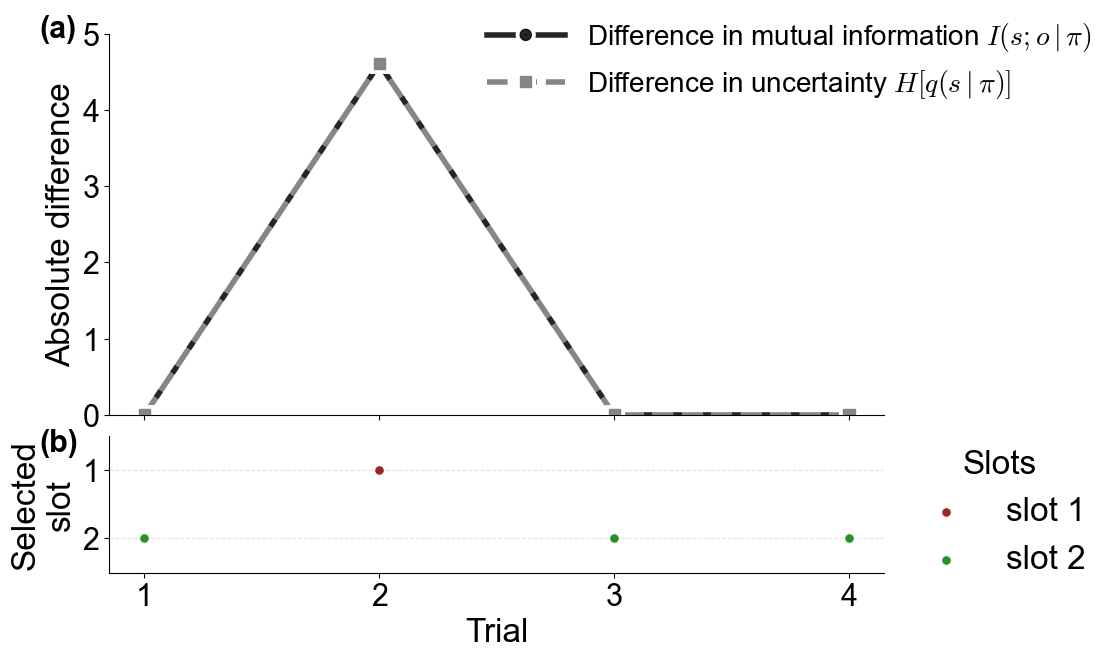

Iso abs diff mean: 1.1515
Iso abs diff std : 1.9945
Iso abs diff max : 4.6062
Iso abs diff min : 0.0000
Hqs abs diff mean: 1.1513
Hqs abs diff std : 1.9941
Hqs abs diff max : 4.6052
Hqs abs diff min : 0.0000
(np.float64(0.3333333333333333), np.int64(1))


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# =========================
# NeurIPS-style combined fig
# =========================

font = "Arial"#"Times New Roman"
T = len(pbs_absdiff)
x = np.arange(1, T + 1)

iso = np.asarray(pbs_absdiff)
hqs = np.asarray(H_qs_absdiff)
actions = np.asarray(selected_slot_array)

assert len(hqs) == T
assert len(actions) == T

plt.rcParams.update({
     "text.usetex": False,#True,
    # "font.family": "serif",
    # "font.serif": ["Times New Roman"],
    "font.family": "sans-serif",
    "font.sans-serif": [font,"Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "cm", 
    # "mathtext.fontset": "custom",
    # "mathtext.rm": "Helvetica",
    # "mathtext.it": "Helvetica:italic",
    # "mathtext.bf": "Helvetica:bold",
    "xtick.labelsize": 22,#18,
    "ytick.labelsize": 22,#18,
    "axes.labelsize": 24,#20,
    "legend.fontsize": 20,#24,#16,
})

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 7),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3.2, 1.15],
        "hspace": 0.08
    }
)

# -------------------------
# Upper panel: Iso diff & Hqs diff
# -------------------------

outline = [
    pe.Stroke(linewidth=linewidth + 2.5, foreground="white"),
    pe.Normal()
]

ax1.plot(
    x, iso,
    marker="o",
    linewidth=linewidth,
    markersize=markersize,
    linestyle="-",
    color="black",
    alpha=0.85,
    label=r"Difference in mutual information $I(s; o \mid \pi)$",#r"$| \Delta I(s_{t+1}; o \mid \pi) |$",
    path_effects=outline,
    zorder=3
)

ax1.plot(
    x, hqs,
    marker="s",
    linewidth=linewidth,
    markersize=markersize,
    linestyle="--",
    color="gray",
    alpha=0.95,
    label=r"Difference in uncertainty $H[q(s \mid \pi)]$",#r"$| \Delta H[q(s \mid \pi)] |$",
    path_effects=outline,
    zorder=4
)

ax1.set_ylabel("Absolute difference", fontname=font)
ax1.set_ylim(bottom=0, top=5)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

ax1.legend(
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1.3, 1.1),#(1.3, 1.0),  # ← 右に少しずらす
    handlelength=2.8
)

# x tick labels are shown only on lower panel
ax1.tick_params(axis="x", labelbottom=False)

# -------------------------
# Lower panel: selected slot
# -------------------------

colors = ["darkred", "green", "orange", "purple"]
slot_labels = [f"slot {i+1}" for i in range(num_slot)]

for slot in range(1, num_slot + 1):
    slot_trials = x[actions == slot]
    ax2.scatter(
        slot_trials,
        np.full_like(slot_trials, slot),
        color=colors[slot - 1],
        label=slot_labels[slot - 1],
        s=45,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.6,
        zorder=3
    )

ax2.set_xlabel("Trial", fontname=font)
ax2.set_ylabel("Selected\nslot", fontname=font)

ax2.set_yticks(np.arange(1, num_slot + 1))
ax2.set_ylim(num_slot + 0.5, 0.5)  # invert y-axis

ax2.grid(axis="y", linestyle="--", alpha=0.35)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

ax2.legend(
    title="Slots",
    frameon=False,
    fontsize=24,#14,
    title_fontsize=24,#15,
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    borderaxespad=0.
)
# -------------------------
# Panel labels (a), (b)
# -------------------------

ax1.text(
    -0.09, 1.05, "(a)",#-0.08, 1.05, "(a)",
    transform=ax1.transAxes,
    fontsize=22,#20,
    fontweight="bold",
    va="top",
    ha="left"
)

ax2.text(
    -0.09, 1.05, "(b)",#-0.08, 1.05, "(b)",
    transform=ax2.transAxes,
    fontsize=22,#20,
    fontweight="bold",
    va="top",
    ha="left"
)

# x-axis ticks
ax2.set_xticks(np.arange(1, T + 1))
# 試行数が多い場合はこちらの方が綺麗です
# ax2.set_xticks(np.linspace(1, T, min(T, 11), dtype=int))

# -------------------------
# Save
# -------------------------

filename = f"Combined_diff_slot_sa2{sa2}_sb{sb1}.tif"

fig.savefig(
    filename,
    format="tiff",
    dpi=1200,
    bbox_inches="tight"
)

plt.show()

# =========================
# Statistics
# =========================

print(f"Iso abs diff mean: {np.mean(iso):.4f}")
print(f"Iso abs diff std : {np.std(iso):.4f}")
print(f"Iso abs diff max : {np.max(iso):.4f}")
print(f"Iso abs diff min : {np.min(iso):.4f}")

print(f"Hqs abs diff mean: {np.mean(hqs):.4f}")
print(f"Hqs abs diff std : {np.std(hqs):.4f}")
print(f"Hqs abs diff max : {np.max(hqs):.4f}")
print(f"Hqs abs diff min : {np.min(hqs):.4f}")


def consecutive_ratio(selected_slot_array):
    arr = np.asarray(selected_slot_array)
    consecutive = arr[:-1] == arr[1:]
    ratio = consecutive.sum() / len(consecutive)
    return ratio, consecutive.sum()

print(consecutive_ratio(actions))

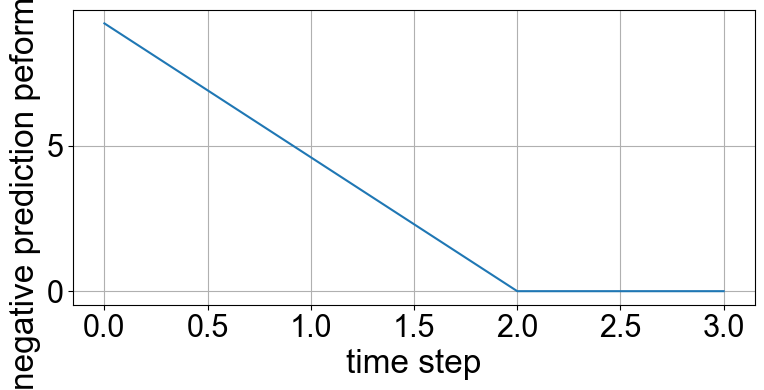

1~10タイムステップの平均: 3.4539
21~30タイムステップの平均: nan
後半10タイムステップの平均: 3.4539


In [17]:
##全スロットに対するsの予測パフォーマンスΣtlnq(s_true)
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
prediction_performance=jnp.array(prediction_performance)
# 1次元目に沿って和（形状: (T,)）
s = jnp.sum(prediction_performance, axis=1)
#print(s)
# 横軸: 二次元目（time step）
t = np.arange(prediction_performance.shape[0])

plt.figure(figsize=(8, 4))
plt.plot(t, np.asarray(s))
plt.xlabel('time step')
plt.ylabel('negative prediction peformance')
plt.grid(True)
plt.tight_layout()
plt.show()

# 前半10タイムステップの平均を計算
steps10 = s[:10]  # 最後の10要素を取得
average_last_10 = jnp.mean(steps10)  # 平均を計算
print(f"1~10タイムステップの平均: {average_last_10:.4f}")
# 41~50タイムステップの平均を計算
steps41_50 = s[20:30]  # 最後の10要素を取得
average_last_10 = jnp.mean(steps41_50)  # 平均を計算
print(f"21~30タイムステップの平均: {average_last_10:.4f}")

# 後半10タイムステップの平均を計算
last_10_steps = s[-10:]  # 最後の10要素を取得
average_last_10 = jnp.mean(last_10_steps)  # 平均を計算
print(f"後半10タイムステップの平均: {average_last_10:.4f}")

In [18]:
# ##スロット1に対するsの予測パフォーマンス-Σtlnq(s_true)

# s = prediction_performance[:,0]
# #print(s)
# # 横軸: 二次元目（time step）
# t = np.arange(prediction_performance.shape[0])

# plt.figure(figsize=(8, 4))
# plt.plot(t, np.asarray(s))
# plt.xlabel('time step')
# plt.ylabel('negative prediction peformance for slot1')
# plt.grid(True)
# plt.tight_layout()
# plt.show()
# # 前半10タイムステップの平均を計算
# steps10 = s[:10]  # 最後の10要素を取得
# average_last_10 = jnp.mean(steps10)  # 平均を計算
# print(f"1~10タイムステップの平均: {average_last_10:.4f}")
# # 41~50タイムステップの平均を計算
# steps41_50 = s[40:50]  # 最後の10要素を取得
# average_last_10 = jnp.mean(steps41_50)  # 平均を計算
# print(f"41~50タイムステップの平均: {average_last_10:.4f}")

# # 後半10タイムステップの平均を計算
# last_10_steps = s[-10:]  # 最後の10要素を取得
# average_last_10 = jnp.mean(last_10_steps)  # 平均を計算
# print(f"後半10タイムステップの平均: {average_last_10:.4f}")

# ##スロット2に対するsの予測パフォーマンス-Σtlnq(s_true)
# # 1次元目に沿って和（形状: (T,)）
# s = prediction_performance[:,1]
# #print(s)
# # 横軸: 二次元目（time step）
# t = np.arange(prediction_performance.shape[0])

# plt.figure(figsize=(8, 4))
# plt.plot(t, np.asarray(s))
# plt.xlabel('time step')
# plt.ylabel('negative prediction peformance for slot2')
# plt.grid(True)
# plt.tight_layout()
# plt.show()
# # 前半10タイムステップの平均を計算
# steps10 = s[:10]  # 最後の10要素を取得
# average_last_10 = jnp.mean(steps10)  # 平均を計算
# print(f"1~10タイムステップの平均: {average_last_10:.4f}")
# # 41~50タイムステップの平均を計算
# steps41_50 = s[40:50]  # 最後の10要素を取得
# average_last_10 = jnp.mean(steps41_50)  # 平均を計算
# print(f"41~50タイムステップの平均: {average_last_10:.4f}")

# # 後半10タイムステップの平均を計算
# last_10_steps = s[-10:]  # 最後の10要素を取得
# average_last_10 = jnp.mean(last_10_steps)  # 平均を計算
# print(f"後半10タイムステップの平均: {average_last_10:.4f}")

# ##スロット3に対するsの予測パフォーマンス-Σtlnq(s_true)
# # 1次元目に沿って和（形状: (T,)）
# s = prediction_performance[:,2]
# #print(s)
# # 横軸: 二次元目（time step）
# t = np.arange(prediction_performance.shape[0])

# plt.figure(figsize=(8, 4))
# plt.plot(t, np.asarray(s))
# plt.xlabel('time step')
# plt.ylabel('negative prediction peformance for slot3')
# plt.grid(True)
# plt.tight_layout()
# plt.show()
# # 前半10タイムステップの平均を計算
# steps10 = s[:10]  # 最後の10要素を取得
# average_last_10 = jnp.mean(steps10)  # 平均を計算
# print(f"1~10タイムステップの平均: {average_last_10:.4f}")
# # 41~50タイムステップの平均を計算
# steps41_50 = s[40:50]  # 最後の10要素を取得
# average_last_10 = jnp.mean(steps41_50)  # 平均を計算
# print(f"41~50タイムステップの平均: {average_last_10:.4f}")

# # 後半10タイムステップの平均を計算
# last_10_steps = s[-10:]  # 最後の10要素を取得
# average_last_10 = jnp.mean(last_10_steps)  # 平均を計算
# print(f"後半10タイムステップの平均: {average_last_10:.4f}")
# ##スロット4に対するsの予測パフォーマンス-Σtlnq(s_true)
# # 1次元目に沿って和（形状: (T,)）
# s = prediction_performance[:,3]
# #print(s)
# # 横軸: 二次元目（time step）
# t = np.arange(prediction_performance.shape[0])

# plt.figure(figsize=(8, 4))
# plt.plot(t, np.asarray(s))
# plt.xlabel('time step')
# plt.ylabel('negative prediction peformance for slot4')
# plt.grid(True)
# plt.tight_layout()
# plt.show()
# # 前半10タイムステップの平均を計算
# steps10 = s[:10]  # 最後の10要素を取得
# average_last_10 = jnp.mean(steps10)  # 平均を計算
# print(f"1~10タイムステップの平均: {average_last_10:.4f}")
# # 41~50タイムステップの平均を計算
# steps41_50 = s[40:50]  # 最後の10要素を取得
# average_last_10 = jnp.mean(steps41_50)  # 平均を計算
# print(f"41~50タイムステップの平均: {average_last_10:.4f}")

# # 後半10タイムステップの平均を計算
# last_10_steps = s[-10:]  # 最後の10要素を取得
# average_last_10 = jnp.mean(last_10_steps)  # 平均を計算
# print(f"後半10タイムステップの平均: {average_last_10:.4f}")

In [19]:
def selected_policy_entropy(entropy, selected_slot):
    # selected_slotは1~4の整数を含む長さTのリスト
    # entropyは4*Tのリスト
    selected_slot=jnp.array(selected_slot)
    #selected_slot=selected_slot[1:]#1時刻目ランダムの場合
    entropy=jnp.array(entropy)
    entropy=entropy[:,:-1]
    # selected_slotの値に対応するインデックスの要素をentropyから取り出す
    selected_elements = []
    for t in range(len(selected_slot)):
        slot_index = selected_slot[t] - 1  # 1〜4の値を0〜3のインデックスに変換
        if 0 <= slot_index < 4:
            selected_elements.append(entropy[slot_index][t])
    return selected_elements

In [20]:
print(pbs)
flat_value=jnp.array([1,1,1,1])
flat_value=jnp.expand_dims(flat_value,0)
print(flat_value)

[[7.9232665e-13 2.1556370e-14]]
[[1 1 1 1]]


In [21]:
#array_selected_slot
PBS_select=selected_policy_entropy(PBS,selected_slot_array)
PBS_st_select=selected_policy_entropy(PBS_st,selected_slot_array)
Hqo_select=selected_policy_entropy(Hqo,selected_slot_array)
PBS_pB_select=selected_policy_entropy(pBS_pB,selected_slot_array)
#MI_m_o_select=selected_policy_entropy(MI_model_o,selected_slot_array)

In [22]:
import numpy as np

def calculate_selected_policy_averages(pbs_select, hqo_select, pbs_pb_select):
    """
    選択されたポリシーの前半5stepと後半5stepの平均値を計算する
    
    Parameters:
    pbs_select: 選択されたポリシーのPBSデータ
    hqo_select: 選択されたポリシーのHqoデータ
    pbs_pb_select: 選択されたポリシーのpBS_pBデータ
    
    Returns:
    results: 各指標の前半・後半平均値を含む辞書
    """
    
    # データをnumpy配列に変換
    pbs_array = np.array(pbs_select)
    hqo_array = np.array(hqo_select)
    pbs_pb_array = np.array(pbs_pb_select)
    
    # データの長さを確認
    data_length = len(pbs_array)
    print(f"データの長さ: {data_length}")
    
    # 前半5step（1-5）
    first_5_steps = slice(0, 5)
    # 後半5step（最後の5つ）
    last_5_steps = slice(-5, None)
    
    results = {}
    
    # PBS_selectの平均値計算
    pbs_first_5_avg = np.mean(pbs_array[first_5_steps])
    pbs_last_5_avg = np.mean(pbs_array[last_5_steps])
    results['pbs_select'] = {
        'first_5_avg': pbs_first_5_avg,
        'last_5_avg': pbs_last_5_avg,
        'change': pbs_last_5_avg - pbs_first_5_avg
    }
    
    # Hqo_selectの平均値計算
    hqo_first_5_avg = np.mean(hqo_array[first_5_steps])
    hqo_last_5_avg = np.mean(hqo_array[last_5_steps])
    results['hqo_select'] = {
        'first_5_avg': hqo_first_5_avg,
        'last_5_avg': hqo_last_5_avg,
        'change': hqo_last_5_avg - hqo_first_5_avg
    }
    
    # PBS_pB_selectの平均値計算
    pbs_pb_first_5_avg = np.mean(pbs_pb_array[first_5_steps])
    pbs_pb_last_5_avg = np.mean(pbs_pb_array[last_5_steps])
    results['pbs_pb_select'] = {
        'first_5_avg': pbs_pb_first_5_avg,
        'last_5_avg': pbs_pb_last_5_avg,
        'change': pbs_pb_last_5_avg - pbs_pb_first_5_avg
    }
    
    return results

# 実行
try:
    # 平均値計算
    results = calculate_selected_policy_averages(PBS_select, Hqo_select, PBS_pB_select)
    
    # 結果の表示
    print("\n=== 選択されたポリシーの前半5stepと後半5stepの平均値 ===")
    
    print("\n--- PBS_select ---")
    print(f"前半5step平均: {results['pbs_select']['first_5_avg']:.4f}")
    print(f"後半5step平均: {results['pbs_select']['last_5_avg']:.4f}")
    print(f"変化量: {results['pbs_select']['change']:.4f}")
    
    print("\n--- Hqo_select ---")
    print(f"前半5step平均: {results['hqo_select']['first_5_avg']:.4f}")
    print(f"後半5step平均: {results['hqo_select']['last_5_avg']:.4f}")
    print(f"変化量: {results['hqo_select']['change']:.4f}")
    
    print("\n--- PBS_pB_select ---")
    print(f"前半5step平均: {results['pbs_pb_select']['first_5_avg']:.4f}")
    print(f"後半5step平均: {results['pbs_pb_select']['last_5_avg']:.4f}")
    print(f"変化量: {results['pbs_pb_select']['change']:.4f}")
    
    # 詳細なデータ表示
    print("\n=== 詳細データ ===")
    print(f"PBS_select前半5step: {PBS_select[:5]}")
    print(f"PBS_select後半5step: {PBS_select[-5:]}")
    print(f"Hqo_select前半5step: {Hqo_select[:5]}")
    print(f"Hqo_select後半5step: {Hqo_select[-5:]}")
    print(f"PBS_pB_select前半5step: {PBS_pB_select[:5]}")
    print(f"PBS_pB_select後半5step: {PBS_pB_select[-5:]}")
    
    # 統計情報
    print("\n=== 統計情報 ===")
    print(f"PBS_select全体平均: {np.mean(PBS_select):.4f}")
    print(f"Hqo_select全体平均: {np.mean(Hqo_select):.4f}")
    print(f"PBS_pB_select全体平均: {np.mean(PBS_pB_select):.4f}")
    
    print(f"PBS_select全体標準偏差: {np.std(PBS_select):.4f}")
    print(f"Hqo_select全体標準偏差: {np.std(Hqo_select):.4f}")
    print(f"PBS_pB_select全体標準偏差: {np.std(PBS_pB_select):.4f}")

except Exception as e:
    print(f"エラーが発生しました: {e}")
    print("データの形式を確認してください。")

データの長さ: 4

=== 選択されたポリシーの前半5stepと後半5stepの平均値 ===

--- PBS_select ---
前半5step平均: 2.3029
後半5step平均: 2.3029
変化量: 0.0000

--- Hqo_select ---
前半5step平均: 0.0000
後半5step平均: 0.0000
変化量: 0.0000

--- PBS_pB_select ---
前半5step平均: 0.0000
後半5step平均: 0.0000
変化量: 0.0000

=== 詳細データ ===
PBS_select前半5step: [Array(4.605727, dtype=float32), Array(4.60594, dtype=float32), Array(8.306665e-13, dtype=float32), Array(8.306665e-13, dtype=float32)]
PBS_select後半5step: [Array(4.605727, dtype=float32), Array(4.60594, dtype=float32), Array(8.306665e-13, dtype=float32), Array(8.306665e-13, dtype=float32)]
Hqo_select前半5step: [Array(7.9232665e-13, dtype=float32), Array(7.9232665e-13, dtype=float32), Array(7.9232665e-13, dtype=float32), Array(7.9232665e-13, dtype=float32)]
Hqo_select後半5step: [Array(7.9232665e-13, dtype=float32), Array(7.9232665e-13, dtype=float32), Array(7.9232665e-13, dtype=float32), Array(7.9232665e-13, dtype=float32)]
PBS_pB_select前半5step: [Array(0., dtype=float32), Array(0., dtype=float32), Array(0.

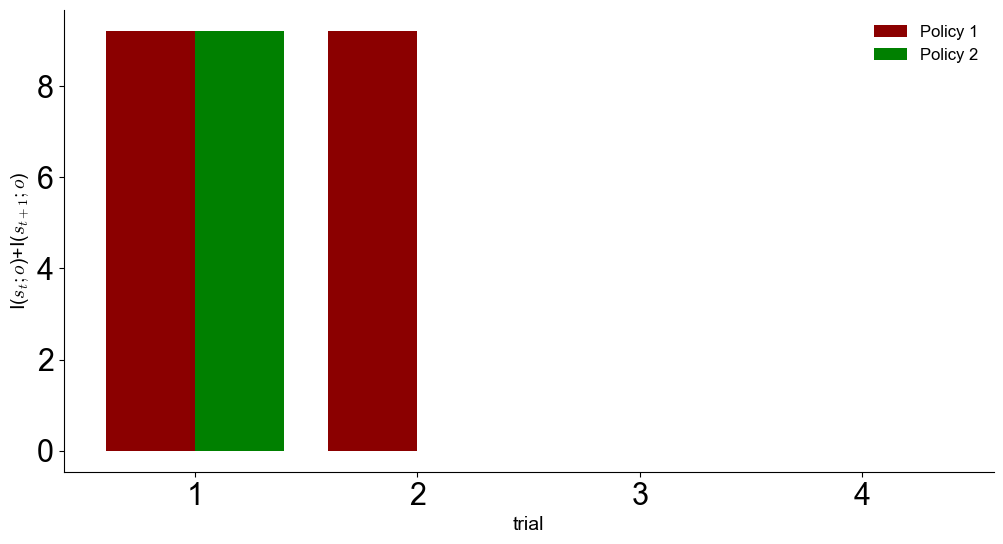

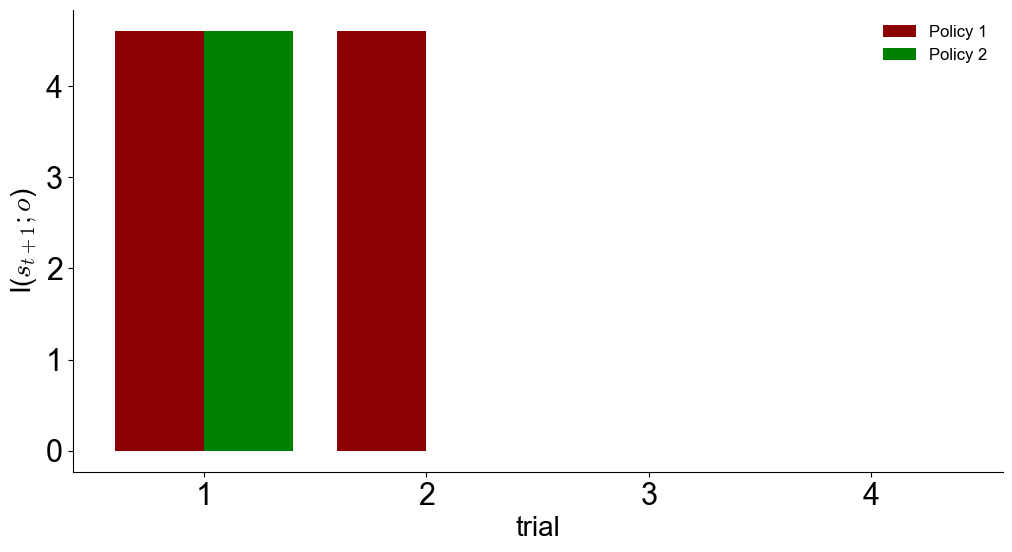

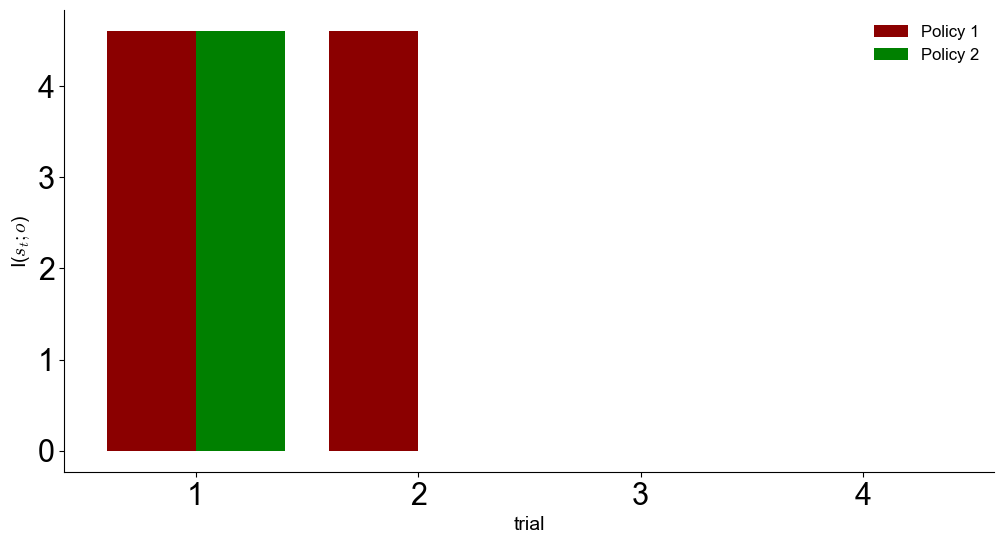

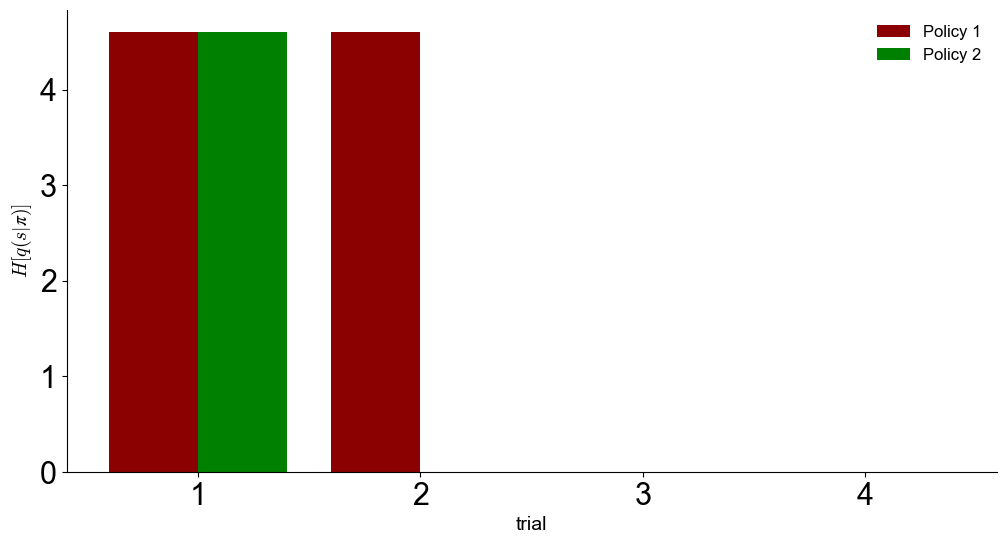

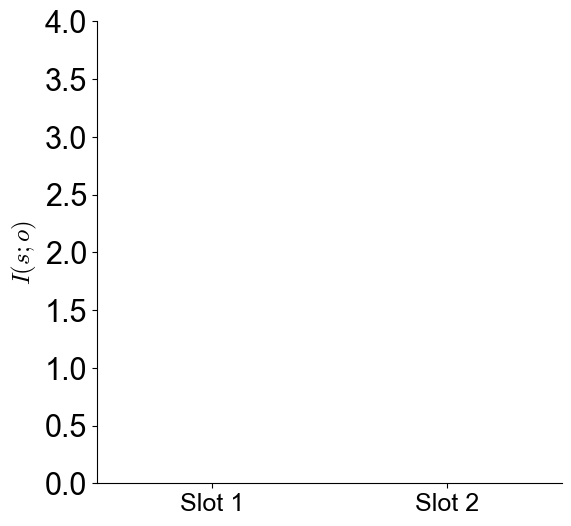

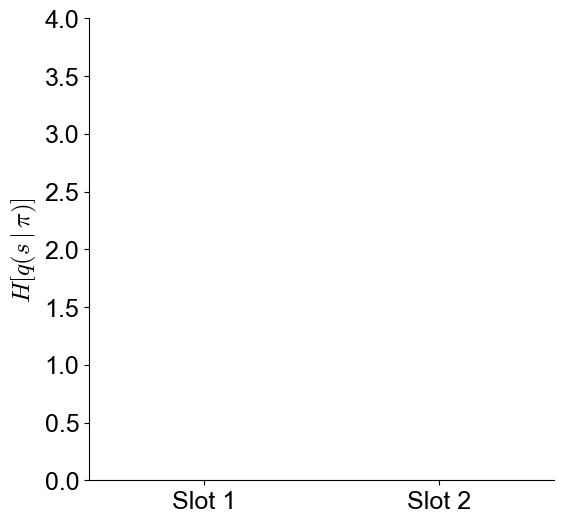

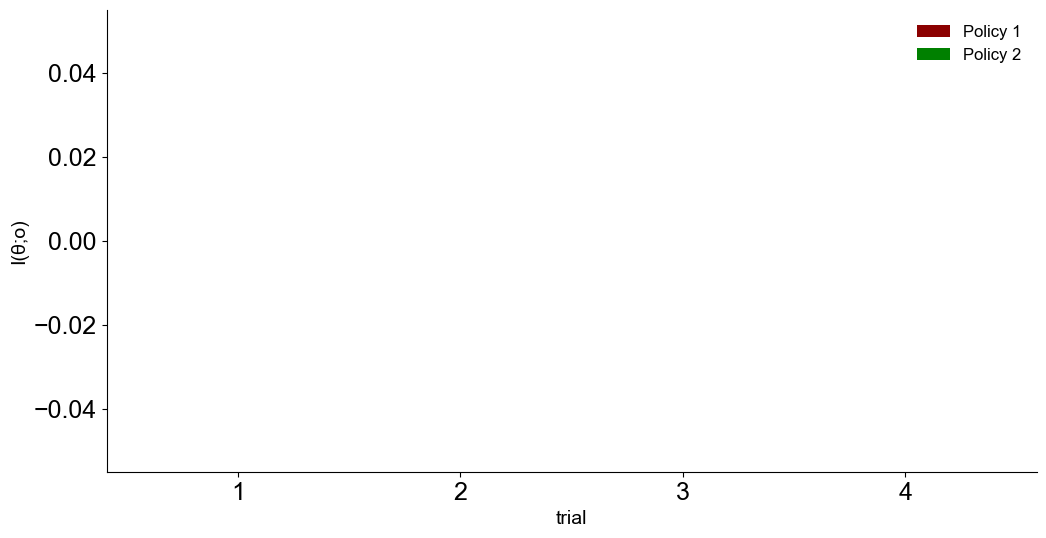

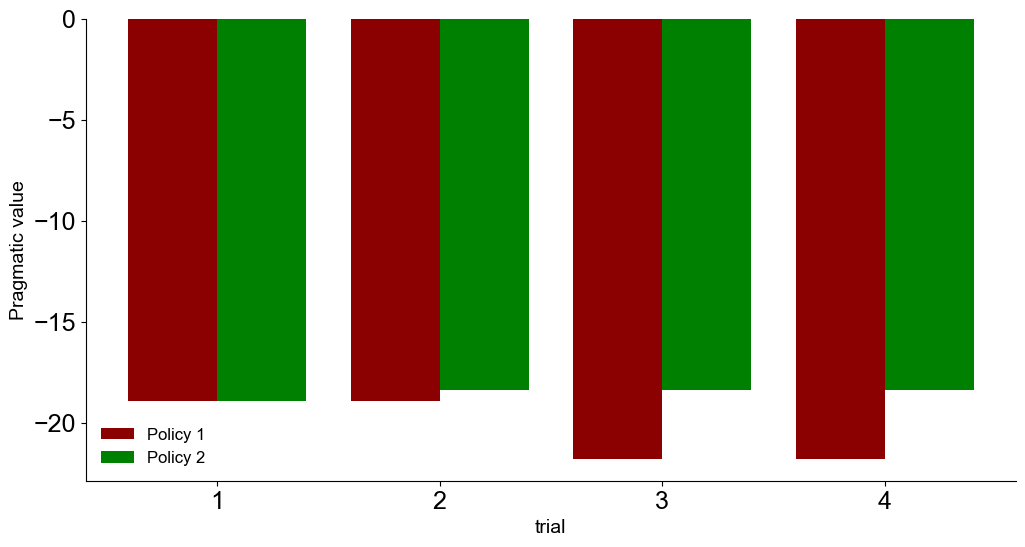

In [23]:
#print(actions4)
#print(len(EFE[0]))
##プロット
%matplotlib inline
import matplotlib
#matplotlib.use('Qt5Agg')  # Qt5Aggをバックエンドとして使用
import matplotlib.pyplot as plt

if __name__ == "__main__": 
  #labels=['1','2','3','4','5','6','7','8','9','10']  # set the dates as labels
  #x0 = np.arange(len(labels))  # create an array of values for the ticks that can perform arithmetic with width (w)
  labels=[str(i) for i in range(1, T + 1)]#T+1
  #print(labels)
  x0 = np.arange(T)#T

# create the data groups with a dict comprehension and groupby
  # マージンを設定
  margin = 0.2  #0 <margin< 1
  total_width = 1 - margin
  colors = ['darkred', 'green', 'orange', 'purple']
#EFEの可視化
  fig, ax = plt.subplots(figsize=(12, 6))
  # 棒グラフをプロット
  """ for i, h in enumerate(EFE):
    pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
    plt.bar(pos, h, width = total_width/len(EFE)) """
  num_policies = num_slot
  #EFE_temp=-np.array(Pragmaticvalue)-np.array(PBS)-np.array(MI_model_o)*MI_mo_weight
  EFE_temp=np.array(PBS)+np.array(PBS_st)
  for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(EFE_temp) )/2
     ax.bar(pos, EFE_temp[i], color=colors[i],width=total_width/len(EFE_temp), label=f'Policy {i+1}')
  """ for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(pBS_pB) )/2
     ax.bar(pos, pBS_pB[i], color=colors[i],width=total_width/len(pBS_pB), label=f'Policy {i+1}') """
  # ラベルの設定
  plt.xticks(x0, labels)
  plt.xlabel("trial", fontname="Arial", fontsize=14)
  #plt.ylabel("EFE", fontname="Arial", fontsize=14)
  plt.ylabel(r'I($s_{t};o$)+I($s_{t+1};o$)', fontname="Arial", fontsize=14)
  #plt.ylabel("pBS_pB", fontname="Arial", fontsize=14)
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  plt.legend(fontsize=12, frameon=False)
  #plt.ylim(top=120) #17.5#30
  plt.show


  #EFEの可視化
  fig, ax = plt.subplots(figsize=(12, 6))
  # 棒グラフをプロット
  """ for i, h in enumerate(EFE):
    pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
    plt.bar(pos, h, width = total_width/len(EFE)) """
  num_policies = num_slot
  """ for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
     ax.bar(pos, EFE[i], width=total_width/len(EFE), label=f'Policy {i+1}') """
  for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(PBS) )/2
     ax.bar(pos, PBS[i],color=colors[i], width=total_width/len(PBS), label=f'Policy {i+1}')
  # ラベルの設定
  plt.xticks(x0, labels)
  plt.xlabel("trial", fontname="Arial", fontsize=20)
  #plt.ylabel("EFE", fontname="Arial", fontsize=14)
  plt.ylabel(r'I($s_{t+1};o$)', fontname="Arial", fontsize=20)
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  plt.legend(fontsize=12, frameon=False)
  #plt.ylim(top=120) #17.5#30
  plt.show

  #EFEの可視化
  fig, ax = plt.subplots(figsize=(12, 6))
  # 棒グラフをプロット
  """ for i, h in enumerate(EFE):
    pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
    plt.bar(pos, h, width = total_width/len(EFE)) """
  num_policies = num_slot
  """ for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
     ax.bar(pos, EFE[i], width=total_width/len(EFE), label=f'Policy {i+1}') """
  for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(PBS) )/2
     ax.bar(pos, PBS_st[i],color=colors[i], width=total_width/len(PBS_st), label=f'Policy {i+1}')
  # ラベルの設定
  plt.xticks(x0, labels)
  plt.xlabel("trial", fontname="Arial", fontsize=14)
  #plt.ylabel("EFE", fontname="Arial", fontsize=14)
  plt.ylabel(r'I($s_{t};o$)', fontname="Arial", fontsize=14)
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  plt.legend(fontsize=12, frameon=False)
  #plt.ylim(top=120) #17.5#30
  plt.show

# build the plots
#subs = df.subsidiary.unique()
  stacks = num_slot # how many stacks in each group for a tick location
# set the width
  w = 0.15

#EFEの可視化
  fig, ax = plt.subplots(figsize=(12, 6))
  # 棒グラフをプロット
  """ for i, h in enumerate(EFE):
    pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
    plt.bar(pos, h, width = total_width/len(EFE)) """
  num_policies = num_slot
  """ for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
     ax.bar(pos, EFE[i], width=total_width/len(EFE), label=f'Policy {i+1}') """
  for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(H_qs) )/2
     ax.bar(pos, H_qs[i],color=colors[i], width=total_width/len(H_qs), label=f'Policy {i+1}')
  # ラベルの設定
  plt.xticks(x0, labels)
  plt.xlabel("trial", fontname="Arial", fontsize=14)
  #plt.ylabel("EFE", fontname="Arial", fontsize=14)
  plt.ylabel(r'$H[q(s|π)]$', fontname="Arial", fontsize=14)
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  plt.legend(fontsize=12, frameon=False)
  #plt.ylim(top=120) #17.5#30
  plt.show
  #print(np.array(H_qs).shape)


  colors_temp = ['cyan', 'orange']
  fig, ax = plt.subplots(figsize=(6,6))

  t = 2  # 3時刻目
  num_policies = num_slot

  # 横軸
  x = np.arange(num_policies)

  # 3時刻目の値
  y = [PBS[i][t] for i in range(num_policies)]

  # 棒グラフ
  ax.bar(x, y, color=colors_temp[:num_policies])

  # 横軸ラベル
  ax.set_xticks(x)
  ax.set_xticklabels([f'Slot {i+1}' for i in range(num_policies)], fontsize=18)

  #ax.set_xlabel("Policy", fontname="Arial", fontsize=14)
  ax.set_ylabel(r'$I(s;o)$', fontname="Times New Roman", fontsize=18)

  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  plt.rcParams.update({
    "xtick.labelsize": 18,
    "ytick.labelsize": 18
  })
  plt.ylim(top=4)
  plt.show()

  fig, ax = plt.subplots(figsize=(6,6))

  t = 2  # 3時刻目
  num_policies = num_slot

  # 横軸
  x = np.arange(num_policies)

  # 3時刻目の値
  y = [H_qs[i][t] for i in range(num_policies)]

  # 棒グラフ
  ax.bar(x, y, color=colors_temp[:num_policies])

  # 横軸ラベル
  ax.set_xticks(x)
  ax.set_xticklabels([f'Slot {i+1}' for i in range(num_policies)], fontsize=18)

  #ax.set_xlabel("Policy", fontname="Arial", fontsize=14)
  ax.set_ylabel(r'$H[q(s \mid \pi)]$', fontname="Times New Roman", fontsize=18)

  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  plt.rcParams.update({
    "xtick.labelsize": 18,
    "ytick.labelsize": 18
  })
  plt.ylim(top=4)
  plt.show()

  

  """ #EFEの可視化
  fig, ax = plt.subplots()
  # 棒グラフをプロット
  num_policies = 4
  for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(pBS_pA) )/2
     ax.bar(pos, pBS_pA[i],color=colors[i], width=total_width/len(pBS_pA), label=f'Policy {i+1}')
  # ラベルの設定
  plt.xticks(x0, labels)
  plt.xlabel("trial", fontname="Arial", fontsize=14)
  #plt.ylabel("EFE", fontname="Arial", fontsize=14)
  plt.ylabel("PBS_pA", fontname="Arial", fontsize=14)
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  plt.legend(fontsize=12, frameon=False)
  #plt.ylim(top=120) #17.5#30
  plt.show """

    #EFEの可視化
  fig, ax = plt.subplots(figsize=(12, 6))
  num_policies = num_slot
  for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(pBS_pB) )/2
     ax.bar(pos, pBS_pB[i],color=colors[i], width=total_width/len(pBS_pB), label=f'Policy {i+1}')
  # ラベルの設定
  plt.xticks(x0, labels)
  plt.xlabel("trial", fontname="Arial", fontsize=14)
  #plt.ylabel("EFE", fontname="Arial", fontsize=14)
  plt.ylabel("I(θ;o)", fontname="Arial", fontsize=14)
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  plt.legend(fontsize=12, frameon=False)
  #plt.ylim(top=2) #17.5#30
  plt.show
  
    #EFEの可視化
  fig, ax = plt.subplots(figsize=(12, 6))
  num_policies = num_slot
  for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(Pragmaticvalue) )/2
     ax.bar(pos, Pragmaticvalue[i],color=colors[i], width=total_width/len(Pragmaticvalue), label=f'Policy {i+1}')
  # ラベルの設定
  plt.xticks(x0, labels)
  plt.xlabel("trial", fontname="Arial", fontsize=14)
  #plt.ylabel("EFE", fontname="Arial", fontsize=14)
  plt.ylabel("Pragmatic value", fontname="Arial", fontsize=14)
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  plt.legend(fontsize=12, frameon=False)
  #plt.ylim(top=120) #17.5#30
  plt.show
#subs = df.subsidiary.unique()
  stacks = num_slot  # how many stacks in each group for a tick location
# set the width
  w = 0.15

  """ # this needs to be adjusted based on the number of stacks; each location needs to be split into the proper number of locations
  x1 = [x0 - w*2, x0 - 2*w/3, x0 + 2*w/3, x0 + w*2]
  data=[]
  for p in range(0,agents.policies.ndim+1,1):

    data.append(PBS[p])#ambiguity. (EFE=Ambiguity+Risk)
    data.append(Pragmaticvalue[p])

  data=np.array(data)#data.value.to_numpy() 
  #print(data)
  fig, ax = plt.subplots()
  colors = ['blue', 'orange' ]  # 各要素の色を指定
  legends = ['Epistemic value','Pragmatic value']
  for i, x in enumerate(x1):
    if i==0:
      ax.bar(x, PBS[i], width=w, color=colors[0],label=legends[0])
      ax.bar(x, Pragmaticvalue[i], width=w, color=colors[1], label=legends[1])
    else:
      ax.bar(x, PBS[i], width=w, color=colors[0])
      ax.bar(x, Pragmaticvalue[i], width=w, color=colors[1])
  ax.axhline(0, color='black', linewidth=0.8)  # 0ラインを追加
  ax.set_xticks(x0)
  ax.set_xticklabels(labels)

  plt.ylim(top=7.5) #7.5
  plt.xticks(x0, labels)
  plt.xlabel("trial", fontname="Arial", fontsize=14)
  plt.ylabel("values", fontname="Arial", fontsize=14)
  plt.legend(fontsize=12, loc="upper right", frameon=False)
  #plt.legend(legends, fontsize=12,loc="upper right", frameon=False)
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  plt.show() """
  #Risk,Ambiguityの可視化，pBS,pKLDの可視化
  """ data=[]
  for p in range(0,agents.policies.ndim+1,1):

    data.append(Ambiguity[p])#ambiguity. (EFE=Ambiguity+Risk)
    data.append(Risk[p])

  data=np.array(data)#data.value.to_numpy() 
  #print(data)
  fig, ax = plt.subplots()
  colors = ['green', 'black' ]  # 各要素の色を指定
  legends = [ 'Ambiguity','Risk']
  for x, j in zip(x1,list(range(4))):
      bottom = 0
      for i, color, legend in zip(list(range(2)), colors, legends):#Ambiguity,Risk
          height = data[i+j*2] #.value.to_numpy()
          ax.bar(x=x, height=height, width=w, bottom=bottom, color=color, label=legend)
          bottom += height


  ax.set_xticks(x0)
  _ = ax.set_xticklabels(labels)
  plt.xticks(x0, labels)
  plt.xlabel("trial", fontname="Arial", fontsize=14)
  plt.ylabel("EFE", fontname="Arial", fontsize=14)
  plt.legend(legends, fontsize=12,loc="upper right", frameon=False)"""
  """ ##pBS,pKLDの可視化
  data=[]
  for p in range(0,agents.policies.ndim+1,1):
    data.append(PKLD[p])#data.append(PKLD[p])
    data.append(PBS[p])

  data=np.array(data)#data.value.to_numpy() 
  #print(data) 
  fig, ax = plt.subplots()
  colors = ['red','blue' ]  # 各要素の色を指定
  legends = ['PKLD', 'PBS']
  for x, j in zip(x1,list(range(4))):
      bottom = 0
      for i, color, legend in zip(list(range(2)), colors, legends):#PKLD,PBS,PFE,Risk
          height = data[i+j*2] #.value.to_numpy()
          ax.bar(x=x, height=height, width=w, bottom=bottom, color=color, label=legend)
          bottom += height
          
  #ax.invert_yaxis()
  ax.set_xticks(x0)
  _ = ax.set_xticklabels(labels)
  plt.xlabel("trial", fontname="Arial", fontsize=14)
  plt.ylabel("predicted information gain", fontname="Arial", fontsize=14)
  #plt.legend(fontsize=12, frameon=False)
  # 指定した凡例のみを表示
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  plt.legend(legends, fontsize=12, loc="upper right",frameon=False)
  plt.show() """

  #print(outcomes)
  #print(actions)
  #print(prob_pi)
  #print(beliefs)
  


In [24]:
import numpy as np

# pbs、Hqo、pBS_pBの前半5time stepと後半5time stepの平均値を計算する関数
def calculate_time_step_averages(pbs_data, hqo_data, pbs_pb_data, total_time_steps):
    """
    前半5time stepと後半5time stepの平均値を計算する
    
    Parameters:
    pbs_data: PBSデータ（リスト形式）
    hqo_data: Hqoデータ（リスト形式）
    pbs_pb_data: pBS_pBデータ（リスト形式）
    total_time_steps: 総タイムステップ数
    
    Returns:
    results: 各指標の前半・後半平均値を含む辞書
    """
    
    # データをnumpy配列に変換
    pbs_array = np.array(pbs_data)
    hqo_array = np.array(hqo_data)
    pbs_pb_array = np.array(pbs_pb_data)
    
    # 前半5time step（1-5）
    first_5_steps = slice(0, 5)
    # 後半5time step（最後の5つ）
    last_5_steps = slice(-5, None)
    
    results = {}
    
    # PBSの平均値計算
    if pbs_array.ndim == 2:  # 2次元配列の場合（スロット別）
        pbs_first_5_avg = np.mean(pbs_array[:, first_5_steps], axis=1)
        pbs_last_5_avg = np.mean(pbs_array[:, last_5_steps], axis=1)
        results['pbs'] = {
            'first_5_avg': pbs_first_5_avg.tolist(),
            'last_5_avg': pbs_last_5_avg.tolist(),
            'first_5_avg_overall': np.mean(pbs_first_5_avg),
            'last_5_avg_overall': np.mean(pbs_last_5_avg)
        }
    else:  # 1次元配列の場合
        pbs_first_5_avg = np.mean(pbs_array[first_5_steps])
        pbs_last_5_avg = np.mean(pbs_array[last_5_steps])
        results['pbs'] = {
            'first_5_avg': pbs_first_5_avg,
            'last_5_avg': pbs_last_5_avg
        }
    
    # Hqoの平均値計算
    if hqo_array.ndim == 2:  # 2次元配列の場合（スロット別）
        hqo_first_5_avg = np.mean(hqo_array[:, first_5_steps], axis=1)
        hqo_last_5_avg = np.mean(hqo_array[:, last_5_steps], axis=1)
        results['hqo'] = {
            'first_5_avg': hqo_first_5_avg.tolist(),
            'last_5_avg': hqo_last_5_avg.tolist(),
            'first_5_avg_overall': np.mean(hqo_first_5_avg),
            'last_5_avg_overall': np.mean(hqo_last_5_avg)
        }
    else:  # 1次元配列の場合
        hqo_first_5_avg = np.mean(hqo_array[first_5_steps])
        hqo_last_5_avg = np.mean(hqo_array[last_5_steps])
        results['hqo'] = {
            'first_5_avg': hqo_first_5_avg,
            'last_5_avg': hqo_last_5_avg
        }
    
    # pBS_pBの平均値計算
    if pbs_pb_array.ndim == 2:  # 2次元配列の場合（スロット別）
        pbs_pb_first_5_avg = np.mean(pbs_pb_array[:, first_5_steps], axis=1)
        pbs_pb_last_5_avg = np.mean(pbs_pb_array[:, last_5_steps], axis=1)
        results['pbs_pb'] = {
            'first_5_avg': pbs_pb_first_5_avg.tolist(),
            'last_5_avg': pbs_pb_last_5_avg.tolist(),
            'first_5_avg_overall': np.mean(pbs_pb_first_5_avg),
            'last_5_avg_overall': np.mean(pbs_pb_last_5_avg)
        }
    else:  # 1次元配列の場合
        pbs_pb_first_5_avg = np.mean(pbs_pb_array[first_5_steps])
        pbs_pb_last_5_avg = np.mean(pbs_pb_array[last_5_steps])
        results['pbs_pb'] = {
            'first_5_avg': pbs_pb_first_5_avg,
            'last_5_avg': pbs_pb_last_5_avg
        }
    
    return results

# 実行例（実際のデータを使用）
# 注意: 実際のデータの形状に応じて調整してください
try:
    # データの長さを確認
    print(f"PBSデータの長さ: {len(PBS[0]) if isinstance(PBS, list) else len(PBS)}")
    print(f"H_qoデータの長さ: {len(H_qo[0]) if isinstance(H_qo, list) else len(H_qo)}")
    print(f"pBS_pBデータの長さ: {len(pBS_pB[0]) if isinstance(pBS_pB, list) else len(pBS_pB)}")
    
    # 平均値計算
    results = calculate_time_step_averages(PBS, H_qo, pBS_pB, Timerange)
    
    # 結果の表示
    print("\n=== 前半5time stepと後半5time stepの平均値 ===")
    
    print("\n--- PBS ---")
    if 'first_5_avg_overall' in results['pbs']:
        print(f"前半5time step平均（全体）: {results['pbs']['first_5_avg_overall']:.4f}")
        print(f"後半5time step平均（全体）: {results['pbs']['last_5_avg_overall']:.4f}")
        print(f"前半5time step平均（スロット別）: {results['pbs']['first_5_avg']}")
        print(f"後半5time step平均（スロット別）: {results['pbs']['last_5_avg']}")
    else:
        print(f"前半5time step平均: {results['pbs']['first_5_avg']:.4f}")
        print(f"後半5time step平均: {results['pbs']['last_5_avg']:.4f}")
    
    print("\n--- Hqo ---")
    if 'first_5_avg_overall' in results['hqo']:
        print(f"前半5time step平均（全体）: {results['hqo']['first_5_avg_overall']:.4f}")
        print(f"後半5time step平均（全体）: {results['hqo']['last_5_avg_overall']:.4f}")
        print(f"前半5time step平均（スロット別）: {results['hqo']['first_5_avg']}")
        print(f"後半5time step平均（スロット別）: {results['hqo']['last_5_avg']}")
    else:
        print(f"前半5time step平均: {results['hqo']['first_5_avg']:.4f}")
        print(f"後半5time step平均: {results['hqo']['last_5_avg']:.4f}")
    
    print("\n--- pBS_pB ---")
    if 'first_5_avg_overall' in results['pbs_pb']:
        print(f"前半5time step平均（全体）: {results['pbs_pb']['first_5_avg_overall']:.4f}")
        print(f"後半5time step平均（全体）: {results['pbs_pb']['last_5_avg_overall']:.4f}")
        print(f"前半5time step平均（スロット別）: {results['pbs_pb']['first_5_avg']}")
        print(f"後半5time step平均（スロット別）: {results['pbs_pb']['last_5_avg']}")
    else:
        print(f"前半5time step平均: {results['pbs_pb']['first_5_avg']:.4f}")
        print(f"後半5time step平均: {results['pbs_pb']['last_5_avg']:.4f}")
    
    # 変化量の計算
    print("\n=== 前半から後半への変化量 ===")
    if 'first_5_avg_overall' in results['pbs']:
        pbs_change = results['pbs']['last_5_avg_overall'] - results['pbs']['first_5_avg_overall']
        hqo_change = results['hqo']['last_5_avg_overall'] - results['hqo']['first_5_avg_overall']
        pbs_pb_change = results['pbs_pb']['last_5_avg_overall'] - results['pbs_pb']['first_5_avg_overall']
        
        print(f"PBS変化量: {pbs_change:.4f}")
        print(f"Hqo変化量: {hqo_change:.4f}")
        print(f"pBS_pB変化量: {pbs_pb_change:.4f}")
    else:
        pbs_change = results['pbs']['last_5_avg'] - results['pbs']['first_5_avg']
        hqo_change = results['hqo']['last_5_avg'] - results['hqo']['first_5_avg']
        pbs_pb_change = results['pbs_pb']['last_5_avg'] - results['pbs_pb']['first_5_avg']
        
        print(f"PBS変化量: {pbs_change:.4f}")
        print(f"Hqo変化量: {hqo_change:.4f}")
        print(f"pBS_pB変化量: {pbs_pb_change:.4f}")

except Exception as e:
    print(f"エラーが発生しました: {e}")
    print("データの形式を確認してください。")

PBSデータの長さ: 4
H_qoデータの長さ: 4
pBS_pBデータの長さ: 4

=== 前半5time stepと後半5time stepの平均値 ===

--- PBS ---
前半5time step平均（全体）: 1.7271
後半5time step平均（全体）: 1.7271
前半5time step平均（スロット別）: [2.30291676521325, 1.15137838746908]
後半5time step平均（スロット別）: [2.30291676521325, 1.15137838746908]

--- Hqo ---
前半5time step平均（全体）: 1.7271
後半5time step平均（全体）: 1.7271
前半5time step平均（スロット別）: [2.302917003631829, 1.151378625887659]
後半5time step平均（スロット別）: [2.302917003631829, 1.151378625887659]

--- pBS_pB ---
前半5time step平均（全体）: 0.0000
後半5time step平均（全体）: 0.0000
前半5time step平均（スロット別）: [0.0, 0.0]
後半5time step平均（スロット別）: [0.0, 0.0]

=== 前半から後半への変化量 ===
PBS変化量: 0.0000
Hqo変化量: 0.0000
pBS_pB変化量: 0.0000


['1', '2', '3']
(2, 4)


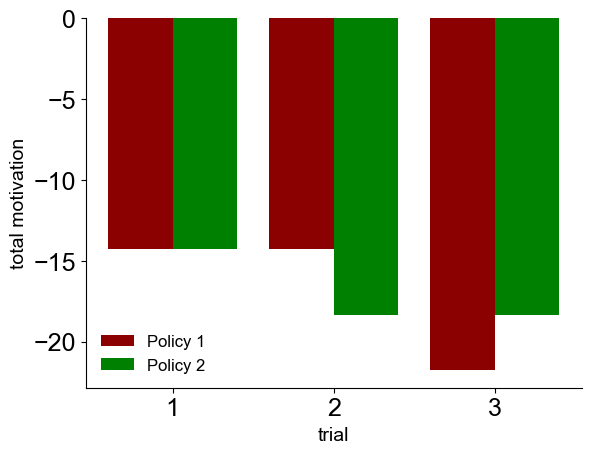

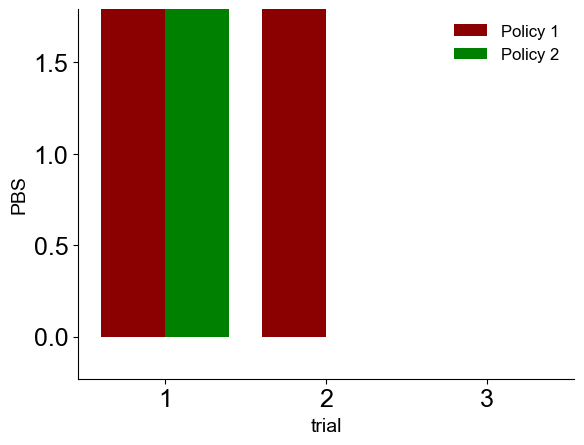

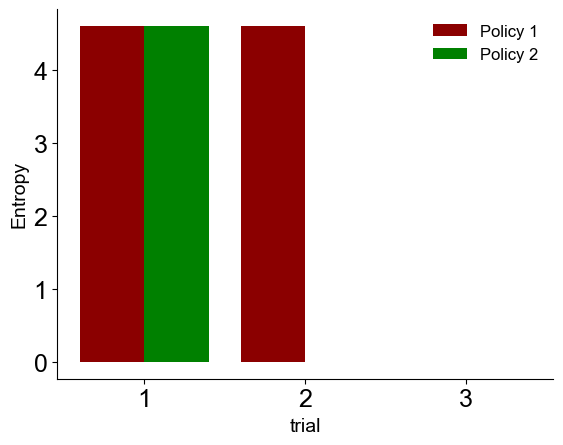

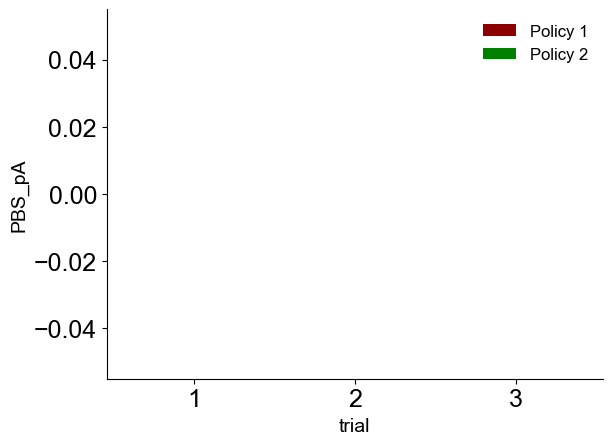

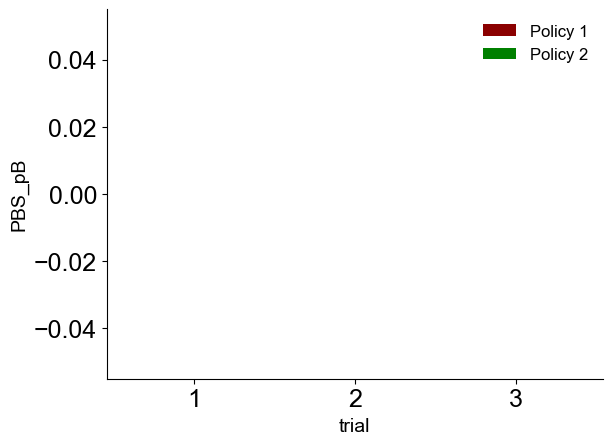

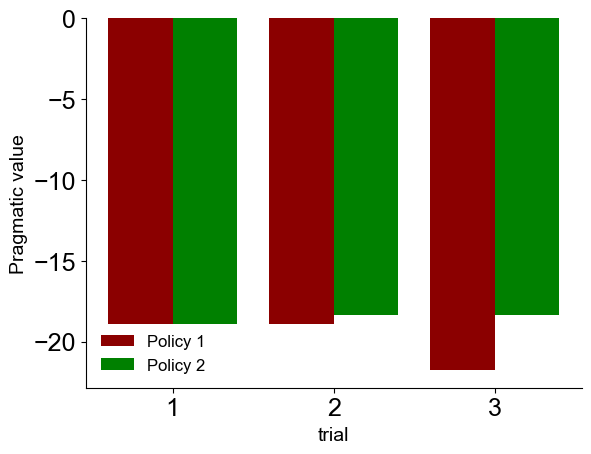

In [25]:
import matplotlib.pyplot as plt
import numpy as np

start=0#11
end=3#22

if __name__ == "__main__": 
  #labels=['1','2','3','4','5','6','7','8','9','10']  # set the dates as labels
  #x0 = np.arange(len(labels))  # create an array of values for the ticks that can perform arithmetic with width (w)
  labels=[str(i) for i in range(start+1, end+1)]#T+1,11, 22
  print(labels)
  x0 = np.arange(end-start)#T

# create the data groups with a dict comprehension and groupby
  # マージンを設定
  margin = 0.2  #0 <margin< 1
  total_width = 1 - margin
  colors = ['darkred', 'green', 'orange', 'purple']
  #colors = ['darkred', 'green', 'orange']
#EFEの可視化
  fig, ax = plt.subplots()
  # 棒グラフをプロット
  """ for i, h in enumerate(EFE):
    pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
    plt.bar(pos, h, width = total_width/len(EFE)) """
  num_policies = num_slot
  #EFE_temp=-np.array(Pragmaticvalue)-np.array(PBS)-np.array(MI_model_o)*MI_mo_weight
  EFE_temp=np.array(PBS)+np.array(pBS_pA)+np.array(Pragmaticvalue)
  print(EFE_temp.shape)
  EFE_temp=EFE_temp[:,start:end] 
  for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(EFE_temp) )/2
     ax.bar(pos, EFE_temp[i], color=colors[i],width=total_width/len(EFE_temp), label=f'Policy {i+1}')
  """ for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(pBS_pB) )/2
     ax.bar(pos, pBS_pB[i], color=colors[i],width=total_width/len(pBS_pB), label=f'Policy {i+1}') """
  # ラベルの設定
  plt.xticks(x0, labels)
  plt.xlabel("trial", fontname="Arial", fontsize=14)
  #plt.ylabel("EFE", fontname="Arial", fontsize=14)
  plt.ylabel("total motivation", fontname="Arial", fontsize=14)
  #plt.ylabel("pBS_pB", fontname="Arial", fontsize=14)
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  plt.legend(fontsize=12, frameon=False)
  #plt.ylim(top=120) #17.5#30
  plt.show


  #EFEの可視化
  fig, ax = plt.subplots()
  data_list_tmp=np.array(PBS)[:,start:end] 
  # 棒グラフをプロット
  """ for i, h in enumerate(EFE):
    pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
    plt.bar(pos, h, width = total_width/len(EFE)) """
  num_policies = num_slot
  """ for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
     ax.bar(pos, EFE[i], width=total_width/len(EFE), label=f'Policy {i+1}') """
  for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(data_list_tmp) )/2
     ax.bar(pos, data_list_tmp[i],color=colors[i], width=total_width/len(data_list_tmp), label=f'Policy {i+1}')
  # ラベルの設定
  plt.xticks(x0, labels)
  plt.xlabel("trial", fontname="Arial", fontsize=14)
  #plt.ylabel("EFE", fontname="Arial", fontsize=14)
  plt.ylabel("PBS", fontname="Arial", fontsize=14)
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  plt.legend(fontsize=12, frameon=False)
  plt.ylim(top=1.79) #17.5#30
  plt.show
# build the plots
#subs = df.subsidiary.unique()
  stacks = num_slot  # how many stacks in each group for a tick location
# set the width
  w = 0.15

#EFEの可視化
  fig, ax = plt.subplots()
  data_list_tmp=np.array(H_qo)[:,start:end] 
  # 棒グラフをプロット
  """ for i, h in enumerate(EFE):
    pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
    plt.bar(pos, h, width = total_width/len(EFE)) """
  num_policies = num_slot
  """ for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
     ax.bar(pos, EFE[i], width=total_width/len(EFE), label=f'Policy {i+1}') """
  for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(data_list_tmp) )/2
     ax.bar(pos, data_list_tmp[i],color=colors[i], width=total_width/len(data_list_tmp), label=f'Policy {i+1}')
  # ラベルの設定
  plt.xticks(x0, labels)
  plt.xlabel("trial", fontname="Arial", fontsize=14)
  #plt.ylabel("EFE", fontname="Arial", fontsize=14)
  plt.ylabel("Entropy", fontname="Arial", fontsize=14)
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  plt.legend(fontsize=12, frameon=False)
  #plt.ylim(top=120) #17.5#30
  plt.show


  #EFEの可視化
  fig, ax = plt.subplots()
  data_list_tmp=np.array(pBS_pA)[:,start:end] 
  # 棒グラフをプロット
  """ for i, h in enumerate(EFE):
    pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
    plt.bar(pos, h, width = total_width/len(EFE)) """
  num_policies = num_slot
  """ for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
     ax.bar(pos, EFE[i], width=total_width/len(EFE), label=f'Policy {i+1}') """
  for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(data_list_tmp) )/2
     ax.bar(pos, data_list_tmp[i],color=colors[i], width=total_width/len(data_list_tmp), label=f'Policy {i+1}')
  # ラベルの設定
  plt.xticks(x0, labels)
  plt.xlabel("trial", fontname="Arial", fontsize=14)
  #plt.ylabel("EFE", fontname="Arial", fontsize=14)
  plt.ylabel("PBS_pA", fontname="Arial", fontsize=14)
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  plt.legend(fontsize=12, frameon=False)
  #plt.ylim(top=120) #17.5#30
  plt.show
# build the plots

#pBS_pBの可視化
  fig, ax = plt.subplots()
  data_list_tmp=np.array(pBS_pB)[:,start:end] #11:22
  # 棒グラフをプロット
  """ for i, h in enumerate(EFE):
    pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
    plt.bar(pos, h, width = total_width/len(EFE)) """
  num_policies = num_slot
  """ for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
     ax.bar(pos, EFE[i], width=total_width/len(EFE), label=f'Policy {i+1}') """
  for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(data_list_tmp) )/2
     ax.bar(pos, data_list_tmp[i],color=colors[i], width=total_width/len(data_list_tmp), label=f'Policy {i+1}')
  # ラベルの設定
  plt.xticks(x0, labels)
  plt.xlabel("trial", fontname="Arial", fontsize=14)
  #plt.ylabel("EFE", fontname="Arial", fontsize=14)
  plt.ylabel("PBS_pB", fontname="Arial", fontsize=14)
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  plt.legend(fontsize=12, frameon=False)
  #plt.ylim(top=10) #17.5#30
  plt.show

  #Pvの可視化
  fig, ax = plt.subplots()
  data_list_tmp=np.array(Pragmaticvalue)[:,start:end] 
 
  num_policies = num_slot

  for i in range(num_policies):
     pos = x0 - total_width *( 1- (2*i+1)/len(data_list_tmp) )/2
     ax.bar(pos, data_list_tmp[i],color=colors[i], width=total_width/len(data_list_tmp), label=f'Policy {i+1}')
  # ラベルの設定
  plt.xticks(x0, labels)
  plt.xlabel("trial", fontname="Arial", fontsize=14)
  #plt.ylabel("EFE", fontname="Arial", fontsize=14)
  plt.ylabel("Pragmatic value", fontname="Arial", fontsize=14)
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  plt.legend(fontsize=12, frameon=False)
  #plt.ylim(top=120) #17.5#30
  plt.show

In [26]:
# import matplotlib.pyplot as plt
# import numpy as np

# if __name__ == "__main__": 
#   #labels=['1','2','3','4','5','6','7','8','9','10']  # set the dates as labels
#   #x0 = np.arange(len(labels))  # create an array of values for the ticks that can perform arithmetic with width (w)
#   labels=[str(i) for i in range(T-9, T + 2)]#T+1
#   print(labels)
#   x0 = np.arange(11)#T

# # create the data groups with a dict comprehension and groupby
#   # マージンを設定
#   margin = 0.2  #0 <margin< 1
#   total_width = 1 - margin
#   colors = ['darkred', 'green', 'orange', 'purple']
# #EFEの可視化
#   fig, ax = plt.subplots()
#   # 棒グラフをプロット
#   """ for i, h in enumerate(EFE):
#     pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
#     plt.bar(pos, h, width = total_width/len(EFE)) """
#   num_policies = num_slot
#   #EFE_temp=-np.array(Pragmaticvalue)-np.array(PBS)-np.array(MI_model_o)*MI_mo_weight
#   EFE_temp=np.array(PBS)+np.array(pBS_pA)+np.array(Pragmaticvalue)
#   print(EFE_temp.shape)
#   EFE_temp=EFE_temp[:,-11:] 
#   for i in range(num_policies):
#      pos = x0 - total_width *( 1- (2*i+1)/len(EFE_temp) )/2
#      ax.bar(pos, EFE_temp[i], color=colors[i],width=total_width/len(EFE_temp), label=f'Policy {i+1}')
#   """ for i in range(num_policies):
#      pos = x0 - total_width *( 1- (2*i+1)/len(pBS_pB) )/2
#      ax.bar(pos, pBS_pB[i], color=colors[i],width=total_width/len(pBS_pB), label=f'Policy {i+1}') """
#   # ラベルの設定
#   plt.xticks(x0, labels)
#   plt.xlabel("trial", fontname="Arial", fontsize=14)
#   #plt.ylabel("EFE", fontname="Arial", fontsize=14)
#   plt.ylabel("total motivation", fontname="Arial", fontsize=14)
#   #plt.ylabel("pBS_pB", fontname="Arial", fontsize=14)
#   ax.spines['top'].set_visible(False)
#   ax.spines['right'].set_visible(False)
#   plt.legend(fontsize=12, frameon=False)
#   #plt.ylim(top=120) #17.5#30
#   plt.show


#   #EFEの可視化
#   fig, ax = plt.subplots()
#   data_list_tmp=np.array(PBS)[:,-11:] 
#   # 棒グラフをプロット
#   """ for i, h in enumerate(EFE):
#     pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
#     plt.bar(pos, h, width = total_width/len(EFE)) """
#   num_policies = num_slot
#   """ for i in range(num_policies):
#      pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
#      ax.bar(pos, EFE[i], width=total_width/len(EFE), label=f'Policy {i+1}') """
#   for i in range(num_policies):
#      pos = x0 - total_width *( 1- (2*i+1)/len(data_list_tmp) )/2
#      ax.bar(pos, data_list_tmp[i],color=colors[i], width=total_width/len(data_list_tmp), label=f'Policy {i+1}')
#   # ラベルの設定
#   plt.xticks(x0, labels)
#   plt.xlabel("trial", fontname="Arial", fontsize=14)
#   #plt.ylabel("EFE", fontname="Arial", fontsize=14)
#   plt.ylabel("PBS", fontname="Arial", fontsize=14)
#   ax.spines['top'].set_visible(False)
#   ax.spines['right'].set_visible(False)
#   plt.legend(fontsize=12, frameon=False)
#   #plt.ylim(top=120) #17.5#30
#   plt.show
# # build the plots
# #subs = df.subsidiary.unique()
#   stacks = num_slot  # how many stacks in each group for a tick location
# # set the width
#   w = 0.15

# #EFEの可視化
#   fig, ax = plt.subplots()
#   data_list_tmp=np.array(H_qo)[:,-11:]
#   # 棒グラフをプロット
#   """ for i, h in enumerate(EFE):
#     pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
#     plt.bar(pos, h, width = total_width/len(EFE)) """
#   num_policies = num_slot
#   """ for i in range(num_policies):
#      pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
#      ax.bar(pos, EFE[i], width=total_width/len(EFE), label=f'Policy {i+1}') """
#   for i in range(num_policies):
#      pos = x0 - total_width *( 1- (2*i+1)/len(data_list_tmp) )/2
#      ax.bar(pos, data_list_tmp[i],color=colors[i], width=total_width/len(data_list_tmp), label=f'Policy {i+1}')
#   # ラベルの設定
#   plt.xticks(x0, labels)
#   plt.xlabel("trial", fontname="Arial", fontsize=14)
#   #plt.ylabel("EFE", fontname="Arial", fontsize=14)
#   plt.ylabel("Entropy", fontname="Arial", fontsize=14)
#   ax.spines['top'].set_visible(False)
#   ax.spines['right'].set_visible(False)
#   plt.legend(fontsize=12, frameon=False)
#   #plt.ylim(top=120) #17.5#30
#   plt.show


#   #EFEの可視化
#   fig, ax = plt.subplots()
#   data_list_tmp=np.array(pBS_pA)[:,-11:]
#   # 棒グラフをプロット
#   """ for i, h in enumerate(EFE):
#     pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
#     plt.bar(pos, h, width = total_width/len(EFE)) """
#   num_policies = num_slot
#   """ for i in range(num_policies):
#      pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
#      ax.bar(pos, EFE[i], width=total_width/len(EFE), label=f'Policy {i+1}') """
#   for i in range(num_policies):
#      pos = x0 - total_width *( 1- (2*i+1)/len(data_list_tmp) )/2
#      ax.bar(pos, data_list_tmp[i],color=colors[i], width=total_width/len(data_list_tmp), label=f'Policy {i+1}')
#   # ラベルの設定
#   plt.xticks(x0, labels)
#   plt.xlabel("trial", fontname="Arial", fontsize=14)
#   #plt.ylabel("EFE", fontname="Arial", fontsize=14)
#   plt.ylabel("PBS_pA", fontname="Arial", fontsize=14)
#   ax.spines['top'].set_visible(False)
#   ax.spines['right'].set_visible(False)
#   plt.legend(fontsize=12, frameon=False)
#   #plt.ylim(top=120) #17.5#30
#   plt.show
# # build the plots

# #pBS_pBの可視化
#   fig, ax = plt.subplots()
#   data_list_tmp=np.array(pBS_pB)[:,-11:]
#   # 棒グラフをプロット
#   """ for i, h in enumerate(EFE):
#     pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
#     plt.bar(pos, h, width = total_width/len(EFE)) """
#   num_policies = num_slot
#   """ for i in range(num_policies):
#      pos = x0 - total_width *( 1- (2*i+1)/len(EFE) )/2
#      ax.bar(pos, EFE[i], width=total_width/len(EFE), label=f'Policy {i+1}') """
#   for i in range(num_policies):
#      pos = x0 - total_width *( 1- (2*i+1)/len(data_list_tmp) )/2
#      ax.bar(pos, data_list_tmp[i],color=colors[i], width=total_width/len(data_list_tmp), label=f'Policy {i+1}')
#   # ラベルの設定
#   plt.xticks(x0, labels)
#   plt.xlabel("trial", fontname="Arial", fontsize=14)
#   #plt.ylabel("EFE", fontname="Arial", fontsize=14)
#   plt.ylabel("PBS_pB", fontname="Arial", fontsize=14)
#   ax.spines['top'].set_visible(False)
#   ax.spines['right'].set_visible(False)
#   plt.legend(fontsize=12, frameon=False)
#   #plt.ylim(top=120) #17.5#30
#   plt.show

#   #Pvの可視化
#   fig, ax = plt.subplots()
#   data_list_tmp=np.array(Pragmaticvalue)[:,-11:]
 
#   num_policies = num_slot

#   for i in range(num_policies):
#      pos = x0 - total_width *( 1- (2*i+1)/len(data_list_tmp) )/2
#      ax.bar(pos, data_list_tmp[i],color=colors[i], width=total_width/len(data_list_tmp), label=f'Policy {i+1}')
#   # ラベルの設定
#   plt.xticks(x0, labels)
#   plt.xlabel("trial", fontname="Arial", fontsize=14)
#   #plt.ylabel("EFE", fontname="Arial", fontsize=14)
#   plt.ylabel("Pragmatic value", fontname="Arial", fontsize=14)
#   ax.spines['top'].set_visible(False)
#   ax.spines['right'].set_visible(False)
#   plt.legend(fontsize=12, frameon=False)
#   #plt.ylim(top=120) #17.5#30
#   plt.show


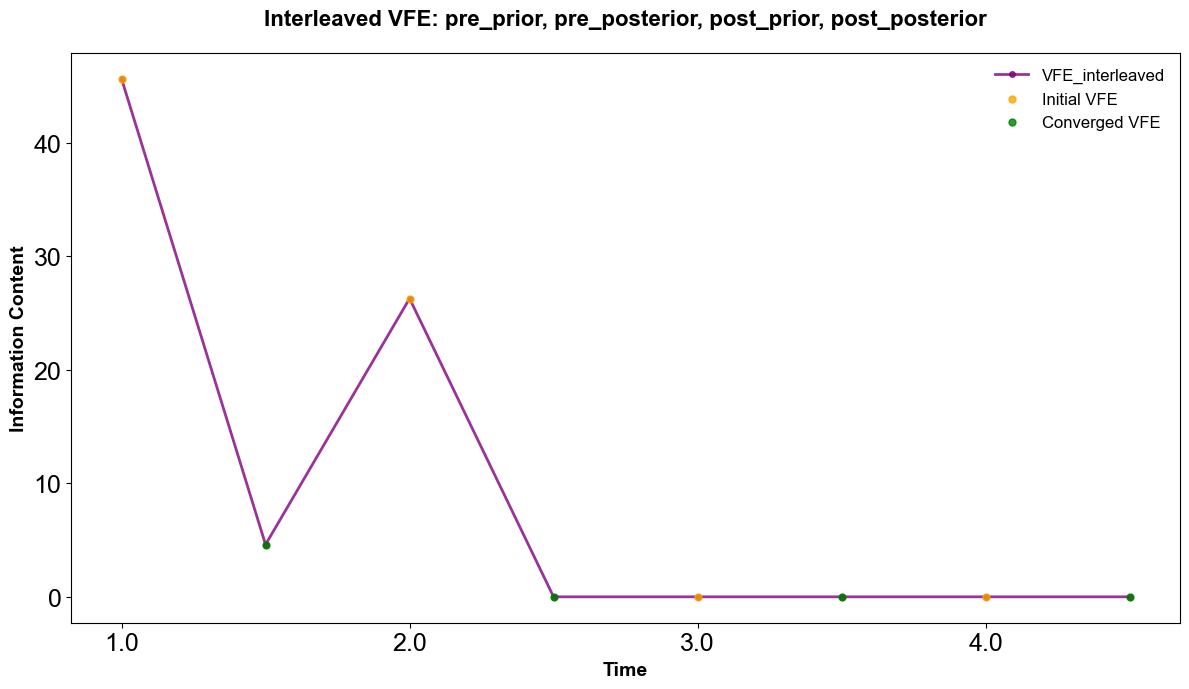

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# 2つのリストを順番に交互に結合する関数
def interleave_4lists(l1, l2):
    result = []
    max_len = max(len(l1), len(l2))
    for i in range(max_len):
        if i < len(l1):
            result.append(l1[i])
        if i < len(l2):
            result.append(l2[i])
        
    return result

# データをスカラー値に変換する関数（既存のものを流用）
def convert_to_scalars(data):
    scalars = []
    data_array = np.array(data)
    for i in range(len(data_array)):
        item = data_array[i]
        if hasattr(item, '__array__'):
            if item.ndim == 0:
                scalars.append(float(item))
            else:
                scalars.append(float(item[0]))
        else:
            scalars.append(float(item))
    return scalars

# 4つのVFEデータをスカラー値リストに変換
prior_scalars = convert_to_scalars(prior_VFE)
posterior_scalars = convert_to_scalars(posterior_VFE)


# 4つのリストを交互に結合
VFE_interleaved = interleave_4lists(prior_scalars, posterior_scalars)

# 時間軸
time_points_interleaved = range(1, len(VFE_interleaved) + 1)

# プロット
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(time_points_interleaved, VFE_interleaved, color='purple', marker='o', markersize=4, label='VFE_interleaved', linewidth=2, alpha=0.8)

# それぞれの系列ごとに色分けしてプロット
indices = [list(range(i, len(VFE_interleaved), 2)) for i in range(2)]
colors = [ 'orange', 'green']
labels = ['Initial VFE', 'Converged VFE']

for idx, color, label in zip(indices, colors, labels):
    values = [VFE_interleaved[i] for i in idx]
    time_points = [i+1 for i in idx]
    ax.scatter(time_points, values, color=color, marker='o', s=25, label=label, alpha=0.8, zorder=5)

ax.set_xticks(np.linspace(1, len(VFE_interleaved), min(len(VFE_interleaved), 11), dtype=int))
ax.set_xlabel('Time', fontsize=14, fontweight='bold')
ax.set_ylabel('Information Content', fontsize=14, fontweight='bold')
ax.set_title('Interleaved VFE: pre_prior, pre_posterior, post_prior, post_posterior', fontsize=16, fontweight='bold', pad=20)
ax.legend(frameon=False, fontsize=12, loc='upper right')
ax.autoscale_view()
# 4つおきのx軸目盛りの位置
xticks = list(range(0, len(VFE_interleaved), 2))
ax.set_xticks([i+1 for i in xticks])  # 1始まりに調整
# ラベルは1, 2, 3...と表示
ax.set_xticklabels([str(i*0.5+1) for i in xticks])
plt.tight_layout()
plt.show()

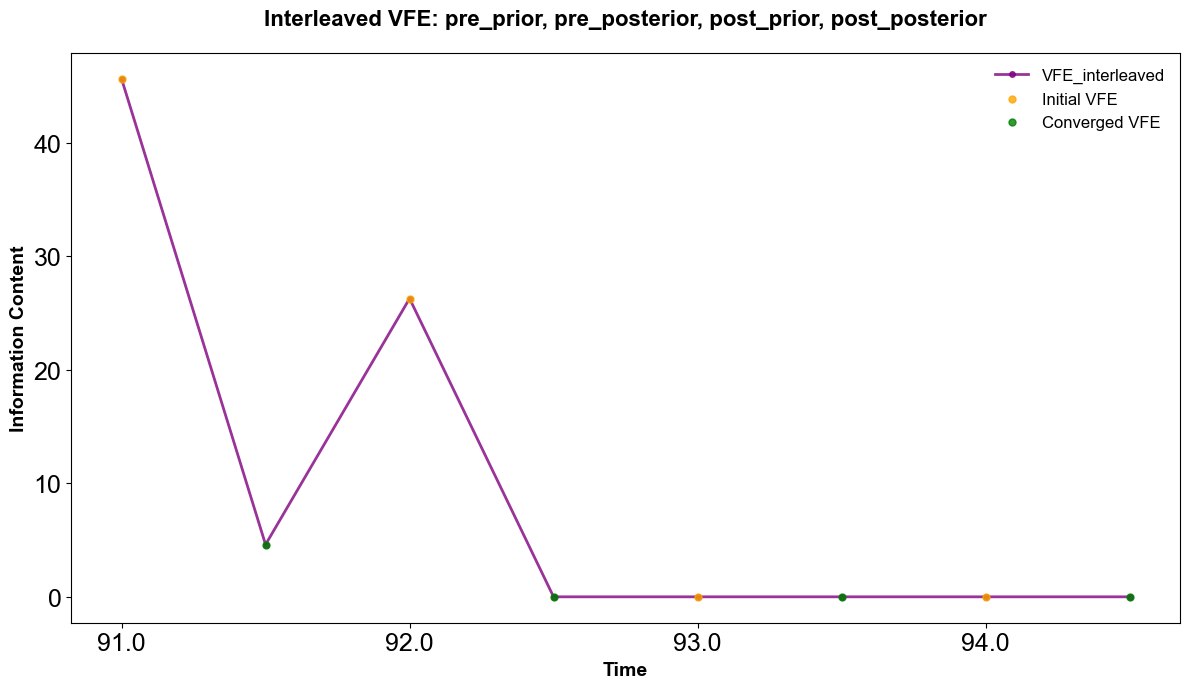

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# 2つのリストを順番に交互に結合する関数
def interleave_4lists(l1, l2):
    result = []
    max_len = max(len(l1), len(l2))
    for i in range(max_len):
        if i < len(l1):
            result.append(l1[i])
        if i < len(l2):
            result.append(l2[i])
        
    return result

# データをスカラー値に変換する関数（既存のものを流用）
def convert_to_scalars(data):
    scalars = []
    data_array = np.array(data)
    for i in range(len(data_array)):
        item = data_array[i]
        if hasattr(item, '__array__'):
            if item.ndim == 0:
                scalars.append(float(item))
            else:
                scalars.append(float(item[0]))
        else:
            scalars.append(float(item))
    return scalars

# 4つのVFEデータをスカラー値リストに変換
prior_scalars = convert_to_scalars(prior_VFE)
posterior_scalars = convert_to_scalars(posterior_VFE)


# 4つのリストを交互に結合
VFE_interleaved = interleave_4lists(prior_scalars, posterior_scalars)
VFE_interleaved=np.array(VFE_interleaved)[-20:]
VFE_interleaved=list(VFE_interleaved)

# 時間軸
time_points_interleaved = range(1, len(VFE_interleaved) + 1)

# プロット
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(time_points_interleaved, VFE_interleaved, color='purple', marker='o', markersize=4, label='VFE_interleaved', linewidth=2, alpha=0.8)

# それぞれの系列ごとに色分けしてプロット
indices = [list(range(i, len(VFE_interleaved), 2)) for i in range(2)]
colors = [ 'orange', 'green']
labels = ['Initial VFE', 'Converged VFE']

for idx, color, label in zip(indices, colors, labels):
    values = [VFE_interleaved[i] for i in idx]
    time_points = [i+1 for i in idx]
    ax.scatter(time_points, values, color=color, marker='o', s=25, label=label, alpha=0.8, zorder=5)

ax.set_xticks(np.linspace(1, len(VFE_interleaved), min(len(VFE_interleaved), 11), dtype=int))
ax.set_xlabel('Time', fontsize=14, fontweight='bold')
ax.set_ylabel('Information Content', fontsize=14, fontweight='bold')
ax.set_title('Interleaved VFE: pre_prior, pre_posterior, post_prior, post_posterior', fontsize=16, fontweight='bold', pad=20)
ax.legend(frameon=False, fontsize=12, loc='upper right')
ax.autoscale_view()
# 4つおきのx軸目盛りの位置
xticks = list(range(0, len(VFE_interleaved), 2))
ax.set_xticks([i+1 for i in xticks])  # 1始まりに調整
# ラベルは1, 2, 3...と表示
ax.set_xticklabels([str(i*0.5+91) for i in xticks])
plt.tight_layout()
plt.show()

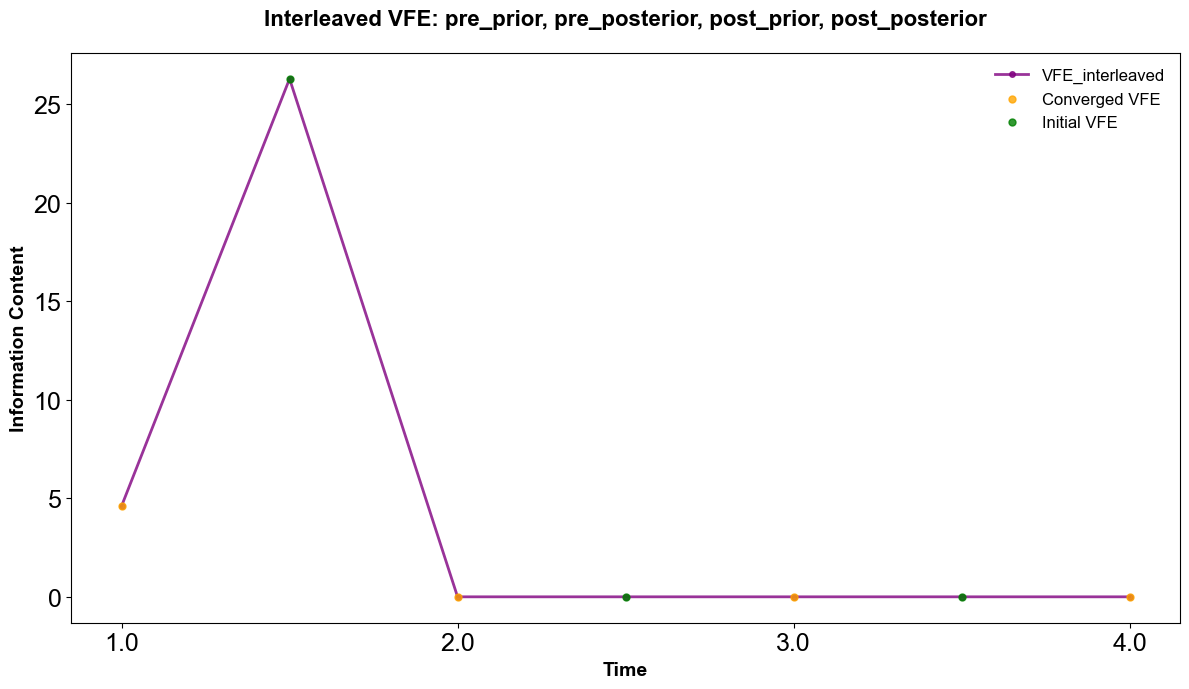

In [29]:
# 4つのVFEデータをスカラー値リストに変換
prior_scalars = convert_to_scalars(prior_VFE)
posterior_scalars = convert_to_scalars(posterior_VFE)

# 4つのリストを交互に結合
VFE_interleaved = interleave_4lists(prior_scalars, posterior_scalars)

# 一つ目の要素を省く
VFE_interleaved = VFE_interleaved[1:]

# 時間軸（一つ目の要素を省いたので、2から始まる）
time_points_interleaved = range(2, len(VFE_interleaved) + 2)

# プロット
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(time_points_interleaved, VFE_interleaved, color='purple', marker='o', markersize=4, label='VFE_interleaved', linewidth=2, alpha=0.8)

# それぞれの系列ごとに色分けしてプロット
indices = [list(range(i, len(VFE_interleaved), 2)) for i in range(2)]
colors = [ 'orange', 'green']
labels = [ 'Converged VFE','Initial VFE']

for idx, color, label in zip(indices, colors, labels):
    values = [VFE_interleaved[i] for i in idx]
    time_points = [i+2 for i in idx]  # 2から始まるように調整
    ax.scatter(time_points, values, color=color, marker='o', s=25, label=label, alpha=0.8, zorder=5)

ax.set_xticks(np.linspace(2, len(VFE_interleaved) + 1, min(len(VFE_interleaved), 11), dtype=int))
ax.set_xlabel('Time', fontsize=14, fontweight='bold')
ax.set_ylabel('Information Content', fontsize=14, fontweight='bold')
ax.set_title('Interleaved VFE: pre_prior, pre_posterior, post_prior, post_posterior', fontsize=16, fontweight='bold', pad=20)
ax.legend(frameon=False, fontsize=12, loc='upper right')
ax.autoscale_view()
# 4つおきのx軸目盛りの位置
xticks = list(range(0, len(VFE_interleaved), 2))
ax.set_xticks([i+2 for i in xticks])  # 2始まりに調整
# ラベルは1, 2, 3...と表示
ax.set_xticklabels([str(i*0.5+1) for i in xticks])
plt.tight_layout()
plt.show()

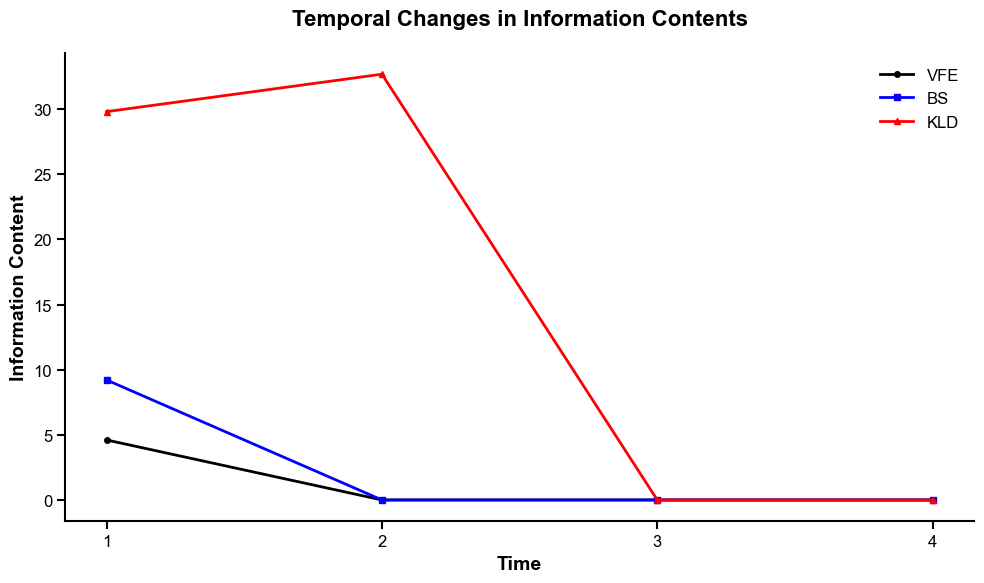

In [30]:
import matplotlib.pyplot as plt
import numpy as np

KLD_temp =list(map(lambda x: x , KLD)) #list(map(lambda x: x / 10, KLD))
#print(divided_list)  # [1.0, 2.0, 3.0, 4.0, 5.0]
# APAスタイルの設定
plt.style.use('default')
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['lines.linewidth'] = 2


# データの準備（例として、VFE、BS、KLDのリストが既に存在することを前提）
# 実際のデータに合わせて調整してください
#time_points = range(len(VFE))  # 時間軸
time_points = range(1, len(posterior_VFE) + 1)
# 図の作成
fig, ax = plt.subplots(figsize=(10, 6))
# 三つの折れ線グラフを描画
ax.plot(time_points, posterior_VFE, color='black', marker='o', markersize=4, label='VFE', linewidth=2)
ax.plot(time_points, BS, color='blue', marker='s', markersize=4, label='BS', linewidth=2)
ax.plot(time_points, KLD_temp, color='red', marker='^', markersize=4, label='KLD', linewidth=2)



# 軸の設定
ax.set_xticks(np.linspace(1, len(posterior_VFE), min(len(posterior_VFE), 11), dtype=int))
ax.set_xlabel('Time', fontsize=14, fontweight='bold')
ax.set_ylabel('Information Content', fontsize=14, fontweight='bold')
ax.set_title('Temporal Changes in Information Contents', fontsize=16, fontweight='bold', pad=20)
# グリッドの設定
#ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
# 凡例の設定
ax.legend(frameon=False, fontsize=12, loc='upper right')
# 軸の範囲を自動調整
ax.autoscale_view()
# レイアウトの調整
plt.tight_layout()
# グラフの表示
plt.show()

In [31]:
# import matplotlib.pyplot as plt
# import numpy as np

# KLD_temp =list(map(lambda x: x , KLD)) #list(map(lambda x: x / 10, KLD))
# #print(divided_list)  # [1.0, 2.0, 3.0, 4.0, 5.0]
# # APAスタイルの設定
# plt.style.use('default')
# plt.rcParams['font.family'] = 'Arial'
# plt.rcParams['font.size'] = 12
# plt.rcParams['axes.linewidth'] = 1.5
# plt.rcParams['axes.spines.top'] = False
# plt.rcParams['axes.spines.right'] = False
# plt.rcParams['xtick.major.width'] = 1.5
# plt.rcParams['ytick.major.width'] = 1.5
# plt.rcParams['xtick.major.size'] = 6
# plt.rcParams['ytick.major.size'] = 6
# plt.rcParams['lines.linewidth'] = 2


# # データの準備（例として、VFE、BS、KLDのリストが既に存在することを前提）
# # 実際のデータに合わせて調整してください
# #time_points = range(len(VFE))  # 時間軸
# time_points = range(1, 10 + 1)
# time_points = range(9991, 10001)  # 9991から10000まで
# # 図の作成
# fig, ax = plt.subplots(figsize=(10, 6))
# # 三つの折れ線グラフを描画
# ax.plot(time_points, np.array(posterior_VFE)[-10:], color='black', marker='o', markersize=4, label='VFE', linewidth=2)
# ax.plot(time_points, np.array(BS)[-10:], color='blue', marker='s', markersize=4, label='BS', linewidth=2)
# ax.plot(time_points, np.array(KLD_temp)[-10:], color='red', marker='^', markersize=4, label='KLD', linewidth=2)

# # 軸の設定
# ax.set_xticks(np.linspace(9991, 10000, 10, dtype=int))  # 9991から10000まで10個の目盛り
# ax.set_xlabel('Time', fontsize=14, fontweight='bold')
# ax.set_ylabel('Information Content', fontsize=14, fontweight='bold')
# ax.set_title('Temporal Changes in Information Contents', fontsize=16, fontweight='bold', pad=20)
# # 指数表記を無効にして整数で表示
# ax.ticklabel_format(style='plain', axis='x', useOffset=False)
# #ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
# # 凡例の設定
# ax.legend(frameon=False, fontsize=12, loc='upper right')
# # 軸の範囲を自動調整
# ax.autoscale_view()
# # レイアウトの調整
# plt.tight_layout()
# # グラフの表示
# plt.show()

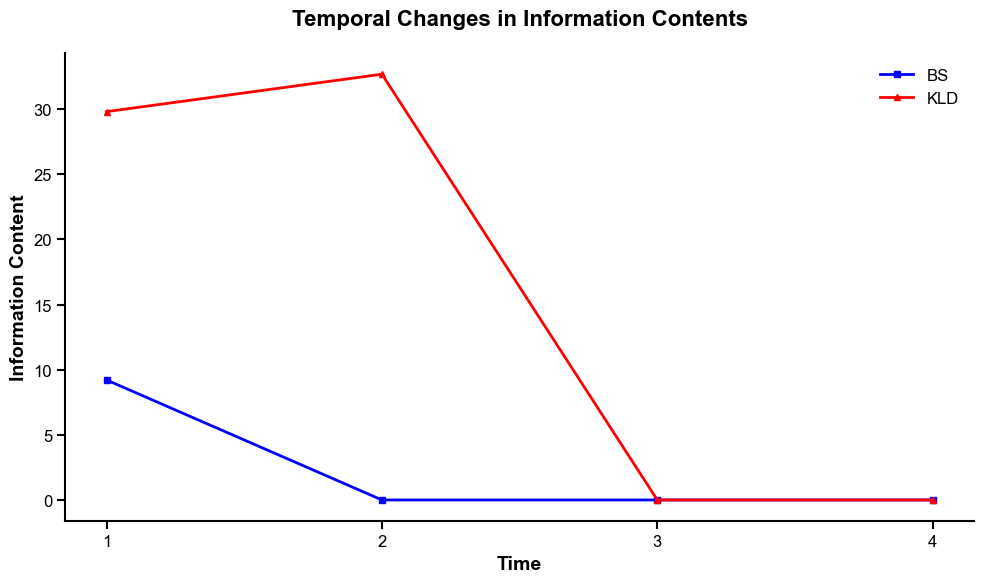

In [32]:
import matplotlib.pyplot as plt
import numpy as np

KLD_temp =list(map(lambda x: x , KLD)) #list(map(lambda x: x / 10, KLD))
#print(divided_list)  # [1.0, 2.0, 3.0, 4.0, 5.0]
# APAスタイルの設定
plt.style.use('default')
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['lines.linewidth'] = 2


# データの準備（例として、VFE、BS、KLDのリストが既に存在することを前提）
# 実際のデータに合わせて調整してください
#time_points = range(len(VFE))  # 時間軸
time_points = range(1, len(posterior_VFE) + 1)
# 図の作成
fig, ax = plt.subplots(figsize=(10, 6))
# 三つの折れ線グラフを描画
#ax.plot(time_points, posterior_VFE, color='black', marker='o', markersize=4, label='VFE', linewidth=2)
ax.plot(time_points, BS, color='blue', marker='s', markersize=4, label='BS', linewidth=2)
ax.plot(time_points, KLD_temp, color='red', marker='^', markersize=4, label='KLD', linewidth=2)

""" if len(posterior_VFE)>75:
    ax.axvline(x=25, color='gray', linestyle='--', alpha=0.7, linewidth=1)
    ax.axvline(x=50, color='gray', linestyle='--', alpha=0.7, linewidth=1)
    ax.axvline(x=75, color='gray', linestyle='--', alpha=0.7, linewidth=1) """

# 軸の設定
ax.set_xticks(np.linspace(1, len(posterior_VFE), min(len(posterior_VFE), 11), dtype=int))
ax.set_xlabel('Time', fontsize=14, fontweight='bold')
ax.set_ylabel('Information Content', fontsize=14, fontweight='bold')
ax.set_title('Temporal Changes in Information Contents', fontsize=16, fontweight='bold', pad=20)
# グリッドの設定
#ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
# 凡例の設定
ax.legend(frameon=False, fontsize=12, loc='upper right')
# 軸の範囲を自動調整
ax.autoscale_view()
# レイアウトの調整
plt.tight_layout()
# グラフの表示
plt.show()

 slot_counts is [1, 3]


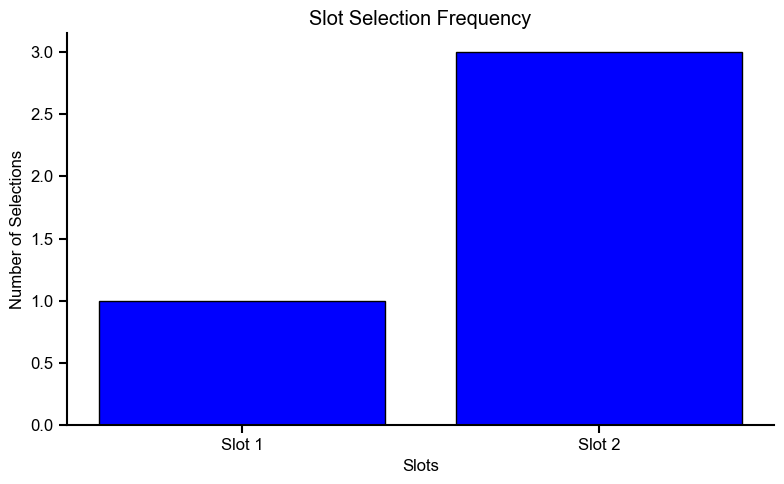

In [33]:
#選択されたスロットを集計
print(f' slot_counts is {slot_counts}')

%matplotlib inline

#棒グラフ化
import matplotlib.pyplot as plt
# スロット番号（1〜4）をラベルとして使用
slot_labels = [f'Slot {i+1}' for i in range(num_slot)]
#slot_labels = ['Slot 1', 'Slot 2', 'Slot 3', 'Slot 4']
# グラフを描画
plt.figure(figsize=(8, 5))
plt.bar(slot_labels, slot_counts, color='blue', edgecolor='black')
# タイトルとラベルの設定
plt.title('Slot Selection Frequency')
plt.xlabel('Slots')
plt.ylabel('Number of Selections')
# グリッド線と表示
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.tight_layout()
plt.show()


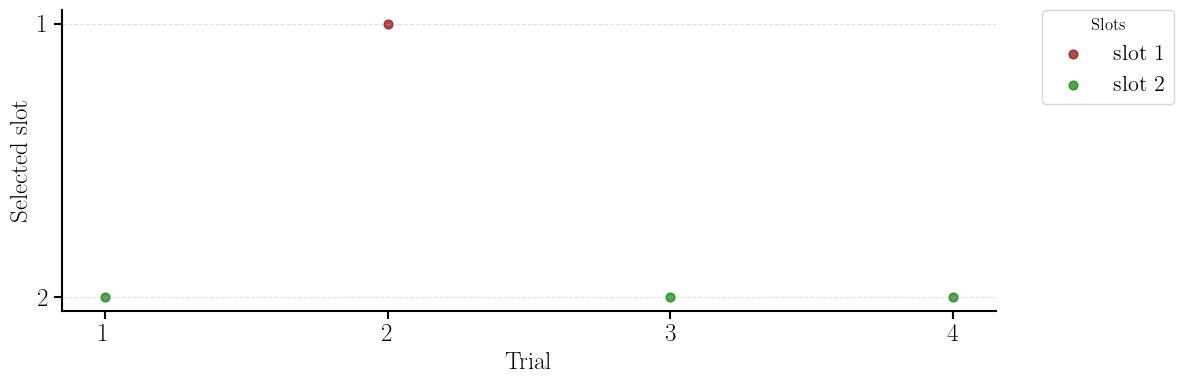

(np.float64(0.3333333333333333), np.int64(1))


In [34]:
##時系列で選択スロットを確認する

import matplotlib.pyplot as plt
import numpy as np

#selected_slot_array=
T2 = len(selected_slot_array)#[:-1]
x = np.arange(1, T2 + 1)
y = np.array(selected_slot_array)#[:-1]
#print(y)
font="Times new Roman"
# 色マップ定義（スロット番号 → 色）
colors = ['darkred', 'green', 'orange', 'purple']
slot_labels = [f"slot {i+1}" for i in range(num_slot)]

plt.rcParams.update({
    "text.usetex": True,          # ←これが重要
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
})

plt.rcParams.update({
    "xtick.labelsize": 18,
    "ytick.labelsize": 18
})

fig, ax = plt.subplots(figsize=(12, 4))



# スロットごとに分けてプロット
for slot in range(1,num_slot+1):
    slot_trials = x[y == slot]
    ax.scatter(slot_trials, [slot]*len(slot_trials), color=colors[slot-1], label=slot_labels[slot-1], s=40, alpha=0.7)

# 軸・表示設定
ax.set_xlabel("Trial", fontname=font, fontsize=18)
ax.set_ylabel("Selected slot", fontname=font, fontsize=18)
#ax.set_title("Slot selection over trials", fontname=font, fontsize=18)
#ax.set_yticks([i for i in range(num_slot)])#[1, 2, 3, 4]
ax.set_yticks([i for i in range(1, num_slot+1)])  # 1からnum_slotまでに変更
ax.set_xticks(np.linspace(1, T2, min(T2, 11), dtype=int))  
ax.legend(title="Slots", fontsize=18)
plt.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(title="Slots", fontsize=16, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax.invert_yaxis()  # y軸を反転
plt.tight_layout()



filename = f"Slot_slection_sa2{sa2}_sb{sb1}.tif"
plt.savefig(
    filename,
    format="tiff",
    dpi=600,                 # APA・多くのジャーナルで推奨
    bbox_inches="tight"
)

plt.show()

import numpy as np

def consecutive_ratio(selected_slot_array):
    # numpy配列に変換
    arr = np.array(selected_slot_array)
    
    # 隣同士を比較
    consecutive = arr[:-1] == arr[1:]
    
    # 一致している割合を計算
    ratio = consecutive.sum() / len(consecutive)
    return ratio,consecutive.sum()
print(consecutive_ratio(y)) 

In [35]:
Q_pi=np.array(Q_pi)
Q_pi=Q_pi[:,0,:]
Q_pi=Q_pi.T

In [36]:
print(Q_pi)

[[0.5        0.98294413 0.03155844 0.03155844]
 [0.5        0.01705596 0.96844155 0.96844155]]


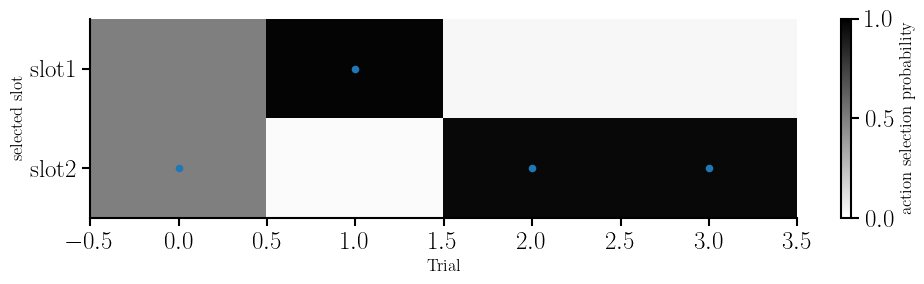

In [37]:
import numpy as np
import matplotlib.pyplot as plt


# ダミーデータ（実際はユーザーの Q_pi, y を使用）
# Q_pi = np.random.rand(2, 30)
# y = np.random.randint(0, 2, size=30)

y = np.array(selected_slot_array)
nT = Q_pi.shape[1]
#fig, ax = plt.subplots(figsize=(10, 3))

delta_y = -1#0.05  # 上寄りに見える分だけ下げる（必要に応じて -0.03 ～ -0.07 で微調整）

# im = ax.imshow(
#     Q_pi, cmap='gray_r', interpolation='nearest', aspect='auto',
#     extent=[-0.5, nT-0.5, -0.5, 1.5], origin='lower',
#     vmin=0.0, vmax=1.0
# )

# 1始まりなら 0始まりに補正
if y.min() >= 1 and y.max() <= num_slot:
    y = y - 1

fig, ax = plt.subplots(figsize=(10, max(3, 0.9 + 0.6*num_slot)))

# 画像：x は -0.5..nT-0.5、y は -0.5..num_slots-0.5、上が slot1 になるように origin='upper'


im = ax.imshow(
    Q_pi, cmap='gray_r', interpolation='nearest', aspect='auto',
    extent=[-0.5, nT - 0.5, -0.5, num_slot - 0.5],
    origin='lower', vmin=0.0, vmax=1.0
)

# 点（セル中心にそのまま打つ。オフセット不要）
x = np.arange(nT)
ax.scatter(x, y.astype(float), s=30, linewidths=0, zorder=3)

# 軸：y を反転して 0 を上（= slot1）にする
ax.set_xlim(-0.5, nT - 0.5)
ax.set_ylim(num_slot - 0.5, -0.5)       # ← ここで上下反転（invert_yaxis()でも可）

ax.set_xlabel("Trial")
ax.set_ylabel("selected slot")
ax.set_yticks(range(num_slot))
ax.set_yticklabels([f"slot{i+1}" for i in range(num_slot)])

fig.colorbar(im, ax=ax, label="action selection probability")
plt.tight_layout()
plt.show()


# x = np.arange(nT)
# ax.scatter(x, y.astype(float) + delta_y, color='blue', s=30, linewidths=0, zorder=3)

# ax.set_xlim(-0.5, nT-0.5)
# ax.set_ylim(-0.5, 1.5)
# ax.set_xlabel("Trial")
# ax.set_ylabel("selected slot")
# ax.set_yticks([0, 1])
# ax.set_yticklabels(["slot1", "slot2"])  # ここでラベルを変更
# ax.invert_yaxis()  # ★これで上下逆転

# fig.colorbar(im, ax=ax, label="action selection probability")
# plt.tight_layout()
# plt.show()


In [38]:
pBS_pB=np.array(pBS_pB)
# Q_pi=Q_pi[:,0,:]
# Q_pi=Q_pi.T

In [39]:
import numpy as np
import matplotlib.pyplot as plt


# ダミーデータ（実際はユーザーの Q_pi, y を使用）
# Q_pi = np.random.rand(2, 30)
# y = np.random.randint(0, 2, size=30)

y = np.array(selected_slot_array)
nT = pBS_pB.shape[1]
#fig, ax = plt.subplots(figsize=(10, 3))

delta_y = -1#0.05  # 上寄りに見える分だけ下げる（必要に応じて -0.03 ～ -0.07 で微調整）
fig, ax = plt.subplots(figsize=(10, max(3, 0.9 + 0.6*num_slot)))

# 画像：x は -0.5..nT-0.5、y は -0.5..num_slots-0.5、上が slot1 になるように origin='upper'

# 1始まりなら 0始まりに補正
if y.min() >= 1 and y.max() <= num_slot:
    y = y - 1

im = ax.imshow(
    pBS_pB, cmap='Blues', interpolation='nearest', aspect='auto',
    extent=[-0.5, nT - 0.5, -0.5, num_slot - 0.5],
    origin='lower', vmin=0.0, vmax=1.0
)

# 点（セル中心にそのまま打つ。オフセット不要）
x = np.arange(nT)
ax.scatter(x, y.astype(float),color='black', s=30, linewidths=0, zorder=3)

# 軸：y を反転して 0 を上（= slot1）にする
ax.set_xlim(-0.5, nT - 0.5)
ax.set_ylim(num_slot - 0.5, -0.5)       # ← ここで上下反転（invert_yaxis()でも可）

ax.set_xlabel("Trial")
ax.set_ylabel("selected slot")
ax.set_yticks(range(num_slot))
ax.set_yticklabels([f"slot{i+1}" for i in range(num_slot)])

fig.colorbar(im, ax=ax, label="I(θ;o)")
plt.tight_layout()
plt.show()


# im = ax.imshow(
#     pBS_pB, cmap='Blues', interpolation='nearest', aspect='auto',
#     extent=[-0.5, nT-0.5, -0.5, 1.5], origin='lower',
#     vmin=0.0, vmax=1.0
# )

# x = np.arange(nT)
# ax.scatter(x, y.astype(float) + delta_y, color='black', s=30, linewidths=0, zorder=3)

# ax.set_xlim(-0.5, nT-0.5)
# ax.set_ylim(-0.5, 1.5)
# ax.set_xlabel("Trial")
# ax.set_ylabel("selected slot")
# ax.set_yticks([0, 1])
# ax.set_yticklabels(["slot1", "slot2"])  # ここでラベルを変更
# ax.invert_yaxis()  # ★これで上下逆転
# #ax.set_title("Q_pi visualization with y overlay")
# #ax.legend(loc="upper right")

# fig.colorbar(im, ax=ax, label="I(θ;o)")
# plt.tight_layout()
# plt.show()

RuntimeError: latex was not able to process the following string:
b'I(\\u03b8;o)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpdd5sslb0 8320f7828aff5250fd8d809a9dfbc17e9106ecd4b43702443e89013eede77a75.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./8320f7828aff5250fd8d809a9dfbc17e9106ecd4b43702443e89013eede77a75.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/

Error in callback <function _draw_all_if_interactive at 0x78c95d6dc4a0> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: latex was not able to process the following string:
b'I(\\u03b8;o)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpmbqpd1yw 8320f7828aff5250fd8d809a9dfbc17e9106ecd4b43702443e89013eede77a75.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./8320f7828aff5250fd8d809a9dfbc17e9106ecd4b43702443e89013eede77a75.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/

RuntimeError: latex was not able to process the following string:
b'I(\\u03b8;o)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp1u6bb__d 8320f7828aff5250fd8d809a9dfbc17e9106ecd4b43702443e89013eede77a75.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./8320f7828aff5250fd8d809a9dfbc17e9106ecd4b43702443e89013eede77a75.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/

<Figure size 1000x300 with 2 Axes>

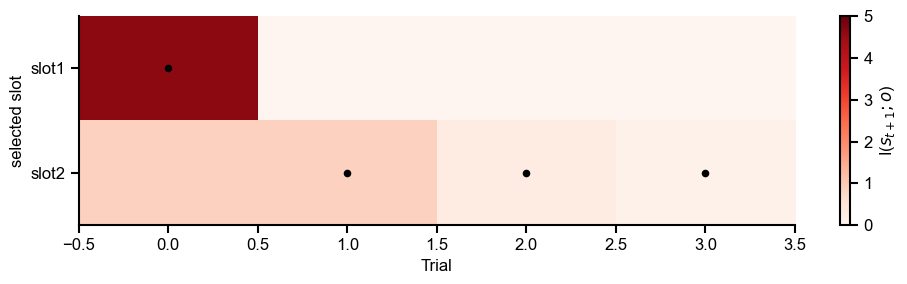

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

PBS=np.array(PBS)
# ダミーデータ（実際はユーザーの Q_pi, y を使用）
# Q_pi = np.random.rand(2, 30)
# y = np.random.randint(0, 2, size=30)

y = np.array(selected_slot_array)
nT = PBS.shape[1]
fig, ax = plt.subplots(figsize=(10, 3))

delta_y = -1#0.05  # 上寄りに見える分だけ下げる（必要に応じて -0.03 ～ -0.07 で微調整）
# 1始まりなら 0始まりに補正
if y.min() >= 1 and y.max() <= num_slot:
    y = y - 1

im = ax.imshow(
    PBS, cmap='Reds', interpolation='nearest', aspect='auto',
    extent=[-0.5, nT - 0.5, -0.5, num_slot - 0.5],
    origin='lower', vmin=0.0, vmax=5
)

# 点（セル中心にそのまま打つ。オフセット不要）
x = np.arange(nT)
ax.scatter(x, y.astype(float),color='black', s=30, linewidths=0, zorder=3)

# 軸：y を反転して 0 を上（= slot1）にする
ax.set_xlim(-0.5, nT - 0.5)
ax.set_ylim(num_slot - 0.5, -0.5)       

ax.set_xlabel("Trial")
ax.set_ylabel("selected slot")
ax.set_yticks(range(num_slot))
ax.set_yticklabels([f"slot{i+1}" for i in range(num_slot)])

fig.colorbar(im, ax=ax, label=r'I($s_{t+1};o$)')
plt.tight_layout()
plt.show()

# im = ax.imshow(
#     PBS, cmap='Reds', interpolation='nearest', aspect='auto',
#     extent=[-0.5, nT-0.5, -0.5, 1.5], origin='lower',
#     vmin=0.0, vmax=5
# )

# x = np.arange(nT)
# ax.scatter(x, y.astype(float) + delta_y, color='black', s=30, linewidths=0, zorder=3)

# ax.set_xlim(-0.5, nT-0.5)
# ax.set_ylim(-0.5, 1.5)
# ax.set_xlabel("Trial")
# ax.set_ylabel("selected slot")
# ax.set_yticks([0, 1])
# ax.set_yticklabels(["slot1", "slot2"])  # ここでラベルを変更
# ax.invert_yaxis()  # ★これで上下逆転
# #ax.set_title("Q_pi visualization with y overlay")
# #ax.legend(loc="upper right")

# fig.colorbar(im, ax=ax, label="I(s;o)")
# plt.tight_layout()
# plt.show()

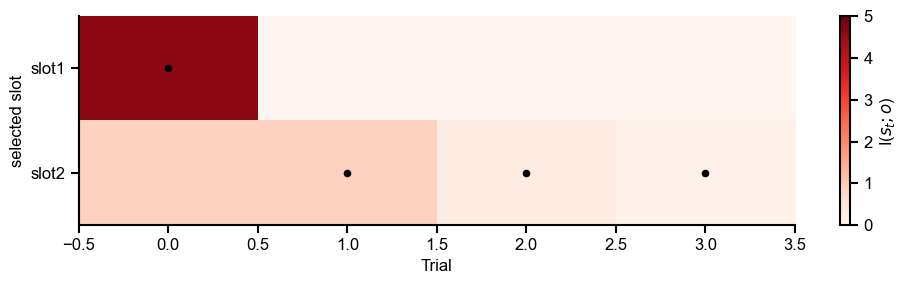

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

PBS_st=np.array(PBS_st)
# ダミーデータ（実際はユーザーの Q_pi, y を使用）
# Q_pi = np.random.rand(2, 30)
# y = np.random.randint(0, 2, size=30)

y = np.array(selected_slot_array)
nT = PBS.shape[1]
fig, ax = plt.subplots(figsize=(10, 3))

delta_y = -1#0.05  # 上寄りに見える分だけ下げる（必要に応じて -0.03 ～ -0.07 で微調整）
# 1始まりなら 0始まりに補正
if y.min() >= 1 and y.max() <= num_slot:
    y = y - 1

im = ax.imshow(
    PBS_st, cmap='Reds', interpolation='nearest', aspect='auto',
    extent=[-0.5, nT - 0.5, -0.5, num_slot - 0.5],
    origin='lower', vmin=0.0, vmax=5
)

# 点（セル中心にそのまま打つ。オフセット不要）
x = np.arange(nT)
ax.scatter(x, y.astype(float),color='black', s=30, linewidths=0, zorder=3)

# 軸：y を反転して 0 を上（= slot1）にする
ax.set_xlim(-0.5, nT - 0.5)
ax.set_ylim(num_slot - 0.5, -0.5)       

ax.set_xlabel("Trial")
ax.set_ylabel("selected slot")
ax.set_yticks(range(num_slot))
ax.set_yticklabels([f"slot{i+1}" for i in range(num_slot)])

fig.colorbar(im, ax=ax, label=r'I($s_{t};o$)')
plt.tight_layout()
plt.show()

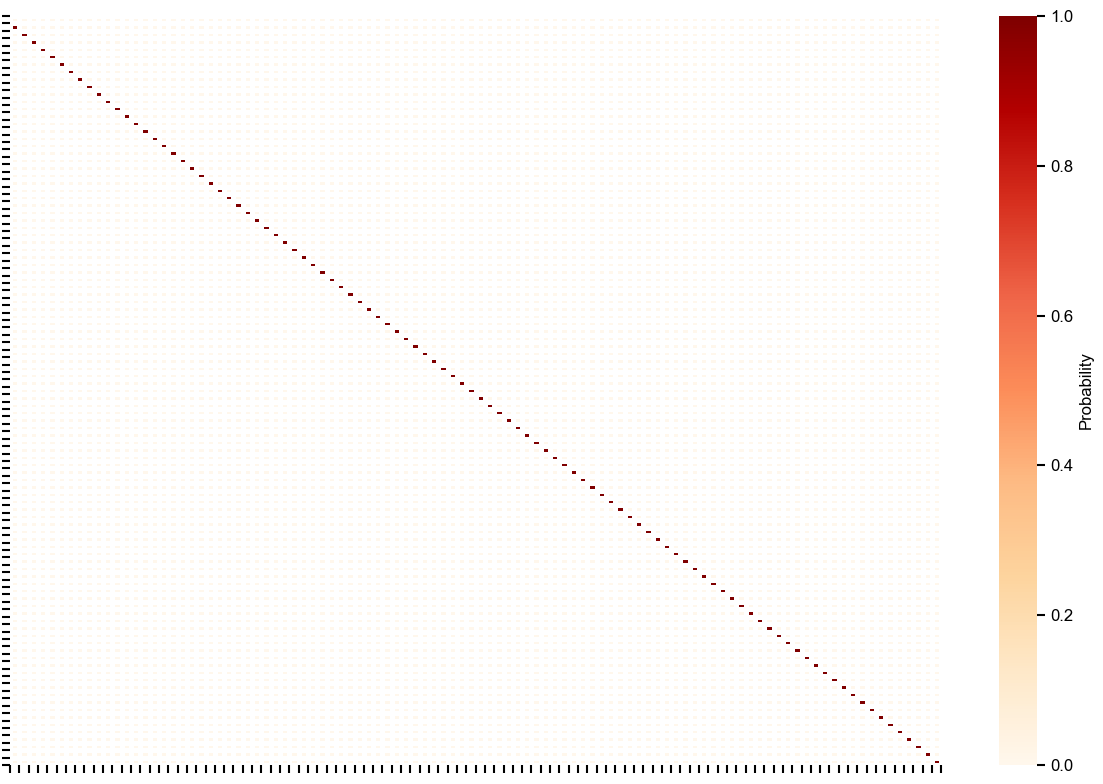

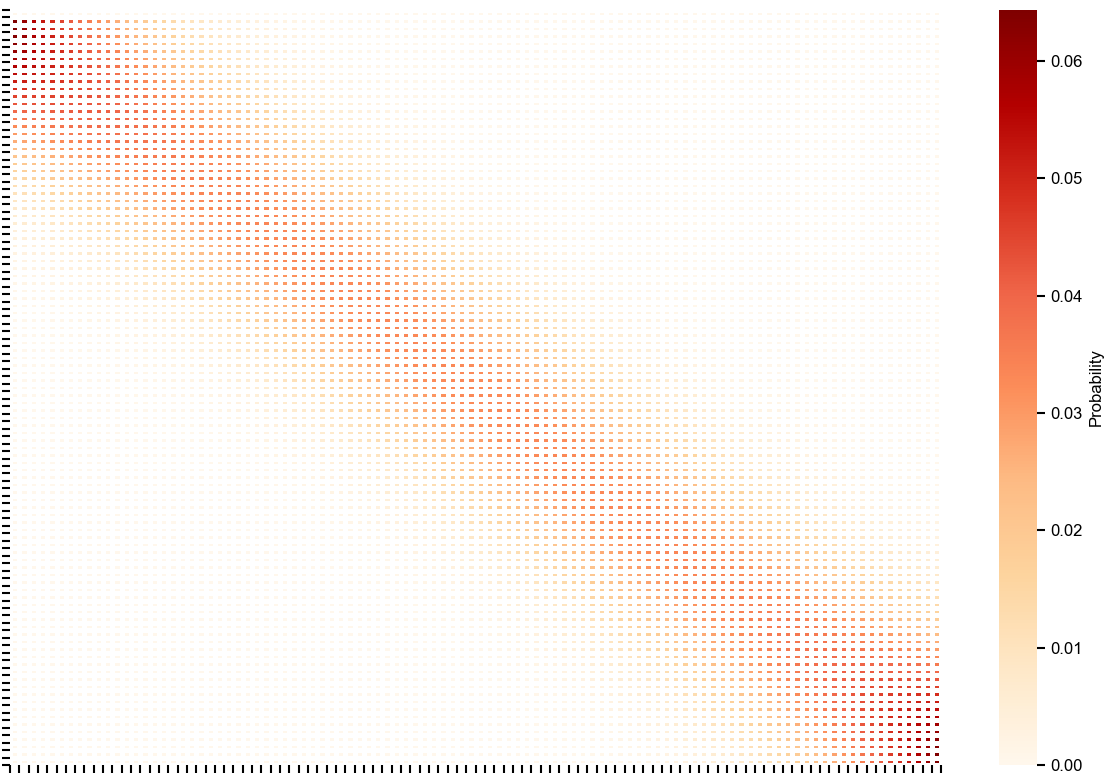

' plot_likelihood_figsize(agents.A[1][0][:,:,1] )\nplot_likelihood_figsize(agents.A[2][0][:,:,2] )\nplot_likelihood_figsize(agents.A[3][0][:,:,3] ) '

In [ ]:
for i in range (num_slot):
    plot_likelihood_figsize(agents.A[i][0][:,:,i] )

""" plot_likelihood_figsize(agents.A[1][0][:,:,1] )
plot_likelihood_figsize(agents.A[2][0][:,:,2] )
plot_likelihood_figsize(agents.A[3][0][:,:,3] ) """

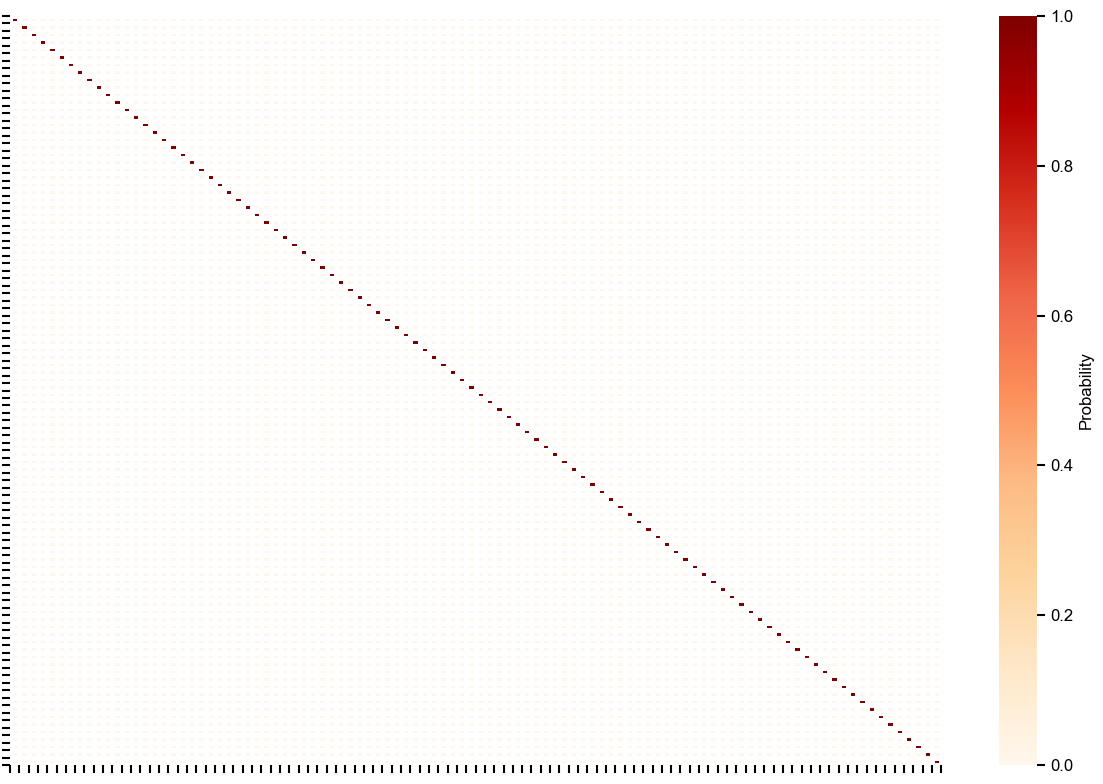

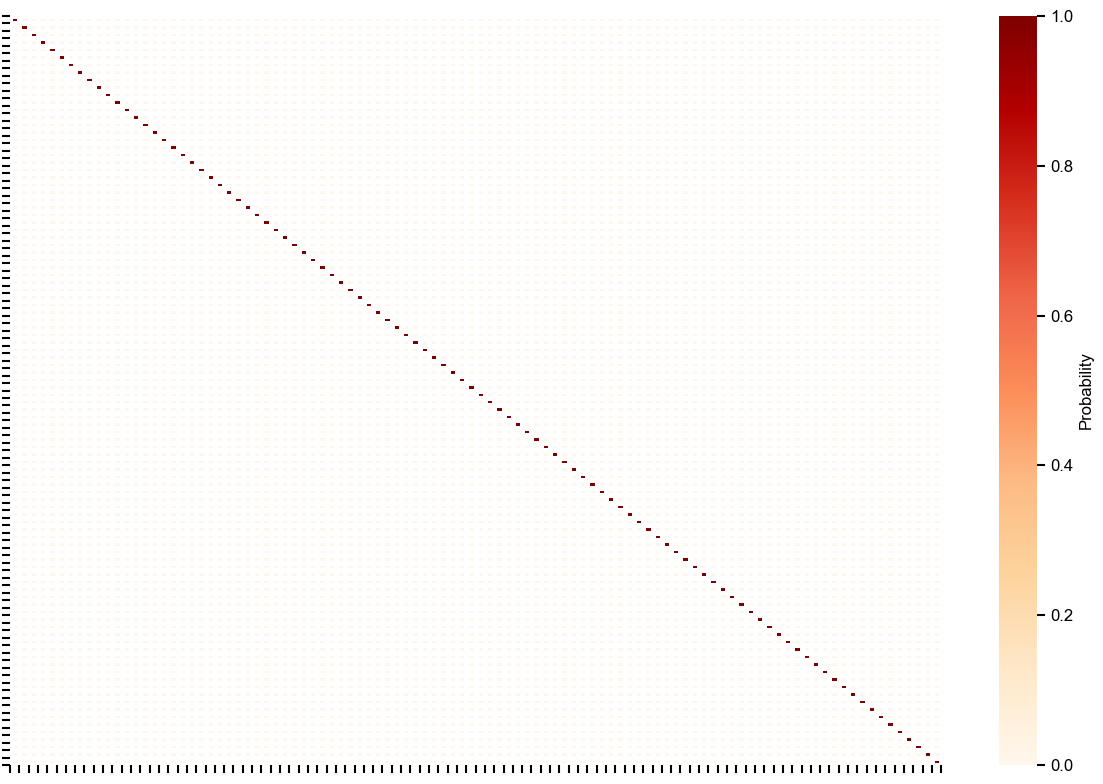

In [ ]:
for i in range (num_slot):
    plot_likelihood_figsize(agents.B[i][0][:,:,i] )
# plot_likelihood_figsize(agents.B[0][0][:,:,0] )
# plot_likelihood_figsize(agents.B[1][0][:,:,1] )
# plot_likelihood_figsize(agents.B[2][0][:,:,2] )
# plot_likelihood_figsize(agents.B[3][0][:,:,3] )

In [ ]:
print(obs_record)

[[Array([25], dtype=int32), Array([0], dtype=int32), Array([0], dtype=int32)], [Array([0], dtype=int32), Array([60], dtype=int32), Array([1], dtype=int32)], [Array([0], dtype=int32), Array([60], dtype=int32), Array([1], dtype=int32)], [Array([0], dtype=int32), Array([60], dtype=int32), Array([1], dtype=int32)], [Array([0], dtype=int32), Array([60], dtype=int32), Array([1], dtype=int32)]]


In [ ]:
""" # obs_recordを5つの1×100の配列に分割してプロット
import numpy as np
import matplotlib.pyplot as plt

# obs_recordから各スロットの観測値を抽出
slot1_obs = []
slot2_obs = []
slot3_obs = []
slot4_obs = []
action_obs = []

for obs in obs_record:
    # JAX Arrayから値を抽出（.item()または[0]を使用）
    slot1_obs.append(obs[0].item())  # .item()を使用してスカラー値を取得
    slot2_obs.append(obs[1].item())
    slot3_obs.append(obs[2].item())
    slot4_obs.append(obs[3].item())
    action_obs.append(obs[4].item())

# 時間軸（1から100まで）
time_steps = range(1, len(obs_record) + 1)

# 5つのサブプロットを作成
fig, axes = plt.subplots(4, 1, figsize=(12, 15))
fig.suptitle('observation', fontsize=16, fontweight='bold')

# スロット1の観測値
axes[0].scatter(time_steps, slot1_obs, color='red', s=30, alpha=0.7)
axes[0].set_title('observation of slot1')
axes[0].set_ylabel('payout value')
axes[0].set_xlim(0, len(obs_record) + 1)
axes[0].grid(True, alpha=0.3)

# スロット2の観測値
axes[1].scatter(time_steps, slot2_obs, color='blue', s=30, alpha=0.7)
axes[1].set_title('observation of slot2')
axes[1].set_ylabel('payout value')
axes[1].set_xlim(0, len(obs_record) + 1)
axes[1].grid(True, alpha=0.3)

# スロット3の観測値
axes[2].scatter(time_steps, slot3_obs, color='green', s=30, alpha=0.7)
axes[2].set_title('observation of slot3')
axes[2].set_ylabel('payout value')
axes[2].set_xlim(0, len(obs_record) + 1)
axes[2].grid(True, alpha=0.3)

# スロット4の観測値
axes[3].scatter(time_steps, slot4_obs, color='orange', s=30, alpha=0.7)
axes[3].set_title('observation of slot4')
axes[3].set_ylabel('payout value')
axes[3].set_xlim(0, len(obs_record) + 1)
axes[3].grid(True, alpha=0.3)


plt.tight_layout()
plt.show() """

" # obs_recordを5つの1×100の配列に分割してプロット\nimport numpy as np\nimport matplotlib.pyplot as plt\n\n# obs_recordから各スロットの観測値を抽出\nslot1_obs = []\nslot2_obs = []\nslot3_obs = []\nslot4_obs = []\naction_obs = []\n\nfor obs in obs_record:\n    # JAX Arrayから値を抽出（.item()または[0]を使用）\n    slot1_obs.append(obs[0].item())  # .item()を使用してスカラー値を取得\n    slot2_obs.append(obs[1].item())\n    slot3_obs.append(obs[2].item())\n    slot4_obs.append(obs[3].item())\n    action_obs.append(obs[4].item())\n\n# 時間軸（1から100まで）\ntime_steps = range(1, len(obs_record) + 1)\n\n# 5つのサブプロットを作成\nfig, axes = plt.subplots(4, 1, figsize=(12, 15))\nfig.suptitle('observation', fontsize=16, fontweight='bold')\n\n# スロット1の観測値\naxes[0].scatter(time_steps, slot1_obs, color='red', s=30, alpha=0.7)\naxes[0].set_title('observation of slot1')\naxes[0].set_ylabel('payout value')\naxes[0].set_xlim(0, len(obs_record) + 1)\naxes[0].grid(True, alpha=0.3)\n\n# スロット2の観測値\naxes[1].scatter(time_steps, slot2_obs, color='blue', s=30, alpha=0.7)\naxes[1]